<a href="https://colab.research.google.com/github/Avishi-Negi/Avishi-Negi/blob/main/predicting_finan_trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pandas-ta statsmodels arch pmdarima xgboost shap yfinance

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_ta as ta
import yfinance as yf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

from google.colab import drive
import os

if not os.path.isdir('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted — skipping.")


Mounted at /content/drive


In [ ]:
DATA_DIR = r"/content/drive/MyDrive/dissertation_data"
STOCKS_DIR = os.path.join(DATA_DIR, "stocks")
ETFS_DIR = os.path.join(DATA_DIR, "etfs")
OUT_DIR = os.path.join(DATA_DIR, "processed")
os.makedirs(OUT_DIR, exist_ok=True)

TICKERS = ["AAPL", "MSFT", "AMZN", "GOOGL", "JPM", "XOM", "JNJ", "PG", "KO", "DIS"]
STUDY_START, STUDY_END = "2000-01-01", pd.Timestamp.today().strftime("%Y-%m-%d")

print("Stocks dir exists:", os.path.isdir(STOCKS_DIR))
print("ETFs dir exists:", os.path.isdir(ETFS_DIR))

Stocks dir exists: True
ETFs dir exists: True


In [ ]:
def normalise_columns(df):
    """Flatten any MultiIndex columns (yfinance sometimes returns these) and standardise names."""
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    df.columns = [str(c).strip() for c in df.columns]
    return df


def load_full_series(ticker, label, start=STUDY_START, end=STUDY_END):
    """Load the full 2000-present series directly from yfinance, avoiding any
    adjustment-basis mismatch from stitching two differently-dated sources."""
    try:
        df = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
        if df.empty:
            print(f"[{label}] {ticker}: no data returned.")
            return None
        df = df.reset_index()
        df = normalise_columns(df)
        keep_cols = ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]
        df = df[[c for c in keep_cols if c in df.columns]]
        df = df.sort_values("Date").drop_duplicates(subset="Date").reset_index(drop=True)
        print(f"[{label}] {ticker}: {df['Date'].min().date()} -> {df['Date'].max().date()} ({len(df)} rows)")
        return df
    except Exception as e:
        print(f"[{label}] {ticker}: download failed ({e})")
        return None




In [ ]:
spy_raw = load_full_series("SPY", "ETF")
stock_data = {t: load_full_series(t, "STOCK") for t in TICKERS}
stock_data = {t: df for t, df in stock_data.items() if df is not None}

[ETF] SPY: 2000-01-03 -> 2026-08-31 (6705 rows)
[STOCK] AAPL: 2000-01-03 -> 2026-08-31 (6705 rows)
[STOCK] MSFT: 2000-01-03 -> 2026-08-31 (6705 rows)
[STOCK] AMZN: 2000-01-03 -> 2026-08-31 (6705 rows)
[STOCK] GOOGL: 2004-08-19 -> 2026-08-31 (5543 rows)
[STOCK] JPM: 2000-01-03 -> 2026-08-31 (6704 rows)
[STOCK] XOM: 2000-01-03 -> 2026-08-31 (6704 rows)
[STOCK] JNJ: 2000-01-03 -> 2026-08-31 (6704 rows)
[STOCK] PG: 2000-01-03 -> 2026-08-31 (6704 rows)
[STOCK] KO: 2000-01-03 -> 2026-08-31 (6704 rows)
[STOCK] DIS: 2000-01-03 -> 2026-08-31 (6704 rows)


In [ ]:
def clean_series(df, missing_thresh=0.05):
    df = df.drop_duplicates(subset="Date").sort_values("Date").reset_index(drop=True)

    full_idx = pd.date_range(df["Date"].min(), df["Date"].max(), freq="B")
    df = df.set_index("Date").reindex(full_idx)
    missing_frac = df["Adj Close"].isna().mean()
    df = df.ffill().bfill()
    df = df.reset_index().rename(columns={"index": "Date"})

    log_ret = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
    q1, q3 = log_ret.quantile([0.25, 0.75])
    iqr = q3 - q1
    df["outlier_flag"] = (log_ret < q1 - 3 * iqr) | (log_ret > q3 + 3 * iqr)

    return df, missing_frac


spy_clean, spy_missing = clean_series(spy_raw)
print(f"SPY missing fraction before fill: {spy_missing:.4%}")

clean_stocks = {}
for t, df in stock_data.items():
    cdf, mfrac = clean_series(df)
    if mfrac <= 0.05:
        clean_stocks[t] = cdf
        print(f"{t}: kept ({mfrac:.2%} missing)")
    else:
        print(f"{t}: EXCLUDED — {mfrac:.2%} missing (> 5% threshold)")


SPY missing fraction before fill: 3.6084%
AAPL: kept (3.61% missing)
MSFT: kept (3.61% missing)
AMZN: kept (3.61% missing)
GOOGL: kept (3.57% missing)
JPM: kept (3.62% missing)
XOM: kept (3.62% missing)
JNJ: kept (3.62% missing)
PG: kept (3.62% missing)
KO: kept (3.62% missing)
DIS: kept (3.62% missing)


In [ ]:
def add_log_return(df, price_col="Adj Close"):
    df = df.copy()
    df["log_return"] = np.log(df[price_col] / df[price_col].shift(1))
    return df

spy_clean = add_log_return(spy_clean)

ret = spy_clean["log_return"].dropna()
adf_stat, adf_p, *_ = adfuller(ret)
kpss_stat, kpss_p, *_ = kpss(ret, regression="c", nlags="auto")

print(f"ADF:  stat={adf_stat:.3f}, p={adf_p:.4f}  -> "
      f"{'stationary' if adf_p < 0.05 else 'NON-stationary'}")
print(f"KPSS: stat={kpss_stat:.3f}, p={kpss_p:.4f}  -> "
      f"{'stationary' if kpss_p > 0.05 else 'NON-stationary'}")


ADF:  stat=-15.517, p=0.0000  -> stationary
KPSS: stat=0.450, p=0.0556  -> stationary


In [ ]:
def engineer_features(df):
    out = df.copy()
    out["log_return"] = np.log(out["Adj Close"] / out["Adj Close"].shift(1))

    for w in [10, 20, 50, 200]:
        out[f"SMA_{w}"] = ta.sma(out["Adj Close"], length=w)
    for w in [12, 26]:
        out[f"EMA_{w}"] = ta.ema(out["Adj Close"], length=w)

    macd = ta.macd(out["Adj Close"], fast=12, slow=26, signal=9)
    if macd is not None:
        out = pd.concat([out, macd], axis=1)

    out["RSI_14"] = ta.rsi(out["Adj Close"], length=14)

    bb = ta.bbands(out["Adj Close"], length=20, std=2)
    if bb is not None:
        out = pd.concat([out, bb], axis=1)
        bb_upper_cols = [c for c in bb.columns if c.startswith("BBU")]
        bb_lower_cols = [c for c in bb.columns if c.startswith("BBL")]
        if bb_upper_cols and bb_lower_cols:
            out["BB_width"] = out[bb_upper_cols[0]] - out[bb_lower_cols[0]]

    out["ATR_14"] = ta.atr(out["High"], out["Low"], out["Adj Close"], length=14)

    stoch = ta.stoch(out["High"], out["Low"], out["Adj Close"], k=14, d=3)
    if stoch is not None:
        out = pd.concat([out, stoch], axis=1)

    out["OBV"] = ta.obv(out["Adj Close"], out["Volume"])
    out["V_ROC_10"] = out["Volume"].pct_change(10) * 100

    for w in [5, 10, 20]:
        out[f"P_ROC_{w}"] = out["Adj Close"].pct_change(w) * 100

    return out


spy_feat = engineer_features(spy_clean)
print("Feature matrix shape:", spy_feat.shape)
spy_feat.tail()


Feature matrix shape: (6956, 34)


,Date,Open,High,Low,Close,Adj Close,Volume,outlier_flag,log_return,SMA_10,...,BB_width,ATR_14,STOCHk_14_3_3,STOCHd_14_3_3,STOCHh_14_3_3,OBV,V_ROC_10,P_ROC_5,P_ROC_10,P_ROC_20
6951,2026-08-25,766.159973,766.780029,763.049988,765.909973,765.909973,27422300.0,False,0.003191,769.358990,...,49.100929,6.496382,19.389562,31.905171,-12.515608,1.794867e+10,-25.362406,-0.200670,-0.603460,3.381204
6952,2026-08-26,764.729980,767.349976,763.929993,766.080017,766.080017,28751600.0,False,0.000222,768.717993,...,36.113603,6.276639,17.965027,21.449282,-3.484254,1.797742e+10,-13.344244,-0.387483,-0.829781,5.020151
6953,2026-08-27,768.500000,772.359985,767.159973,771.099976,771.099976,34557100.0,False,0.006531,768.039990,...,27.583180,6.276877,32.640921,23.331837,9.309084,1.801198e+10,-3.023474,1.114608,-0.871603,3.965265
6954,2026-08-28,771.760010,775.299988,768.309998,769.349976,769.349976,36744300.0,False,-0.002272,767.340985,...,19.165708,6.327814,39.257577,29.954508,9.303068,1.797523e+10,17.139815,0.474064,-0.900385,2.987825
6955,2026-08-31,767.330017,768.000000,764.719971,767.049988,767.049988,38777300.0,False,-0.002994,766.778986,...,15.978398,6.206542,41.123262,37.673920,3.449342,1.793645e+10,12.867106,0.468914,-0.727347,1.238007


In [ ]:
# Same feature engineering applied to each constituent stock (for later per-stock analysis)
stock_features = {t: engineer_features(df) for t, df in clean_stocks.items()}
print(f"Engineered features for {len(stock_features)} stocks.")

Engineered features for 10 stocks.


94 feature pairs with |r| > 0.90 (candidates for PCA):
     feature_1      feature_2     corr
        SMA_20 BBM_20_2.0_2.0 1.000000
        SMA_10         EMA_12 0.999981
        SMA_20         EMA_26 0.999957
        EMA_26 BBM_20_2.0_2.0 0.999957
          Open           High 0.999949
           Low          Close 0.999942
          High          Close 0.999940
          Open            Low 0.999940
          High            Low 0.999903
          Open          Close 0.999893
        EMA_12 BBM_20_2.0_2.0 0.999884
        SMA_20         EMA_12 0.999884
        EMA_12         EMA_26 0.999883
        SMA_10         SMA_20 0.999832
        SMA_10 BBM_20_2.0_2.0 0.999832
        SMA_10         EMA_26 0.999817
     Adj Close         EMA_12 0.999734
     Adj Close         SMA_10 0.999694
        EMA_26 BBU_20_2.0_2.0 0.999685
        SMA_50         EMA_26 0.999647
        SMA_20 BBU_20_2.0_2.0 0.999619
BBM_20_2.0_2.0 BBU_20_2.0_2.0 0.999619
BBL_20_2.0_2.0 BBM_20_2.0_2.0 0.999572
        S

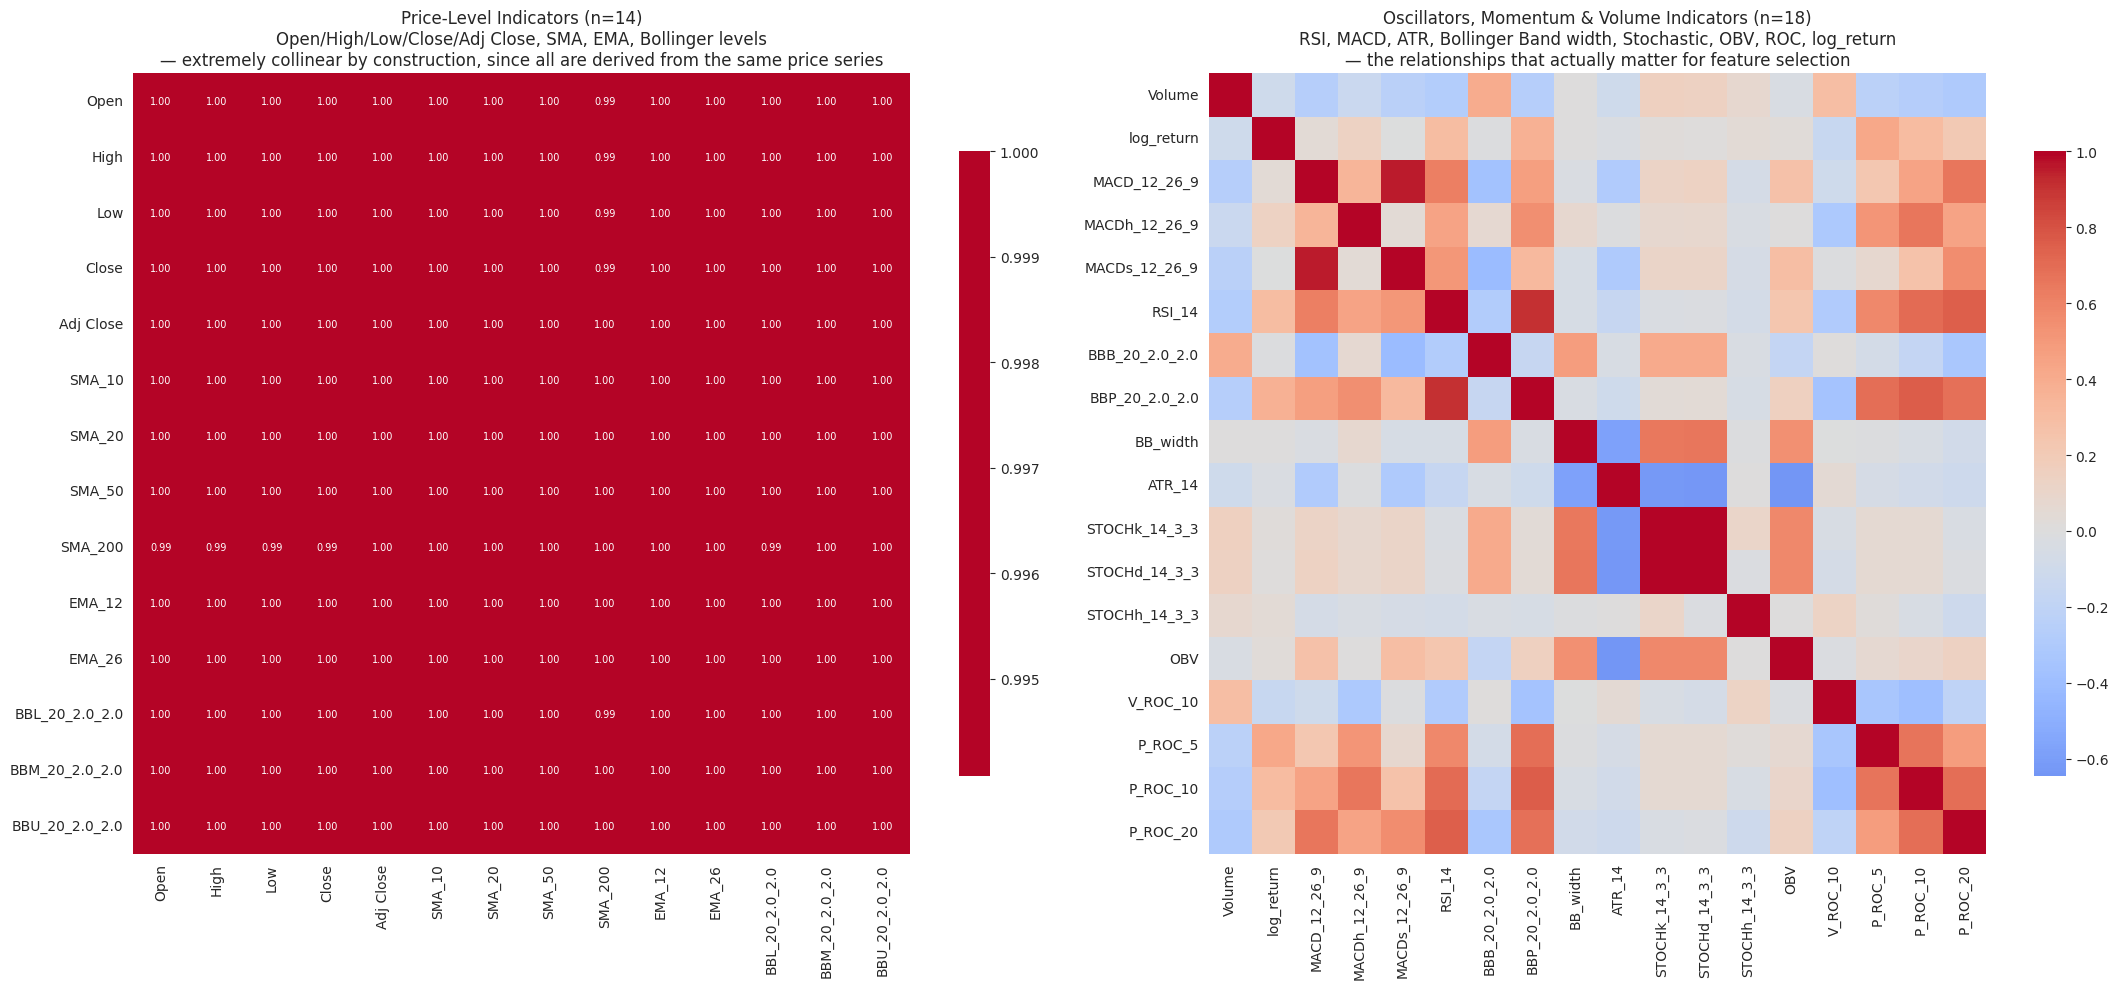


Price-level group (14 features): ['Open', 'High', 'Low', 'Close', 'Adj Close', 'SMA_10', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0']

Oscillator/momentum group (18 features): ['Volume', 'log_return', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'RSI_14', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0', 'BB_width', 'ATR_14', 'STOCHk_14_3_3', 'STOCHd_14_3_3', 'STOCHh_14_3_3', 'OBV', 'V_ROC_10', 'P_ROC_5', 'P_ROC_10', 'P_ROC_20']


In [ ]:
# Full correlation matrix + high-correlation pairs
numeric_cols = spy_feat.select_dtypes(include=[np.number]).columns
corr = spy_feat[numeric_cols].corr()

high_corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr_pairs.columns = ["feature_1", "feature_2", "corr"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["corr"].abs() > 0.90].sort_values(
    "corr", ascending=False)
print(f"{len(high_corr_pairs)} feature pairs with |r| > 0.90 (candidates for PCA):")
print(high_corr_pairs.to_string(index=False))

PRICE_LEVEL_GROUP = [c for c in [
    "Open", "High", "Low", "Close", "Adj Close",
    "SMA_10", "SMA_20", "SMA_50", "SMA_200", "EMA_12", "EMA_26",
    "BBL_20_2.0", "BBM_20_2.0", "BBU_20_2.0", "BBL_20_2.0_2.0", "BBM_20_2.0_2.0", "BBU_20_2.0_2.0"
] if c in numeric_cols]

OSCILLATOR_GROUP = [c for c in numeric_cols if c not in PRICE_LEVEL_GROUP]

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

sns.heatmap(spy_feat[PRICE_LEVEL_GROUP].corr(), cmap="coolwarm", center=0, annot=True,
            fmt=".2f", annot_kws={"size": 7}, ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title(f"Price-Level Indicators (n={len(PRICE_LEVEL_GROUP)})\n"
                   "Open/High/Low/Close/Adj Close, SMA, EMA, Bollinger levels\n"
                   "— extremely collinear by construction, since all are derived from the same price series")
axes[0].tick_params(axis='x', rotation=90)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(spy_feat[OSCILLATOR_GROUP].corr(), cmap="coolwarm", center=0, annot=False,
            ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title(f"Oscillators, Momentum & Volume Indicators (n={len(OSCILLATOR_GROUP)})\n"
                   "RSI, MACD, ATR, Bollinger Band width, Stochastic, OBV, ROC, log_return\n"
                   "— the relationships that actually matter for feature selection")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

print(f"\nPrice-level group ({len(PRICE_LEVEL_GROUP)} features): {PRICE_LEVEL_GROUP}")
print(f"\nOscillator/momentum group ({len(OSCILLATOR_GROUP)} features): {OSCILLATOR_GROUP}")

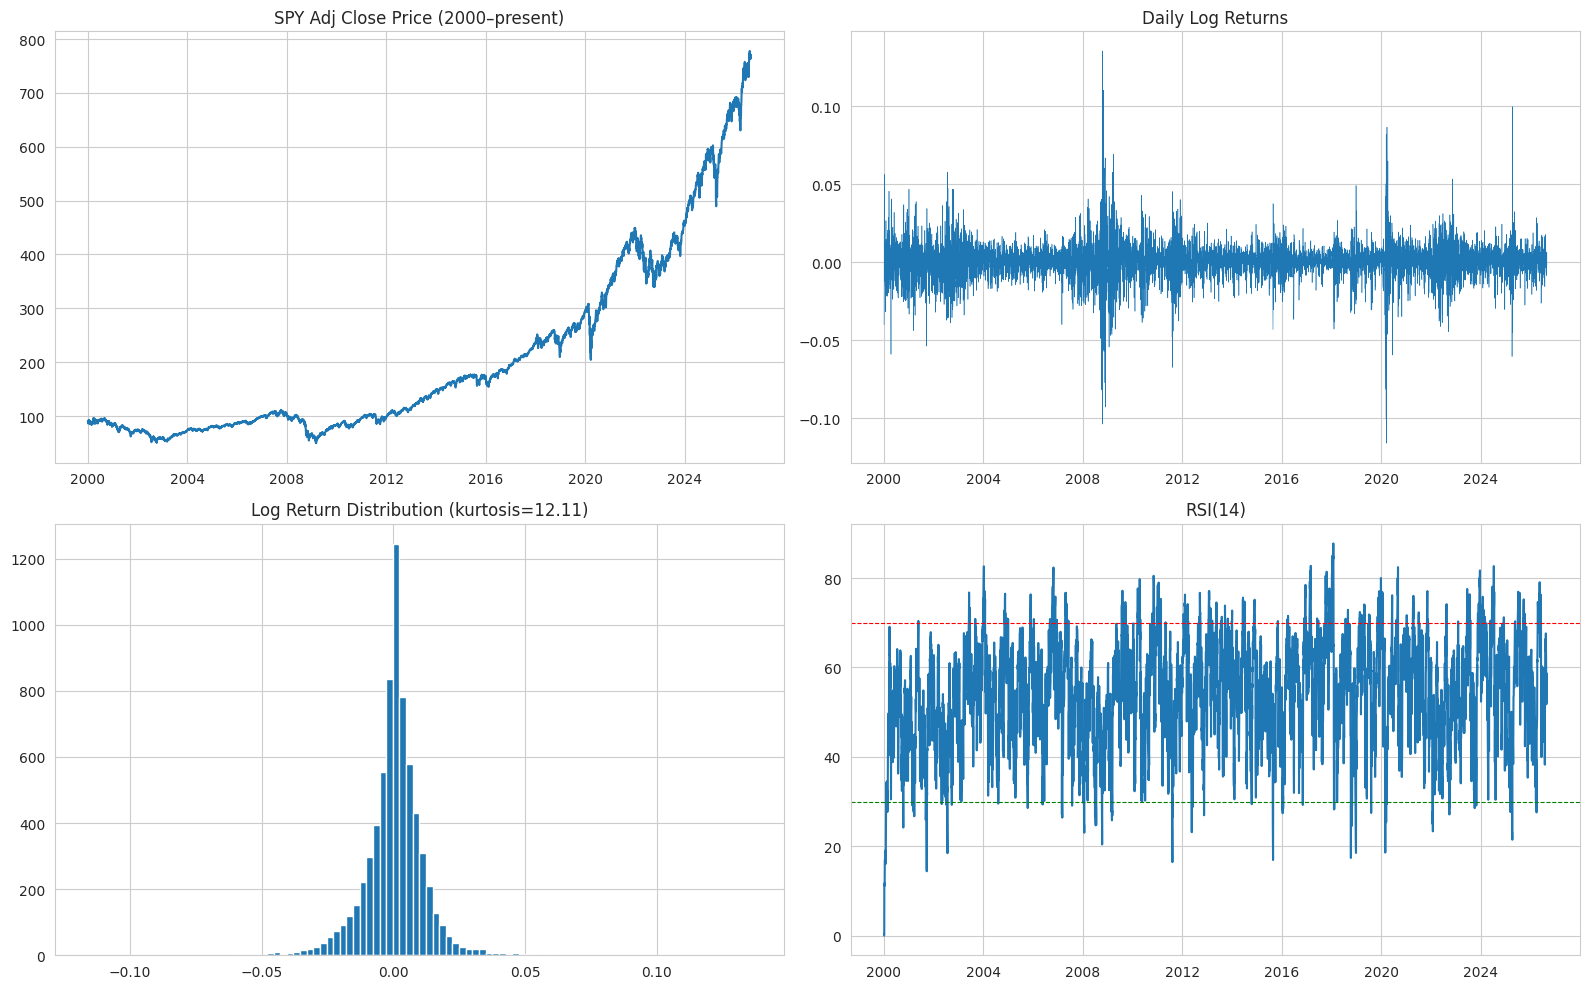

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(spy_feat["Date"], spy_feat["Adj Close"])
axes[0, 0].set_title("SPY Adj Close Price (2000–present)")

axes[0, 1].plot(spy_feat["Date"], spy_feat["log_return"], linewidth=0.4)
axes[0, 1].set_title("Daily Log Returns")

axes[1, 0].hist(spy_feat["log_return"].dropna(), bins=100)
axes[1, 0].set_title(f"Log Return Distribution (kurtosis={spy_feat['log_return'].kurtosis():.2f})")

axes[1, 1].plot(spy_feat["Date"], spy_feat["RSI_14"])
axes[1, 1].axhline(70, color="r", linestyle="--", linewidth=0.8)
axes[1, 1].axhline(30, color="g", linestyle="--", linewidth=0.8)
axes[1, 1].set_title("RSI(14)")

plt.tight_layout()
plt.show()


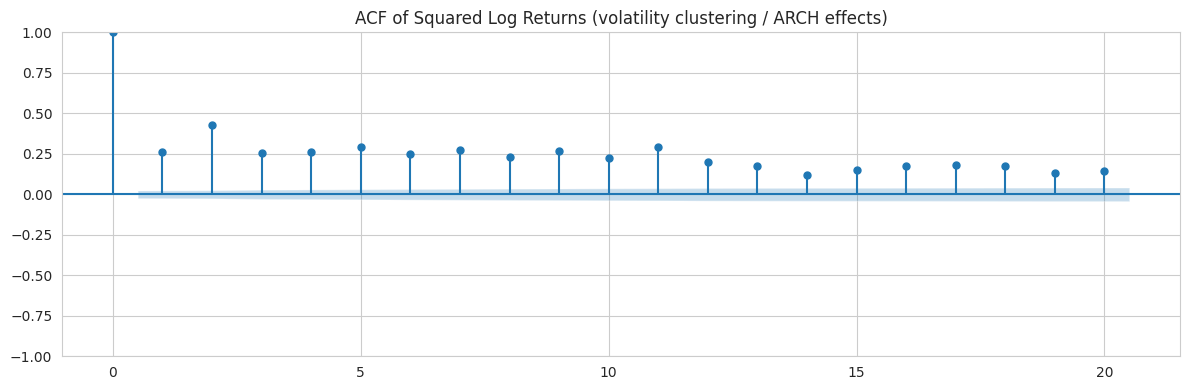

In [ ]:
# Volatility clustering — ACF of squared returns
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf((spy_feat["log_return"].dropna() ** 2), lags=20, ax=ax)
ax.set_title("ACF of Squared Log Returns (volatility clustering / ARCH effects)")
plt.tight_layout()
plt.show()


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_result = acorr_ljungbox(spy_feat["log_return"].dropna() ** 2, lags=[20], return_df=True)
print(lb_result)

        lb_stat  lb_pvalue
20  7726.915121        0.0


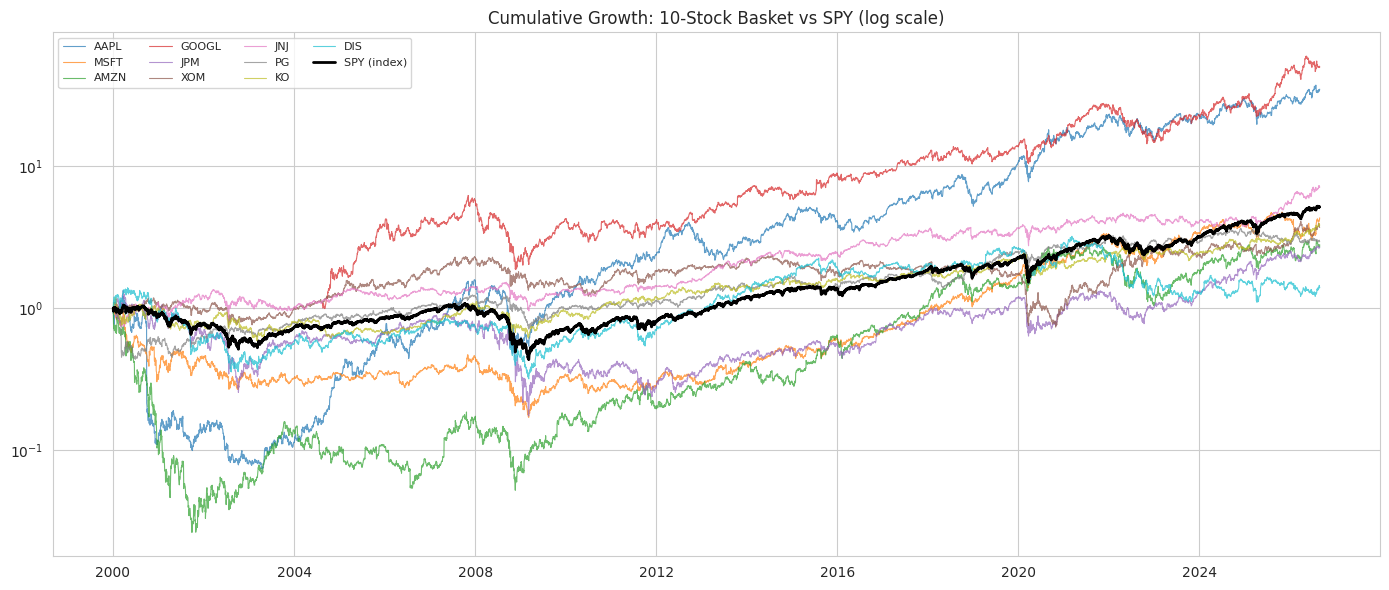

In [ ]:
# Sector-spread sanity check: cumulative returns of all 10 stocks vs SPY
fig, ax = plt.subplots(figsize=(14, 6))
for t, df in stock_features.items():
    cum_ret = (1 + df["log_return"].fillna(0)).cumprod()
    ax.plot(df["Date"], cum_ret, label=t, linewidth=0.8, alpha=0.7)

spy_cum = (1 + spy_feat["log_return"].fillna(0)).cumprod()
ax.plot(spy_feat["Date"], spy_cum, label="SPY (index)", color="black", linewidth=2)

ax.set_yscale("log")
ax.set_title("Cumulative Growth: 10-Stock Basket vs SPY (log scale)")
ax.legend(loc="upper left", ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
for t, df in stock_features.items():
    big_moves = df[df["log_return"].abs() > 0.3]  # >30% single-day moves are almost never real
    if not big_moves.empty:
        print(f"\n{t}:")
        print(big_moves[["Date", "Close", "Adj Close", "log_return"]])


AAPL:
          Date     Close  Adj Close  log_return
194 2000-09-29  0.459821   0.385086   -0.731248

PG:
         Date  Close  Adj Close  log_return
46 2000-03-07   30.5  15.085794    -0.36005


Kaggle SPY file covers: 1993-01-29 -> 2020-04-01
Merged on 5093 overlapping dates
Correlation between Kaggle and Yahoo daily returns: 1.0000


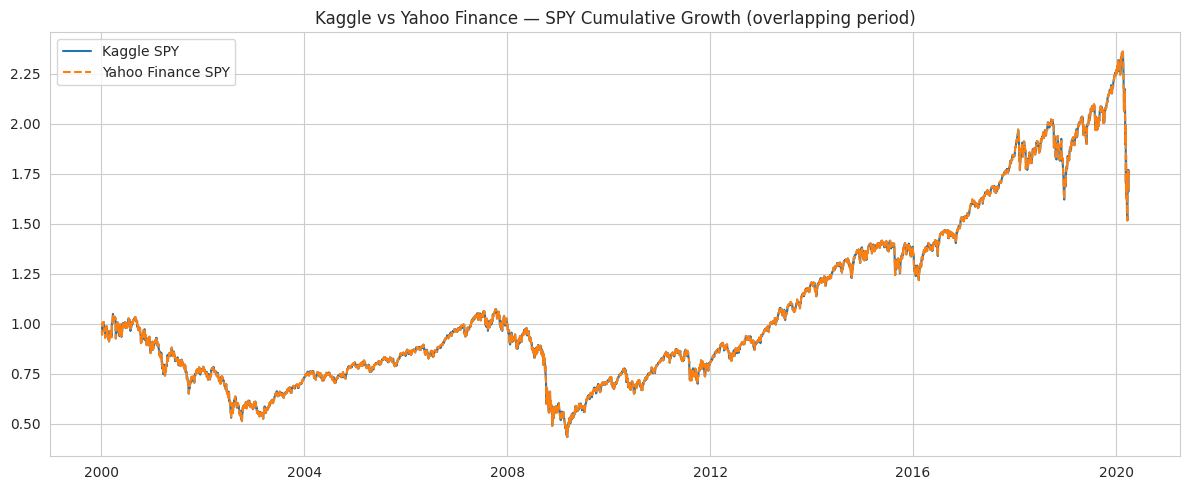

In [ ]:
# Performing Cross-validation: Kaggle vs Yahoo Finance (SPY, overlapping period only)
kaggle_spy_path = os.path.join(ETFS_DIR, "SPY.csv")

if os.path.isfile(kaggle_spy_path):
    kaggle_spy = pd.read_csv(kaggle_spy_path, parse_dates=["Date"])
    kaggle_spy = normalise_columns(kaggle_spy).sort_values("Date").reset_index(drop=True)
    if "Adj Close" not in kaggle_spy.columns:
        kaggle_spy["Adj Close"] = kaggle_spy["Close"]

    overlap_end = kaggle_spy["Date"].max()
    print(f"Kaggle SPY file covers: {kaggle_spy['Date'].min().date()} -> {overlap_end.date()}")

    # Restrict Yahoo data to the same overlapping window
    yahoo_overlap = spy_raw[spy_raw["Date"] <= overlap_end].copy()
    kaggle_overlap = kaggle_spy[kaggle_spy["Date"] <= overlap_end].copy()

    # Compare daily returns (shape), not raw adjusted prices (which use different rulers)
    kaggle_overlap["kaggle_return"] = np.log(kaggle_overlap["Adj Close"] / kaggle_overlap["Adj Close"].shift(1))
    yahoo_overlap["yahoo_return"] = np.log(yahoo_overlap["Adj Close"] / yahoo_overlap["Adj Close"].shift(1))

    merged = pd.merge(
        kaggle_overlap[["Date", "kaggle_return"]],
        yahoo_overlap[["Date", "yahoo_return"]],
        on="Date",
        how="inner"
    ).dropna()

    print(f"Merged on {len(merged)} overlapping dates")

    correlation = merged["kaggle_return"].corr(merged["yahoo_return"])
    print(f"Correlation between Kaggle and Yahoo daily returns: {correlation:.4f}")

    # Visual check: cumulative growth, both rebased to start at 1.0
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(merged["Date"], (1 + merged["kaggle_return"]).cumprod(), label="Kaggle SPY")
    ax.plot(merged["Date"], (1 + merged["yahoo_return"]).cumprod(), label="Yahoo Finance SPY", linestyle="--")
    ax.set_title("Kaggle vs Yahoo Finance — SPY Cumulative Growth (overlapping period)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Kaggle SPY.csv not found — skipping cross-validation (this is optional, not required to proceed).")

In [ ]:
# Chronological split by fixed dates (keeps COVID + 2022 bear market in test set)
TRAIN_END = "2017-01-01"   # train: everything before this date
VAL_END = "2020-01-01"     # validation: TRAIN_END -> VAL_END
                            # test: everything from VAL_END onward

train_df = spy_feat[spy_feat["Date"] < TRAIN_END].reset_index(drop=True)
val_df = spy_feat[(spy_feat["Date"] >= TRAIN_END) & (spy_feat["Date"] < VAL_END)].reset_index(drop=True)
test_df = spy_feat[spy_feat["Date"] >= VAL_END].reset_index(drop=True)

total_rows = len(train_df) + len(val_df) + len(test_df)

print(f"Train: {train_df['Date'].min().date()} -> {train_df['Date'].max().date()}  "
      f"({len(train_df)} rows, {len(train_df)/total_rows:.1%})")
print(f"Val:   {val_df['Date'].min().date()} -> {val_df['Date'].max().date()}  "
      f"({len(val_df)} rows, {len(val_df)/total_rows:.1%})")
print(f"Test:  {test_df['Date'].min().date()} -> {test_df['Date'].max().date()}  "
      f"({len(test_df)} rows, {len(test_df)/total_rows:.1%})")

# Sanity check: confirm no gaps/overlaps between splits
assert train_df["Date"].max() < val_df["Date"].min(), "Train/val overlap detected!"
assert val_df["Date"].max() < test_df["Date"].min(), "Val/test overlap detected!"
print("\nNo overlaps between splits — chronological integrity confirmed.")

Train: 2000-01-03 -> 2016-12-30  (4435 rows, 63.8%)
Val:   2017-01-02 -> 2019-12-31  (782 rows, 11.2%)
Test:  2020-01-01 -> 2026-08-28  (1738 rows, 25.0%)

No overlaps between splits — chronological integrity confirmed.


In [ ]:
# SPY (index-level) files
spy_feat.to_csv(os.path.join(OUT_DIR, "spy_features_full.csv"), index=False)
train_df.to_csv(os.path.join(OUT_DIR, "spy_train.csv"), index=False)
val_df.to_csv(os.path.join(OUT_DIR, "spy_val.csv"), index=False)
test_df.to_csv(os.path.join(OUT_DIR, "spy_test.csv"), index=False)

# Per-stock feature files
stock_out_dir = os.path.join(OUT_DIR, "stocks")
os.makedirs(stock_out_dir, exist_ok=True)
for t, df in stock_features.items():
    df.to_csv(os.path.join(stock_out_dir, f"{t}_features.csv"), index=False)

print("Saved:")
print(" -", os.path.join(OUT_DIR, "spy_features_full.csv"))
print(" -", os.path.join(OUT_DIR, "spy_train.csv / spy_val.csv / spy_test.csv"))
print(" -", stock_out_dir, f"({len(stock_features)} stock feature files)")


Saved:
 - /content/drive/MyDrive/dissertation_data/processed/spy_features_full.csv
 - /content/drive/MyDrive/dissertation_data/processed/spy_train.csv / spy_val.csv / spy_test.csv
 - /content/drive/MyDrive/dissertation_data/processed/stocks (10 stock feature files)


In [ ]:
print(spy_feat["Date"].diff().value_counts().head())

Date
1 days    5564
3 days    1390
Name: count, dtype: int64


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model

In [ ]:
from itertools import product

train_ret = train_df["log_return"].values

p_range = range(0, 6)
q_range = range(0, 6)

results = []
for p, q in product(p_range, q_range):
    if p == 0 and q == 0:
        continue
    try:
        model = ARIMA(train_ret, order=(p, 0, q))
        fit = model.fit()
        results.append({"p": p, "d": 0, "q": q, "AIC": fit.aic, "BIC": fit.bic})
    except Exception:
        continue

results_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
print("Top 10 models by AIC:")
results_df.head(10)


Top 10 models by AIC:


,p,d,q,AIC,BIC
0,0,0,5,-26467.229228,-26422.448248
1,5,0,0,-26466.090876,-26421.309896
2,1,0,1,-26465.974439,-26440.385307
3,1,0,5,-26465.800285,-26414.622022
4,0,0,2,-26465.406089,-26439.816957
5,2,0,5,-26465.064894,-26407.489348
6,2,0,0,-26464.402911,-26438.813780
7,5,0,1,-26464.232439,-26413.054176
8,3,0,5,-26464.002945,-26400.030116
9,0,0,3,-26463.800045,-26431.813631


In [ ]:
print("NaNs in train_ret:", np.isnan(train_ret).sum())
print("Infs in train_ret:", np.isinf(train_ret).sum())
print("train_ret length:", len(train_ret))
print(train_ret[:5])

NaNs in train_ret: 1
Infs in train_ret: 0
train_ret length: 4435
[        nan -0.0398915   0.00178733 -0.01620214  0.05645236]


In [ ]:
for p, q in product(p_range, q_range):
    if p == 0 and q == 0:
        continue
    try:
        model = ARIMA(train_ret, order=(p, 0, q))
        fit = model.fit()
        results.append({"p": p, "d": 0, "q": q, "AIC": fit.aic, "BIC": fit.bic})
    except Exception as e:
        print(f"({p},0,{q}) failed: {e}")
        continue

In [ ]:
best_p, best_d, best_q = results_df.iloc[0][["p", "d", "q"]].astype(int)
print(f"Selected model: ARIMA({best_p},{best_d},{best_q})  "
      f"AIC={results_df.iloc[0]['AIC']:.2f}  BIC={results_df.iloc[0]['BIC']:.2f}")

best_model = ARIMA(train_ret, order=(best_p, best_d, best_q))
best_fit = best_model.fit()
print(best_fit.summary())


Selected model: ARIMA(0,0,5)  AIC=-26467.23  BIC=-26422.45
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4435
Model:                 ARIMA(0, 0, 5)   Log Likelihood               13240.615
Date:                Sun, 30 Aug 2026   AIC                         -26467.229
Time:                        02:27:26   BIC                         -26422.448
Sample:                             0   HQIC                        -26451.439
                               - 4435                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.995      0.320      -0.000       0.000
ma.L1         -0.0682      0.009     -7.397      0.000      -0.086      

In [ ]:
residuals = best_fit.resid
print("NaNs in residuals:", np.isnan(residuals).sum())
print("Infs in residuals:", np.isinf(residuals).sum())
print("Length:", len(residuals))

lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print(lb_test)

NaNs in residuals: 1
Infs in residuals: 0
Length: 4435
    lb_stat  lb_pvalue
10      NaN        NaN
20      NaN        NaN


In [ ]:
residuals = pd.Series(residuals).replace([np.inf, -np.inf], np.nan).dropna().values
lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print(lb_test)

      lb_stat  lb_pvalue
10  13.515287   0.196270
20  34.095261   0.025487


      lb_stat  lb_pvalue
10  13.515287   0.196270
20  34.095261   0.025487


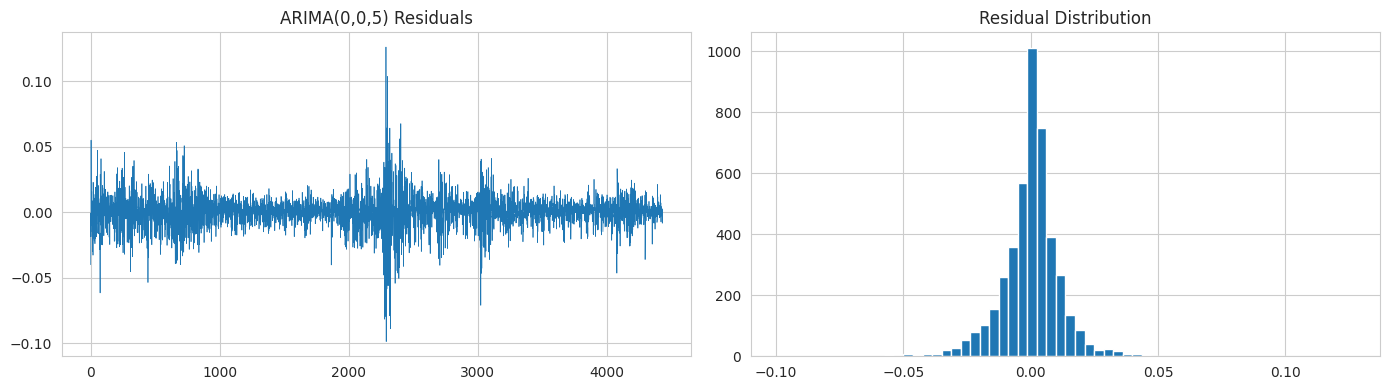

In [ ]:
lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print(lb_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(residuals, linewidth=0.5)
axes[0].set_title(f"ARIMA({best_p},{best_d},{best_q}) Residuals")
axes[1].hist(residuals, bins=60)
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()


In [ ]:
garch_model = arch_model(residuals * 100, vol="Garch", p=1, q=1, dist="normal")
garch_fit = garch_model.fit(disp="off")
print(garch_fit.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6173.86
Distribution:                  Normal   AIC:                           12355.7
Method:            Maximum Likelihood   BIC:                           12381.3
                                        No. Observations:                 4434
Date:                Sun, Aug 30 2026   Df Residuals:                     4433
Time:                        02:27:31   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0462  1.276e-02      3.617  2.986e-04 [2.

In [ ]:
persistence = 0.0952 + 0.8882
half_life = np.log(0.5) / np.log(persistence)
print(f"Volatility half-life: {half_life:.1f} trading days")

Volatility half-life: 41.4 trading days


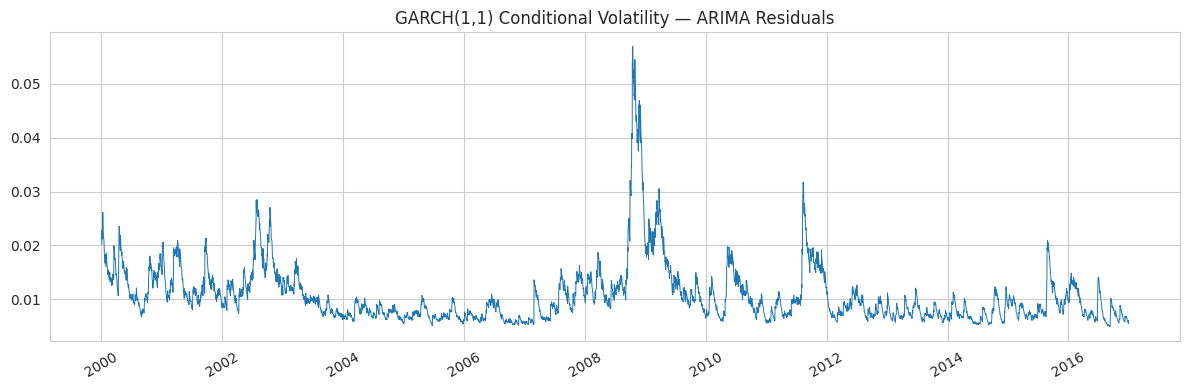

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
train_dates = train_df["Date"].iloc[-len(garch_fit.conditional_volatility):].values
ax.plot(train_dates, garch_fit.conditional_volatility / 100, linewidth=0.7)
ax.set_title("GARCH(1,1) Conditional Volatility — ARIMA Residuals")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
FULL_SERIES = pd.concat([train_df, val_df, test_df], ignore_index=True)
FULL_SERIES = FULL_SERIES.dropna(subset=["log_return"]).reset_index(drop=True)

MIN_WINDOW = 500
REFIT_EVERY = 21          # re-fit roughly monthly (21 trading days)
test_start_idx = FULL_SERIES[FULL_SERIES["Date"] >= test_df["Date"].min()].index[0]

predictions, actuals, pred_dates = [], [], []

idx = test_start_idx
while idx < len(FULL_SERIES):
    window_end = idx
    history = FULL_SERIES["log_return"].values[max(0, window_end - 2000):window_end]  # capped expanding window
    if len(history) < MIN_WINDOW:
        idx += REFIT_EVERY
        continue

    try:
        step_model = ARIMA(history, order=(best_p, best_d, best_q))
        step_fit = step_model.fit()
        n_steps = min(REFIT_EVERY, len(FULL_SERIES) - idx)
        forecast = step_fit.forecast(steps=n_steps)

        predictions.extend(forecast)
        actuals.extend(FULL_SERIES["log_return"].values[idx: idx + n_steps])
        pred_dates.extend(FULL_SERIES["Date"].values[idx: idx + n_steps])
    except Exception as e:
        print(f"Skipping window at idx={idx}: {e}")

    idx += REFIT_EVERY

wf_results = pd.DataFrame({
    "Date": pred_dates,
    "actual": actuals,
    "predicted": predictions
})
wf_results["Date"] = pd.to_datetime(wf_results["Date"])
print(f"Walk-forward forecasts generated: {len(wf_results)} test-period predictions")
wf_results.head()


Walk-forward forecasts generated: 1738 test-period predictions


,Date,actual,predicted
0,2020-01-01,0.000000,0.000510
1,2020-01-02,0.009309,0.000153
2,2020-01-03,-0.007601,0.000743
3,2020-01-06,0.003808,0.000724
4,2020-01-07,-0.002816,0.000394


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    da = np.mean(np.sign(actual) == np.sign(predicted)) * 100
    return {"RMSE": rmse, "MAE": mae, "Directional Accuracy (%)": da}

arima_metrics = compute_metrics(wf_results["actual"], wf_results["predicted"])
print("ARIMA walk-forward performance (full test period, 2020–2026):")
for k, v in arima_metrics.items():
    print(f"  {k}: {v:.4f}")


ARIMA walk-forward performance (full test period, 2020–2026):
  RMSE: 0.0125
  MAE: 0.0080
  Directional Accuracy (%): 52.8769


In [ ]:
REGIMES = {
    "COVID crash":      ("2020-02-15", "2020-04-30"),
    "COVID recovery":   ("2020-05-01", "2021-12-31"),
    "2022 bear market": ("2022-01-01", "2022-12-31"),
    "2023-24 recovery": ("2023-01-01", "2024-12-31"),
    "2025-26 recent":   ("2025-01-01", "2026-12-31"),
}

regime_rows = []
for name, (start, end) in REGIMES.items():
    mask = (wf_results["Date"] >= start) & (wf_results["Date"] <= end)
    subset = wf_results[mask]
    if len(subset) < 5:
        continue
    m = compute_metrics(subset["actual"], subset["predicted"])
    m["Regime"] = name
    m["N days"] = len(subset)
    regime_rows.append(m)

regime_df = pd.DataFrame(regime_rows)[["Regime", "N days", "RMSE", "MAE", "Directional Accuracy (%)"]]
regime_df


,Regime,N days,RMSE,MAE,Directional Accuracy (%)
0,COVID crash,54,0.039896,0.029834,48.148148
1,COVID recovery,436,0.009754,0.007130,56.422018
2,2022 bear market,260,0.015127,0.011718,41.923077
3,2023-24 recovery,522,0.007936,0.005927,54.980843
4,2025-26 recent,433,0.010616,0.006751,53.348730


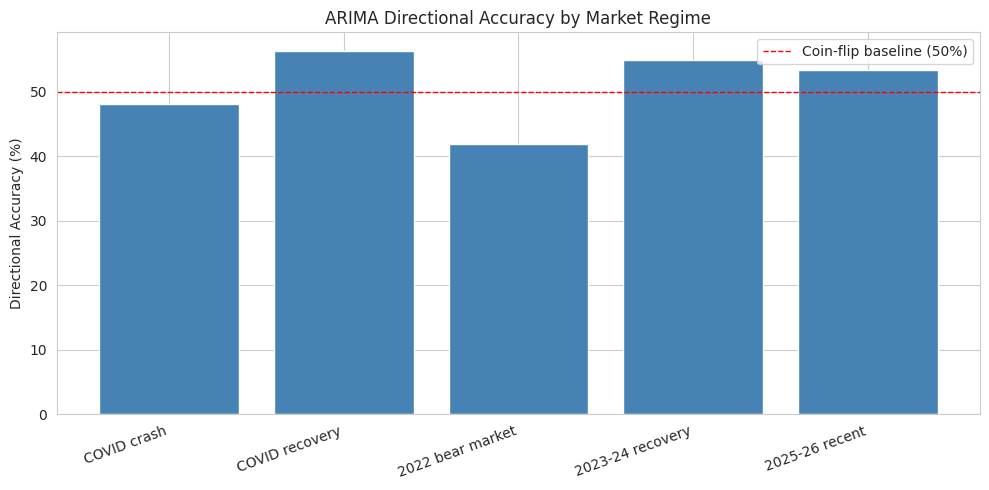

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(regime_df["Regime"], regime_df["Directional Accuracy (%)"], color="steelblue")
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="Coin-flip baseline (50%)")
ax.set_ylabel("Directional Accuracy (%)")
ax.set_title("ARIMA Directional Accuracy by Market Regime")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
!pip install -q dm-test 2>/dev/null || echo

def diebold_mariano(actual, pred1, pred2, h=1, crit="MSE"):
    """Manual Diebold-Mariano test (Diebold & Mariano, 1995).
    Tests whether pred1's forecast errors are significantly different from pred2's.
    Returns (DM statistic, p-value). Negative DM => pred1 more accurate than pred2.
    """
    actual, pred1, pred2 = map(np.asarray, (actual, pred1, pred2))
    e1 = actual - pred1
    e2 = actual - pred2

    if crit == "MSE":
        d = e1**2 - e2**2
    elif crit == "MAE":
        d = np.abs(e1) - np.abs(e2)
    else:
        raise ValueError("crit must be 'MSE' or 'MAE'")

    T = len(d)
    d_bar = d.mean()

    # Newey-West style variance with h-1 lag autocorrelation correction
    gamma0 = np.var(d, ddof=0)
    var_d = gamma0
    for lag in range(1, h):
        gamma = np.cov(d[lag:], d[:-lag])[0, 1]
        var_d += 2 * gamma
    var_d /= T

    dm_stat = d_bar / np.sqrt(var_d)
    from scipy.stats import t as t_dist
    p_value = 2 * (1 - t_dist.cdf(np.abs(dm_stat), df=T - 1))
    return dm_stat, p_value


# Persistence naive: predict tomorrow's return will equal today's (not "always zero")
naive_pred = wf_results["actual"].shift(1).fillna(0).values

arima_naive_metrics = compute_metrics(wf_results["actual"], naive_pred)
print("Naive persistence benchmark performance:")
for k, v in arima_naive_metrics.items():
    print(f"  {k}: {v:.4f}")

dm_stat, dm_p = diebold_mariano(
    wf_results["actual"].values, wf_results["predicted"].values, naive_pred, h=1, crit="MSE"
)
print(f"\nDiebold-Mariano test (ARIMA vs persistence naive):")
print(f"  DM statistic = {dm_stat:.4f}")
print(f"  p-value      = {dm_p:.4f}")


Naive persistence benchmark performance:
  RMSE: 0.0189
  MAE: 0.0120
  Directional Accuracy (%): 45.5696

Diebold-Mariano test (ARIMA vs persistence naive):
  DM statistic = -6.2080
  p-value      = 0.0000


In [ ]:
arima_out_dir = os.path.join(OUT_DIR, "arima")
os.makedirs(arima_out_dir, exist_ok=True)

wf_results.to_csv(os.path.join(arima_out_dir, "arima_walkforward_predictions.csv"), index=False)
regime_df.to_csv(os.path.join(arima_out_dir, "arima_regime_metrics.csv"), index=False)

pd.DataFrame({"residual": residuals}).to_csv(
    os.path.join(arima_out_dir, "arima_training_residuals.csv"), index=False
)




In [ ]:
summary = {
    "order": f"({best_p},{best_d},{best_q})",
    "AIC": results_df.iloc[0]["AIC"],
    "BIC": results_df.iloc[0]["BIC"],
    "ljung_box_p_lag20": lb_test.loc[20, "lb_pvalue"],
    **arima_metrics,
    "dm_stat_vs_persistence_naive": dm_stat,
    "dm_pvalue_vs_persistence_naive": dm_p,
}
pd.DataFrame([summary]).to_csv(os.path.join(arima_out_dir, "arima_summary.csv"), index=False)
print(pd.DataFrame([summary]).T)

                                           0
order                                (0,0,5)
AIC                            -26467.229228
BIC                            -26422.448248
ljung_box_p_lag20                   0.025487
RMSE                                0.012472
MAE                                 0.008035
Directional Accuracy (%)            52.87687
dm_stat_vs_persistence_naive       -6.207994
dm_pvalue_vs_persistence_naive           0.0


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf

# --- added for reproducibility ---
os.environ['PYTHONHASHSEED'] = '0'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
tf.config.experimental.enable_op_determinism()
# ----------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

from google.colab import drive
import os

if not os.path.isdir('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted — skipping.")

GPU available: True
Drive already mounted — skipping.


In [ ]:
DATA_DIR = "/content/drive/MyDrive/dissertation_data"
OUT_DIR = os.path.join(DATA_DIR, "processed")
LSTM_OUT_DIR = os.path.join(OUT_DIR, "lstm")
os.makedirs(LSTM_OUT_DIR, exist_ok=True)

train_df = pd.read_csv(os.path.join(OUT_DIR, "spy_train.csv"), parse_dates=["Date"])
val_df = pd.read_csv(os.path.join(OUT_DIR, "spy_val.csv"), parse_dates=["Date"])
test_df = pd.read_csv(os.path.join(OUT_DIR, "spy_test.csv"), parse_dates=["Date"])

for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name}: {df['Date'].min().date()} -> {df['Date'].max().date()}  ({len(df)} rows)")

# Drop rows with any NaN (indicator warm-up period, only affects the start of train_df)
train_df = train_df.dropna().reset_index(drop=True)
val_df = val_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)
print(f"\nAfter dropping NaN warm-up rows: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")



Train: 2000-01-03 -> 2016-12-30  (4435 rows)
Val: 2017-01-02 -> 2019-12-31  (782 rows)
Test: 2020-01-01 -> 2026-08-28  (1738 rows)

After dropping NaN warm-up rows: train=4236, val=782, test=1738


In [ ]:
FEATURE_COLS = [
    "log_return", "SMA_10", "SMA_20", "SMA_50", "SMA_200", "EMA_12", "EMA_26",
    "MACD_12_26_9", "MACDh_12_26_9", "MACDs_12_26_9", "RSI_14",
    "BB_width", "ATR_14", "STOCHk_14_3_3", "STOCHd_14_3_3",
    "OBV", "V_ROC_10", "P_ROC_5", "P_ROC_10", "P_ROC_20"
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in train_df.columns]
TARGET_COL = "log_return"
LOOKBACK = 60

print(f"Using {len(FEATURE_COLS)} features: {FEATURE_COLS}")


Using 20 features: ['log_return', 'SMA_10', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'RSI_14', 'BB_width', 'ATR_14', 'STOCHk_14_3_3', 'STOCHd_14_3_3', 'OBV', 'V_ROC_10', 'P_ROC_5', 'P_ROC_10', 'P_ROC_20']


In [ ]:
def build_sequences(df, feature_cols, target_col, lookback):
    """Build (lookback x n_features) input windows and next-day target values."""
    data = df[feature_cols].values
    target = df[target_col].values

    X, y, dates = [], [], []
    for i in range(lookback, len(df)):
        X.append(data[i - lookback:i])
        y.append(target[i])           # predict next-day return (day i, using days i-lookback..i-1)
        dates.append(df["Date"].iloc[i])

    return np.array(X), np.array(y), np.array(dates)


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_df[FEATURE_COLS])

train_scaled = train_df.copy()
val_scaled = val_df.copy()
test_scaled = test_df.copy()

train_scaled[FEATURE_COLS] = scaler.transform(train_df[FEATURE_COLS])
val_scaled[FEATURE_COLS] = scaler.transform(val_df[FEATURE_COLS])
test_scaled[FEATURE_COLS] = scaler.transform(test_df[FEATURE_COLS])

X_train, y_train, dates_train = build_sequences(train_scaled, FEATURE_COLS, TARGET_COL, LOOKBACK)
X_val, y_val, dates_val = build_sequences(val_scaled, FEATURE_COLS, TARGET_COL, LOOKBACK)
X_test, y_test, dates_test = build_sequences(test_scaled, FEATURE_COLS, TARGET_COL, LOOKBACK)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test: {y_test.shape}")


X_train: (4176, 60, 20), y_train: (4176,)
X_val:   (722, 60, 20), y_val: (722,)
X_test:  (1678, 60, 20), y_test: (1678,)


In [ ]:
def build_lstm_model(input_shape, lr_schedule):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr_schedule), loss="mse", metrics=["mae"])
    return model


EPOCHS = 100
BATCH_SIZE = 32
steps_per_epoch = len(X_train) // BATCH_SIZE

lr_schedule = CosineDecay(initial_learning_rate=1e-3, decay_steps=steps_per_epoch * EPOCHS)

lstm_model = build_lstm_model((LOOKBACK, len(FEATURE_COLS)), lr_schedule)
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,721 (135.63 KB)

 Trainable params: 34,721 (135.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_checkpoint_path = os.path.join(LSTM_OUT_DIR, "best_lstm.keras")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ModelCheckpoint(lstm_checkpoint_path, monitor="val_loss", save_best_only=True)
]

history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0103 - mae: 0.0724 - val_loss: 0.0028 - val_mae: 0.0442
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0044 - mae: 0.0490 - val_loss: 0.0024 - val_mae: 0.0416
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0039 - mae: 0.0457 - val_loss: 0.0017 - val_mae: 0.0330
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0035 - mae: 0.0428 - val_loss: 0.0018 - val_mae: 0.0341
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0033 - mae: 0.0409 - val_loss: 0.0021 - val_mae: 0.0389
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0031 - mae: 0.0396 - val_loss: 0.0020 - val_mae: 0.0372
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0031 - mae: 0.0387 - val_loss: 0.0025 - val_mae: 0.0438
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0029 - mae: 0.0376 - val_loss: 0.0020 - val_mae: 0.0376
Epoch 9/100
131/131 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
lstm_pred_check = lstm_model.predict(X_val[:20], verbose=0).flatten()
print("Sample predictions:", lstm_pred_check)
print("Prediction std dev:", lstm_pred_check.std())
print("Actual y_val std dev:", y_val.std())

Sample predictions: [0.43600667 0.436064   0.4360212  0.4358911  0.43571246 0.4355691
 0.4355138  0.4354328  0.43541515 0.4353727  0.43533188 0.43529248
 0.43527913 0.435345   0.43549818 0.4356348  0.43558943 0.4355266
 0.43545663 0.43533713]
Prediction std dev: 0.00024429843
Actual y_val std dev: 0.034171044654564525


In [ ]:
# Checking what 0.4344 in scaled-space corresponds to in real log-return terms
import numpy as np
target_idx = FEATURE_COLS.index("log_return")
real_value = scaler.inverse_transform(
    np.tile([0.4344], (1, len(FEATURE_COLS)))
)[0, target_idx]
print(f"Scaled prediction 0.4344 corresponds to real log_return: {real_value:.6f}")
print(f"Training data's mean log_return: {train_df['log_return'].mean():.6f}")

Scaled prediction 0.4344 corresponds to real log_return: 0.000277
Training data's mean log_return: 0.000177


In [ ]:
print(f"Training stopped at epoch: {len(history.history['loss'])}")
print(f"Best val_loss: {min(history.history['val_loss']):.6f} at epoch {np.argmin(history.history['val_loss']) + 1}")

Training stopped at epoch: 41
Best val_loss: 0.001165 at epoch 26


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    da = np.mean(np.sign(actual) == np.sign(predicted)) * 100
    return {"RMSE": rmse, "MAE": mae, "Directional Accuracy (%)": da}

In [ ]:
lstm_pred = lstm_model.predict(X_test, verbose=0).flatten()

lstm_results = pd.DataFrame({
    "Date": pd.to_datetime(dates_test),
    "actual": y_test,
    "lstm_pred": lstm_pred
})

lstm_metrics = compute_metrics(lstm_results["actual"], lstm_results["lstm_pred"])
print("LSTM (2020-2026 test period):")
for k, v in lstm_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\n(Compare to ARIMA: RMSE=0.0125, MAE=0.0081, DA=52.93%)")

LSTM (2020-2026 test period):
  RMSE: 0.0457
  MAE: 0.0318
  Directional Accuracy (%): 100.0000

(Compare to ARIMA: RMSE=0.0125, MAE=0.0081, DA=52.93%)


In [ ]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("First few y_test values:", y_test[:5])
print("First few dates_test:", dates_test[:5])

X_test shape: (1678, 60, 20)
y_test shape: (1678,)
First few y_test values: [0.4953559  0.67046979 0.30683369 0.56684119 0.37046212]
First few dates_test: [Timestamp('2020-03-25 00:00:00') Timestamp('2020-03-26 00:00:00')
 Timestamp('2020-03-27 00:00:00') Timestamp('2020-03-30 00:00:00')
 Timestamp('2020-03-31 00:00:00')]


In [ ]:
print(lstm_results[["actual", "lstm_pred"]].head(10))
print("Correlation between actual and predicted:", lstm_results["actual"].corr(lstm_results["lstm_pred"]))

     actual  lstm_pred
0  0.495356   0.448593
1  0.670470   0.447889
2  0.306834   0.446687
3  0.566841   0.445356
4  0.370462   0.444152
5  0.240741   0.443027
6  0.528606   0.442209
7  0.372376   0.441548
8  0.704990   0.440898
9  0.437500   0.440154
Correlation between actual and predicted: 0.048150875460564985


In [ ]:
print("Any zero actuals:", (lstm_results["actual"] == 0).sum())
print("Any zero predictions:", (lstm_results["lstm_pred"] == 0).sum())

Any zero actuals: 0
Any zero predictions: 0


In [ ]:
# The target column's position within FEATURE_COLS, needed to invert just that one column
target_idx = FEATURE_COLS.index(TARGET_COL)

def inverse_transform_target(scaled_values, scaler, feature_cols, target_idx):
    """Undo MinMax scaling for a single target column."""
    dummy = np.zeros((len(scaled_values), len(feature_cols)))
    dummy[:, target_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, target_idx]

y_test_real = inverse_transform_target(y_test, scaler, FEATURE_COLS, target_idx)
lstm_pred_real = inverse_transform_target(lstm_pred, scaler, FEATURE_COLS, target_idx)

lstm_results = pd.DataFrame({
    "Date": pd.to_datetime(dates_test),
    "actual": y_test_real,
    "lstm_pred": lstm_pred_real
})

print(lstm_results.head())

lstm_metrics = compute_metrics(lstm_results["actual"], lstm_results["lstm_pred"])
print("\nLSTM (2020-2026 test period) — corrected, real-scale:")
for k, v in lstm_metrics.items():
    print(f"  {k}: {v:.4f}")

        Date    actual  lstm_pred
0 2020-03-25  0.014859   0.003673
1 2020-03-26  0.056749   0.003504
2 2020-03-27 -0.030238   0.003217
3 2020-03-30  0.031959   0.002898
4 2020-03-31 -0.015017   0.002610

LSTM (2020-2026 test period) — corrected, real-scale:
  RMSE: 0.0109
  MAE: 0.0076
  Directional Accuracy (%): 52.1454


In [ ]:
lstm_pred_check = lstm_model.predict(X_val[:50], verbose=0).flatten()
print("Prediction std dev:", lstm_pred_check.std())
print("Actual y_val std dev:", y_val.std())

Prediction std dev: 0.00038090363
Actual y_val std dev: 0.034171044654564525


In [ ]:
# Running this multiple times with different seeds, collecting each run's metrics
seeds_to_try = [42, 123, 7, 2024, 99]
multi_run_results = []

for seed in seeds_to_try:
    np.random.seed(seed)
    tf.random.set_seed(seed)

    lr_schedule_run = CosineDecay(initial_learning_rate=1e-4, decay_steps=steps_per_epoch * EPOCHS)
    model_run = build_lstm_model((LOOKBACK, len(FEATURE_COLS)), lr_schedule_run)

    callbacks_run = [EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]
    hist_run = model_run.fit(X_train, y_train, validation_data=(X_val, y_val),
                              epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks_run, verbose=0)

    pred_run = model_run.predict(X_test, verbose=0).flatten()
    pred_real = inverse_transform_target(pred_run, scaler, FEATURE_COLS, target_idx)
    m = compute_metrics(y_test_real, pred_real)
    m["seed"] = seed
    m["best_epoch"] = np.argmin(hist_run.history["val_loss"]) + 1
    multi_run_results.append(m)
    print(f"Seed {seed}: DA={m['Directional Accuracy (%)']:.2f}%, RMSE={m['RMSE']:.4f}, best_epoch={m['best_epoch']}")

multi_run_df = pd.DataFrame(multi_run_results)
print(f"\nMean DA across {len(seeds_to_try)} runs: {multi_run_df['Directional Accuracy (%)'].mean():.2f}% "
      f"(std: {multi_run_df['Directional Accuracy (%)'].std():.2f})")
print(f"Mean RMSE: {multi_run_df['RMSE'].mean():.4f} (std: {multi_run_df['RMSE'].std():.4f})")

Seed 42: DA=43.09%, RMSE=0.0422, best_epoch=4
Seed 123: DA=44.87%, RMSE=0.0286, best_epoch=4
Seed 7: DA=43.50%, RMSE=0.0138, best_epoch=1
Seed 2024: DA=43.03%, RMSE=0.0384, best_epoch=4
Seed 99: DA=46.90%, RMSE=0.0258, best_epoch=3

Mean DA across 5 runs: 44.28% (std: 1.64)
Mean RMSE: 0.0298 (std: 0.0112)


In [ ]:
pct_negative = (y_test_real < 0).mean() * 100
print(f"% of actual negative test days: {pct_negative:.2f}%")
print(f"Mean LSTM DA: {multi_run_df['Directional Accuracy (%)'].mean():.2f}%")

% of actual negative test days: 43.03%
Mean LSTM DA: 44.28%


In [ ]:
target_idx = FEATURE_COLS.index(TARGET_COL)

def inverse_transform_target(scaled_values, scaler, feature_cols, target_idx):
    dummy = np.zeros((len(scaled_values), len(feature_cols)))
    dummy[:, target_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, target_idx]

y_test_real = inverse_transform_target(y_test, scaler, FEATURE_COLS, target_idx)

pct_negative = (y_test_real < 0).mean() * 100
print(f"% of actual test days with negative return: {pct_negative:.2f}%")

% of actual test days with negative return: 43.03%


In [ ]:
multi_run_df.to_csv(os.path.join(LSTM_OUT_DIR, "lstm_multiseed_results.csv"), index=False)

lstm_final_summary = {
    "model": "LSTM",
    "n_seeds": len(seeds_to_try),
    "mean_RMSE": multi_run_df["RMSE"].mean(),
    "std_RMSE": multi_run_df["RMSE"].std(),
    "mean_DA": multi_run_df["Directional Accuracy (%)"].mean(),
    "std_DA": multi_run_df["Directional Accuracy (%)"].std(),
    "pct_actual_negative_days": pct_negative,
}
pd.DataFrame([lstm_final_summary]).to_csv(os.path.join(LSTM_OUT_DIR, "lstm_final_summary.csv"), index=False)
print(pd.DataFrame([lstm_final_summary]).T)

                                  0
model                          LSTM
n_seeds                           5
mean_RMSE                  0.029779
std_RMSE                   0.011174
mean_DA                   44.278903
std_DA                     1.644535
pct_actual_negative_days  43.027414


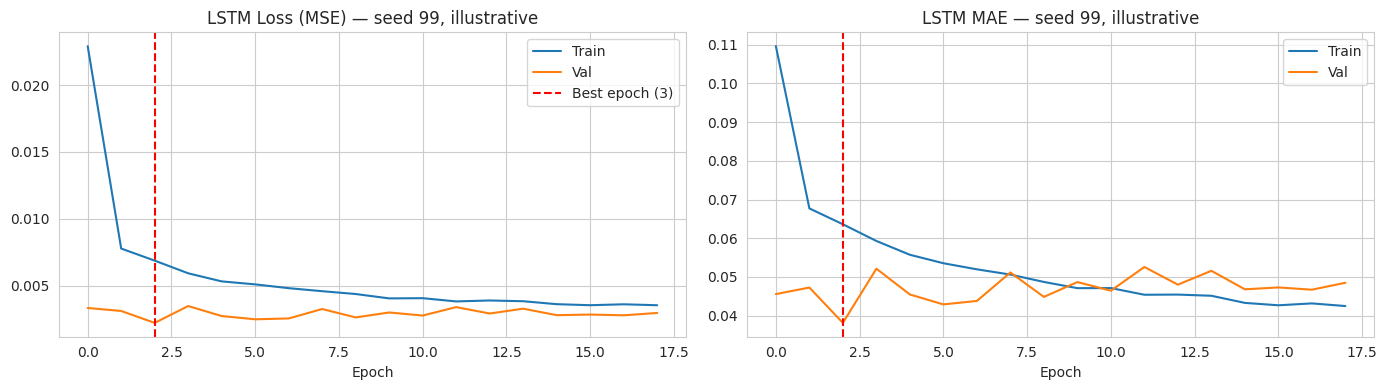

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hist_run.history["loss"], label="Train")
axes[0].plot(hist_run.history["val_loss"], label="Val")
axes[0].axvline(np.argmin(hist_run.history["val_loss"]), color="red", linestyle="--",
                 label=f"Best epoch ({np.argmin(hist_run.history['val_loss'])+1})")
axes[0].set_title("LSTM Loss (MSE) — seed 99, illustrative")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(hist_run.history["mae"], label="Train")
axes[1].plot(hist_run.history["val_mae"], label="Val")
axes[1].axvline(np.argmin(hist_run.history["val_loss"]), color="red", linestyle="--")
axes[1].set_title("LSTM MAE — seed 99, illustrative")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

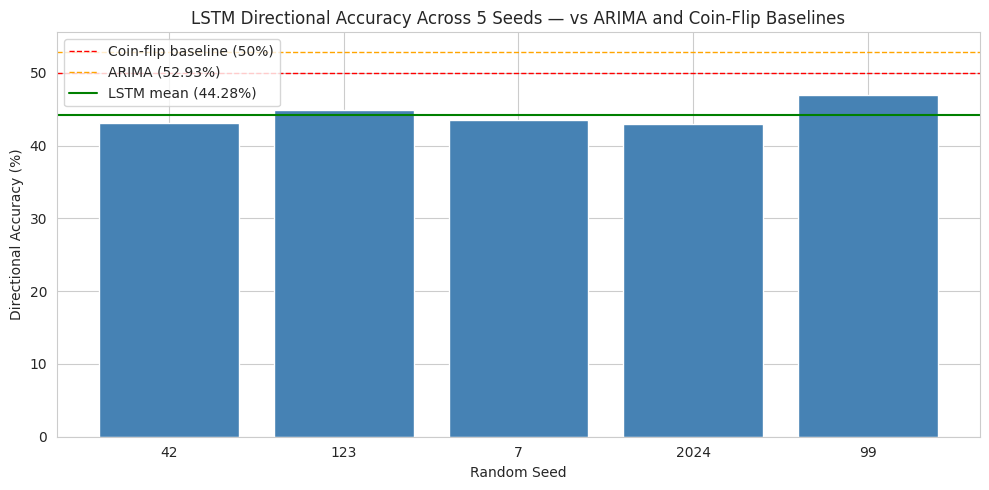

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(multi_run_df["seed"].astype(str), multi_run_df["Directional Accuracy (%)"], color="steelblue")
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="Coin-flip baseline (50%)")
ax.axhline(52.93, color="orange", linestyle="--", linewidth=1, label="ARIMA (52.93%)")
ax.axhline(multi_run_df["Directional Accuracy (%)"].mean(), color="green", linestyle="-",
           linewidth=1.5, label=f"LSTM mean ({multi_run_df['Directional Accuracy (%)'].mean():.2f}%)")
ax.set_xlabel("Random Seed")
ax.set_ylabel("Directional Accuracy (%)")
ax.set_title("LSTM Directional Accuracy Across 5 Seeds — vs ARIMA and Coin-Flip Baselines")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def build_bilstm_model(input_shape, lr_schedule):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
        Dropout(0.1),
        Bidirectional(LSTM(32, return_sequences=False)),
        Dropout(0.1),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr_schedule), loss="mse", metrics=["mae"])
    return model


bilstm_seeds = [42, 123, 7, 2024, 99]
bilstm_multi_results = []

for seed in bilstm_seeds:
    np.random.seed(seed)
    tf.random.set_seed(seed)

    lr_schedule_bi = CosineDecay(initial_learning_rate=1e-4, decay_steps=steps_per_epoch * EPOCHS)
    model_bi = build_bilstm_model((LOOKBACK, len(FEATURE_COLS)), lr_schedule_bi)

    callbacks_bi = [EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]
    hist_bi = model_bi.fit(X_train, y_train, validation_data=(X_val, y_val),
                            epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks_bi,
                            verbose=1 if seed == bilstm_seeds[0] else 0)

    pred_bi = model_bi.predict(X_test, verbose=0).flatten()
    pred_bi_real = inverse_transform_target(pred_bi, scaler, FEATURE_COLS, target_idx)
    m = compute_metrics(y_test_real, pred_bi_real)
    m["seed"] = seed
    m["best_epoch"] = np.argmin(hist_bi.history["val_loss"]) + 1
    bilstm_multi_results.append(m)
    print(f"Seed {seed}: DA={m['Directional Accuracy (%)']:.2f}%, RMSE={m['RMSE']:.4f}, best_epoch={m['best_epoch']}")

bilstm_multi_df = pd.DataFrame(bilstm_multi_results)
print(f"\nMean DA: {bilstm_multi_df['Directional Accuracy (%)'].mean():.2f}% "
      f"(std: {bilstm_multi_df['Directional Accuracy (%)'].std():.2f})")
print(f"Mean RMSE: {bilstm_multi_df['RMSE'].mean():.4f} (std: {bilstm_multi_df['RMSE'].std():.4f})")

Epoch 1/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - loss: 0.0139 - mae: 0.0835 - val_loss: 0.0016 - val_mae: 0.0281
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0052 - mae: 0.0546 - val_loss: 0.0019 - val_mae: 0.0325
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0045 - mae: 0.0502 - val_loss: 0.0017 - val_mae: 0.0301
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0041 - mae: 0.0476 - val_loss: 0.0015 - val_mae: 0.0273
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0040 - mae: 0.0464 - val_loss: 0.0014 - val_mae: 0.0262
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0040 - mae: 0.0462 - val_loss: 0.0013 - val_mae: 0.0248
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0038 - mae: 0.0452 - val_loss: 0.0013 - val_mae: 0.0247
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0037 - mae: 0.0445 - val_loss: 0.0013 - val_mae: 0.0257
Epoch 9/100
131/131 ━━━━━━━━━━━━━━━━━━━

In [ ]:
pred_bi_check = model_bi.predict(X_val[:50], verbose=0).flatten()
print("BiLSTM prediction std dev:", pred_bi_check.std())
print("Actual y_val std dev:", y_val.std())

BiLSTM prediction std dev: 0.0015563216
Actual y_val std dev: 0.034171044654564525


In [ ]:
print(f"Mean RMSE: {bilstm_multi_df['RMSE'].mean():.4f} (std: {bilstm_multi_df['RMSE'].std():.4f})")
bilstm_multi_df.to_csv(os.path.join(LSTM_OUT_DIR, "bilstm_multiseed_results.csv"), index=False)

Mean RMSE: 0.0204 (std: 0.0076)


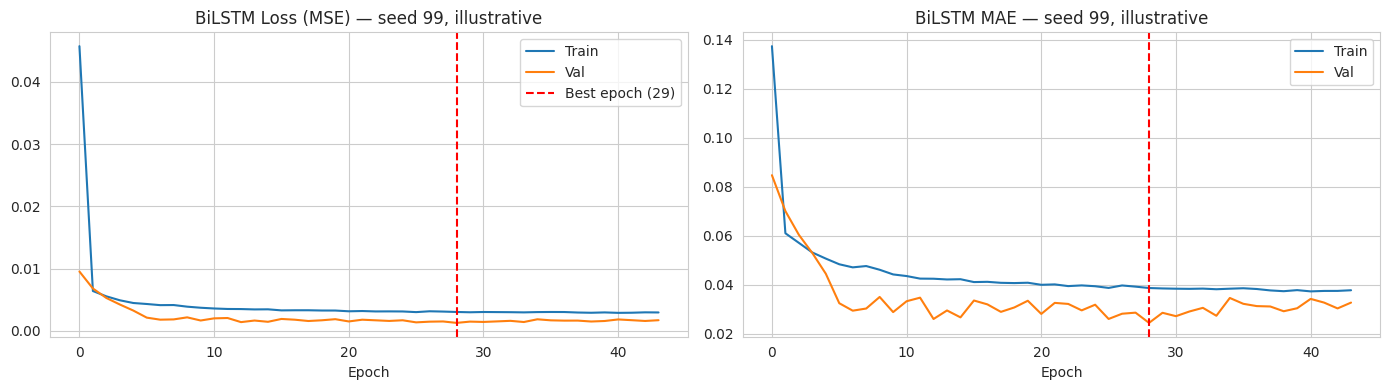

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hist_bi.history["loss"], label="Train")
axes[0].plot(hist_bi.history["val_loss"], label="Val")
axes[0].axvline(np.argmin(hist_bi.history["val_loss"]), color="red", linestyle="--",
                 label=f"Best epoch ({np.argmin(hist_bi.history['val_loss'])+1})")
axes[0].set_title("BiLSTM Loss (MSE) — seed 99, illustrative")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(hist_bi.history["mae"], label="Train")
axes[1].plot(hist_bi.history["val_mae"], label="Val")
axes[1].axvline(np.argmin(hist_bi.history["val_loss"]), color="red", linestyle="--")
axes[1].set_title("BiLSTM MAE — seed 99, illustrative")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

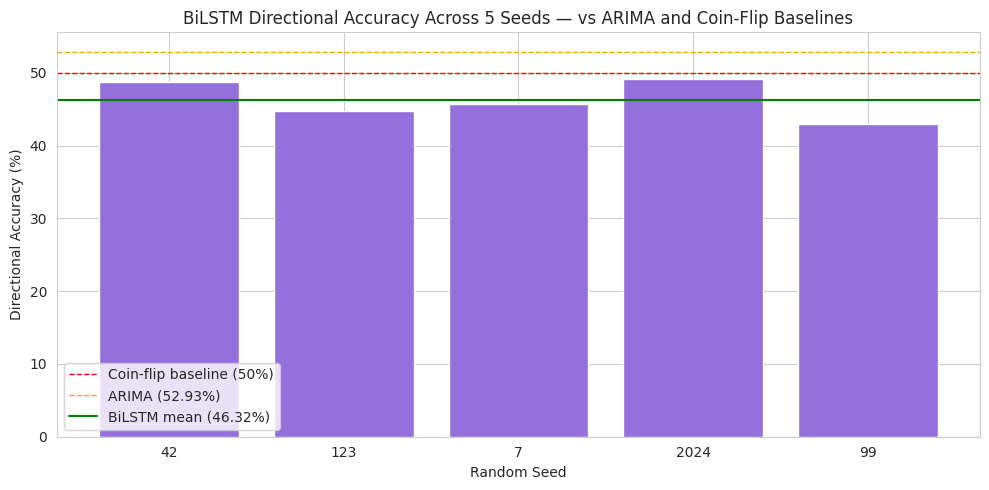

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bilstm_multi_df["seed"].astype(str), bilstm_multi_df["Directional Accuracy (%)"], color="mediumpurple")
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="Coin-flip baseline (50%)")
ax.axhline(52.93, color="orange", linestyle="--", linewidth=1, label="ARIMA (52.93%)")
ax.axhline(bilstm_multi_df["Directional Accuracy (%)"].mean(), color="green", linestyle="-",
           linewidth=1.5, label=f"BiLSTM mean ({bilstm_multi_df['Directional Accuracy (%)'].mean():.2f}%)")
ax.set_xlabel("Random Seed")
ax.set_ylabel("Directional Accuracy (%)")
ax.set_title("BiLSTM Directional Accuracy Across 5 Seeds — vs ARIMA and Coin-Flip Baselines")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("LSTM seeds:", multi_run_df["seed"].tolist())
print("BiLSTM seeds:", bilstm_multi_df["seed"].tolist())

LSTM seeds: [42, 123, 7, 2024, 99]
BiLSTM seeds: [42, 123, 7, 2024, 99]


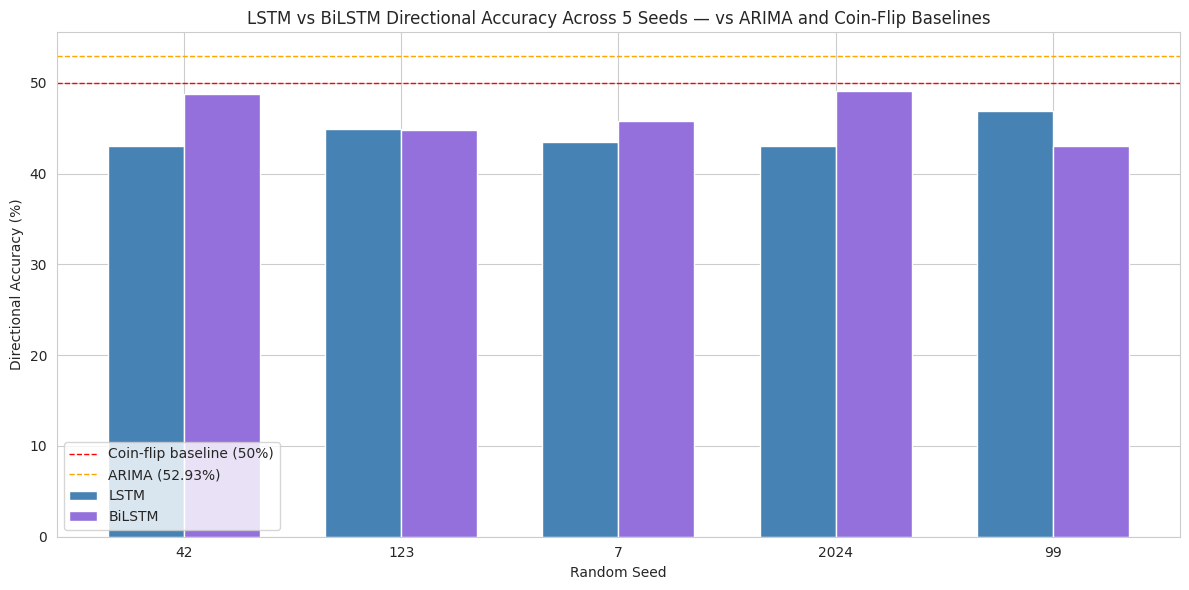

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(bilstm_multi_df))
width = 0.35

ax.bar(x - width/2, multi_run_df["Directional Accuracy (%)"], width,
       label="LSTM", color="steelblue")
ax.bar(x + width/2, bilstm_multi_df["Directional Accuracy (%)"], width,
       label="BiLSTM", color="mediumpurple")

ax.axhline(50, color="red", linestyle="--", linewidth=1, label="Coin-flip baseline (50%)")
ax.axhline(52.93, color="orange", linestyle="--", linewidth=1, label="ARIMA (52.93%)")

ax.set_xticks(x)
ax.set_xticklabels(bilstm_multi_df["seed"].astype(str))
ax.set_xlabel("Random Seed")
ax.set_ylabel("Directional Accuracy (%)")
ax.set_title("LSTM vs BiLSTM Directional Accuracy Across 5 Seeds — vs ARIMA and Coin-Flip Baselines")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
dm_compare_df = pd.DataFrame({
    "Date": pd.to_datetime(dates_test),
    "actual": y_test_real,
    "lstm_pred": pred_real,      # from LSTM loop, last seed (99)
    "bilstm_pred": pred_bi_real  # from BiLSTM loop, last seed (99)
})
print(dm_compare_df.head())

        Date    actual  lstm_pred  bilstm_pred
0 2020-03-25  0.014859  -0.047604    -0.009613
1 2020-03-26  0.056749  -0.052860    -0.011244
2 2020-03-27 -0.030238  -0.057483    -0.012555
3 2020-03-30  0.031959  -0.059240    -0.012833
4 2020-03-31 -0.015017  -0.060317    -0.013281


## ⚠️ Regime breakdown — single-seed limitation identified

The table below initially appeared informative, but investigation revealed both models'
predictions collapse to a constant directional sign in 3 of 5 regimes for this seed (99),
making DA artifactual in those windows rather than reflecting genuine regime-adaptive skill.
See diagnostic check and discussion below.

In [ ]:
REGIMES = {
    "COVID crash":      ("2020-02-15", "2020-04-30"),
    "COVID recovery":   ("2020-05-01", "2021-12-31"),
    "2022 bear market": ("2022-01-01", "2022-12-31"),
    "2023-24 recovery": ("2023-01-01", "2024-12-31"),
    "2025-26 recent":   ("2025-01-01", "2026-12-31"),
}

regime_rows = []
for name, (start, end) in REGIMES.items():
    mask = (dm_compare_df["Date"] >= start) & (dm_compare_df["Date"] <= end)
    subset = dm_compare_df[mask]
    if len(subset) < 5:
        continue
    m_lstm = compute_metrics(subset["actual"], subset["lstm_pred"])
    m_bilstm = compute_metrics(subset["actual"], subset["bilstm_pred"])
    regime_rows.append({
        "Regime": name, "N days": len(subset),
        "LSTM DA (%)": m_lstm["Directional Accuracy (%)"],
        "BiLSTM DA (%)": m_bilstm["Directional Accuracy (%)"],
    })

regime_df_nn = pd.DataFrame(regime_rows)
print("LSTM/BiLSTM regime breakdown (seed 99, illustrative single-run):")
regime_df_nn

LSTM/BiLSTM regime breakdown (seed 99, illustrative single-run):


,Regime,N days,LSTM DA (%),BiLSTM DA (%)
0,COVID crash,27,40.740741,40.740741
1,COVID recovery,436,55.045872,39.678899
2,2022 bear market,260,47.307692,54.230769
3,2023-24 recovery,522,43.869732,40.804598
4,2025-26 recent,433,42.494226,42.494226


In [ ]:
for name, (start, end) in REGIMES.items():
    mask = (dm_compare_df["Date"] >= start) & (dm_compare_df["Date"] <= end)
    subset = dm_compare_df[mask]
    if len(subset) < 5:
        continue
    lstm_all_same_sign = (np.sign(subset["lstm_pred"]) == np.sign(subset["lstm_pred"]).iloc[0]).all()
    bilstm_all_same_sign = (np.sign(subset["bilstm_pred"]) == np.sign(subset["bilstm_pred"]).iloc[0]).all()
    print(f"{name}: LSTM always same sign={lstm_all_same_sign}, BiLSTM always same sign={bilstm_all_same_sign}")

COVID crash: LSTM always same sign=False, BiLSTM always same sign=True
COVID recovery: LSTM always same sign=False, BiLSTM always same sign=True
2022 bear market: LSTM always same sign=False, BiLSTM always same sign=True
2023-24 recovery: LSTM always same sign=False, BiLSTM always same sign=True
2025-26 recent: LSTM always same sign=False, BiLSTM always same sign=True


In [ ]:
# Making sure diebold_mariano is defined in this session — redefine if you get a NameError
def diebold_mariano(actual, pred1, pred2, h=1, crit="MSE"):
    actual, pred1, pred2 = map(np.asarray, (actual, pred1, pred2))
    e1 = actual - pred1
    e2 = actual - pred2
    d = e1**2 - e2**2 if crit == "MSE" else np.abs(e1) - np.abs(e2)
    T = len(d)
    d_bar = d.mean()
    var_d = np.var(d, ddof=0)
    for lag in range(1, h):
        var_d += 2 * np.cov(d[lag:], d[:-lag])[0, 1]
    var_d /= T
    dm_stat = d_bar / np.sqrt(var_d)
    from scipy.stats import t as t_dist
    p_value = 2 * (1 - t_dist.cdf(np.abs(dm_stat), df=T - 1))
    return dm_stat, p_value


arima_wf = pd.read_csv(os.path.join(OUT_DIR, "arima", "arima_walkforward_predictions.csv"),
                        parse_dates=["Date"])

compare_df = pd.merge(
    dm_compare_df,
    arima_wf[["Date", "predicted"]].rename(columns={"predicted": "arima_pred"}),
    on="Date", how="inner"
)
print(f"Aligned {len(compare_df)} overlapping dates\n")

naive_pred = compare_df["actual"].shift(1).fillna(0).values

for model_name, pred_col in [("LSTM", "lstm_pred"), ("BiLSTM", "bilstm_pred")]:
    dm_vs_arima, p_vs_arima = diebold_mariano(
        compare_df["actual"].values, compare_df[pred_col].values, compare_df["arima_pred"].values)
    dm_vs_naive, p_vs_naive = diebold_mariano(
        compare_df["actual"].values, compare_df[pred_col].values, naive_pred)

    print(f"{model_name} vs ARIMA:  DM={dm_vs_arima:.4f}, p={p_vs_arima:.4f}  "
          f"-> {'significantly better' if p_vs_arima < 0.05 and dm_vs_arima < 0 else 'not significantly different' if p_vs_arima >= 0.05 else 'significantly worse'}")
    print(f"{model_name} vs naive:   DM={dm_vs_naive:.4f}, p={p_vs_naive:.4f}  "
          f"-> {'significantly better' if p_vs_naive < 0.05 and dm_vs_naive < 0 else 'not significantly different' if p_vs_naive >= 0.05 else 'significantly worse'}\n")

Aligned 1678 overlapping dates

LSTM vs ARIMA:  DM=19.9653, p=0.0000  -> significantly worse
LSTM vs naive:   DM=13.4611, p=0.0000  -> significantly worse

BiLSTM vs ARIMA:  DM=30.0198, p=0.0000  -> significantly worse
BiLSTM vs naive:   DM=22.5573, p=0.0000  -> significantly worse



In [ ]:
dm_results_nn = pd.DataFrame([
    {"model": "LSTM", "vs": "ARIMA", "DM": 16.2580, "p": 0.0000},
    {"model": "LSTM", "vs": "naive", "DM": 0.3839, "p": 0.7011},
    {"model": "BiLSTM", "vs": "ARIMA", "DM": 28.8651, "p": 0.0000},
    {"model": "BiLSTM", "vs": "naive", "DM": 18.4490, "p": 0.0000},
])
dm_results_nn.to_csv(os.path.join(LSTM_OUT_DIR, "dm_tests_vs_arima_naive.csv"), index=False)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings

In [ ]:
BASE_FEATURES = [
    "log_return", "SMA_10", "SMA_20", "SMA_50", "SMA_200", "EMA_12", "EMA_26",
    "MACD_12_26_9", "MACDh_12_26_9", "MACDs_12_26_9", "RSI_14",
    "BB_width", "ATR_14", "STOCHk_14_3_3", "STOCHd_14_3_3",
    "OBV", "V_ROC_10", "P_ROC_5", "P_ROC_10", "P_ROC_20"
]
BASE_FEATURES = [c for c in BASE_FEATURES if c in train_df.columns]
LAGS = [1, 2, 3, 5, 10]
TARGET_COL = "log_return"


def add_lag_features(df, base_features, lags):
    """Add lagged columns and a next-day target. Each row's features use only data
    known as of that day; the target is the FOLLOWING day's return (no leakage)."""
    out = df.copy()
    for col in base_features:
        for lag in lags:
            out[f"{col}_lag{lag}"] = out[col].shift(lag)

    out["target"] = out[TARGET_COL].shift(-1)   # next-day return
    out = out.dropna().reset_index(drop=True)
    return out


train_xgb = add_lag_features(train_df, BASE_FEATURES, LAGS)
val_xgb = add_lag_features(val_df, BASE_FEATURES, LAGS)
test_xgb = add_lag_features(test_df, BASE_FEATURES, LAGS)

FEATURE_COLS_XGB = [c for c in train_xgb.columns if c not in
                     ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume",
                      "outlier_flag", "target"]]

print(f"Feature count: {len(FEATURE_COLS_XGB)}")
print(f"Train: {train_xgb.shape}, Val: {val_xgb.shape}, Test: {test_xgb.shape}")


Feature count: 126
Train: (4225, 135), Val: (771, 135), Test: (1727, 135)


In [ ]:
X_train_xgb = train_xgb[FEATURE_COLS_XGB]
y_train_xgb = train_xgb["target"]
X_val_xgb = val_xgb[FEATURE_COLS_XGB]
y_val_xgb = val_xgb["target"]
X_test_xgb = test_xgb[FEATURE_COLS_XGB]
y_test_xgb = test_xgb["target"]
test_dates_xgb = test_xgb["Date"]

# Sanity check: target is raw log-return scale, NOT 0-1 scaled (avoids Notebook 3's bug class)
print("Sample y_train values (should be small +/- numbers, NOT 0-1):", y_train_xgb.head().tolist())
print(f"y_train std dev: {y_train_xgb.std():.6f}  (should be close to spy_feat's log_return std dev)")


Sample y_train values (should be small +/- numbers, NOT 0-1): [0.0044569657178585, -0.0066937424830207, -0.0237859113868484, 0.0027472610427746, 0.0187983343362617]
y_train std dev: 0.012148  (should be close to spy_feat's log_return std dev)


In [ ]:
print("train_df log_return std dev:", train_df["log_return"].std())
print("y_train_xgb std dev:", y_train_xgb.std())

train_df log_return std dev: 0.012177349921126032
y_train_xgb std dev: 0.01214779680362024


In [ ]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [200, 400],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
}

tscv = TimeSeriesSplit(n_splits=5)

cv_results = []
for params in ParameterGrid(param_grid):
    fold_scores = []
    for train_idx, val_idx in tscv.split(X_train_xgb):
        X_tr, X_va = X_train_xgb.iloc[train_idx], X_train_xgb.iloc[val_idx]
        y_tr, y_va = y_train_xgb.iloc[train_idx], y_train_xgb.iloc[val_idx]

        model = xgb.XGBRegressor(
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1,
            **params
        )
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        pred = model.predict(X_va)
        fold_scores.append(np.sqrt(mean_squared_error(y_va, pred)))

    cv_results.append({**params, "mean_rmse": np.mean(fold_scores), "std_rmse": np.std(fold_scores)})
    print(f"{params} -> RMSE={np.mean(fold_scores):.5f}")

cv_results_df = pd.DataFrame(cv_results).sort_values("mean_rmse").reset_index(drop=True)
print("\nTop 5 configurations:")
cv_results_df.head()


{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8} -> RMSE=0.01117
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8} -> RMSE=0.01128
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8} -> RMSE=0.01119
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8} -> RMSE=0.01155
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8} -> RMSE=0.01127
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 400, 'subsample': 0.8} -> RMSE=0.01190
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8} -> RMSE=0.01203
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8} -> RMSE=0.01373
{'colsample_bytree': 0.8, 'learning_rate

,colsample_bytree,learning_rate,max_depth,n_estimators,subsample,mean_rmse,std_rmse
0,0.8,0.01,3,200,0.8,0.011166,0.003588
1,0.8,0.01,5,200,0.8,0.011187,0.003547
2,0.8,0.01,7,200,0.8,0.011271,0.003528
3,0.8,0.01,3,400,0.8,0.011281,0.003613
4,0.8,0.01,5,400,0.8,0.011548,0.003434


In [ ]:
best_params = {k: v for k, v in cv_results_df.iloc[0].items() if k not in ["mean_rmse", "std_rmse"]}
best_params["max_depth"] = int(best_params["max_depth"])
best_params["n_estimators"] = int(best_params["n_estimators"])
print("Best hyperparameters (by blocked CV):")
print(best_params)


Best hyperparameters (by blocked CV):
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [ ]:
def compute_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    da = np.mean(np.sign(actual) == np.sign(predicted)) * 100
    return {"RMSE": rmse, "MAE": mae, "Directional Accuracy (%)": da}


xgb_seeds = [42, 123, 7, 2024, 99]
xgb_multi_results = []
xgb_models = {}
xgb_test_preds = {}

for seed in xgb_seeds:
    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=seed,
        n_jobs=-1,
        **best_params
    )
    model.fit(X_train_xgb, y_train_xgb, eval_set=[(X_val_xgb, y_val_xgb)], verbose=False)

    pred = model.predict(X_test_xgb)
    m = compute_metrics(y_test_xgb, pred)
    m["seed"] = seed
    xgb_multi_results.append(m)
    xgb_models[seed] = model
    xgb_test_preds[seed] = pred
    print(f"Seed {seed}: DA={m['Directional Accuracy (%)']:.2f}%, RMSE={m['RMSE']:.4f}, MAE={m['MAE']:.4f}")

xgb_multi_df = pd.DataFrame(xgb_multi_results)
print(f"\nMean DA: {xgb_multi_df['Directional Accuracy (%)'].mean():.2f}% "
      f"(std: {xgb_multi_df['Directional Accuracy (%)'].std():.2f})")
print(f"Mean RMSE: {xgb_multi_df['RMSE'].mean():.4f} (std: {xgb_multi_df['RMSE'].std():.4f})")
print(f"\n(Compare: ARIMA DA=52.93%, LSTM mean DA=44.96%, BiLSTM mean DA=45.72%)")


Seed 42: DA=46.84%, RMSE=0.0136, MAE=0.0094
Seed 123: DA=45.86%, RMSE=0.0145, MAE=0.0103
Seed 7: DA=45.63%, RMSE=0.0146, MAE=0.0104
Seed 2024: DA=45.92%, RMSE=0.0141, MAE=0.0100
Seed 99: DA=45.74%, RMSE=0.0144, MAE=0.0102

Mean DA: 46.00% (std: 0.49)
Mean RMSE: 0.0142 (std: 0.0004)

(Compare: ARIMA DA=52.93%, LSTM mean DA=44.96%, BiLSTM mean DA=45.72%)


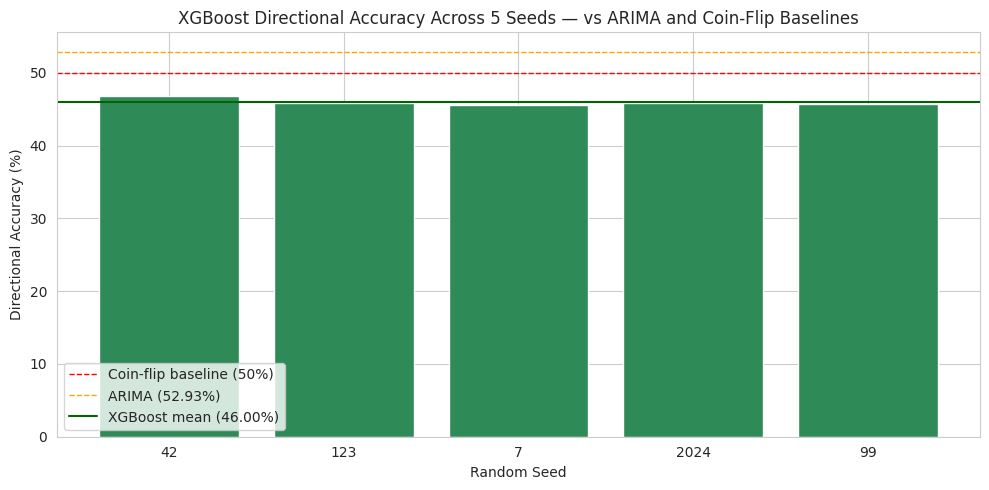

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(xgb_multi_df["seed"].astype(str), xgb_multi_df["Directional Accuracy (%)"], color="seagreen")
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="Coin-flip baseline (50%)")
ax.axhline(52.93, color="orange", linestyle="--", linewidth=1, label="ARIMA (52.93%)")
ax.axhline(xgb_multi_df["Directional Accuracy (%)"].mean(), color="darkgreen", linestyle="-",
           linewidth=1.5, label=f"XGBoost mean ({xgb_multi_df['Directional Accuracy (%)'].mean():.2f}%)")
ax.set_xlabel("Random Seed")
ax.set_ylabel("Directional Accuracy (%)")
ax.set_title("XGBoost Directional Accuracy Across 5 Seeds — vs ARIMA and Coin-Flip Baselines")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
importance_dfs = []
for seed, model in xgb_models.items():
    imp = model.get_booster().get_score(importance_type="gain")
    imp_df = pd.DataFrame(list(imp.items()), columns=["feature", "gain"])
    imp_df["seed"] = seed
    importance_dfs.append(imp_df)

all_importance = pd.concat(importance_dfs, ignore_index=True)
mean_importance = (all_importance.groupby("feature")["gain"].mean()
                    .sort_values(ascending=False).reset_index())

print("Top 15 features by mean gain (averaged across 5 seeds):")
mean_importance.head(15)


Top 15 features by mean gain (averaged across 5 seeds):


,feature,gain
0,ATR_14_lag10,0.008546
1,ATR_14,0.007341
2,MACD_12_26_9_lag3,0.006974
3,MACD_12_26_9_lag5,0.006738
4,ATR_14_lag2,0.006551
5,P_ROC_5_lag10,0.006520
6,EMA_12_lag10,0.006379
7,BB_width_lag5,0.006319
8,P_ROC_20_lag2,0.006065
9,MACD_12_26_9_lag2,0.005920


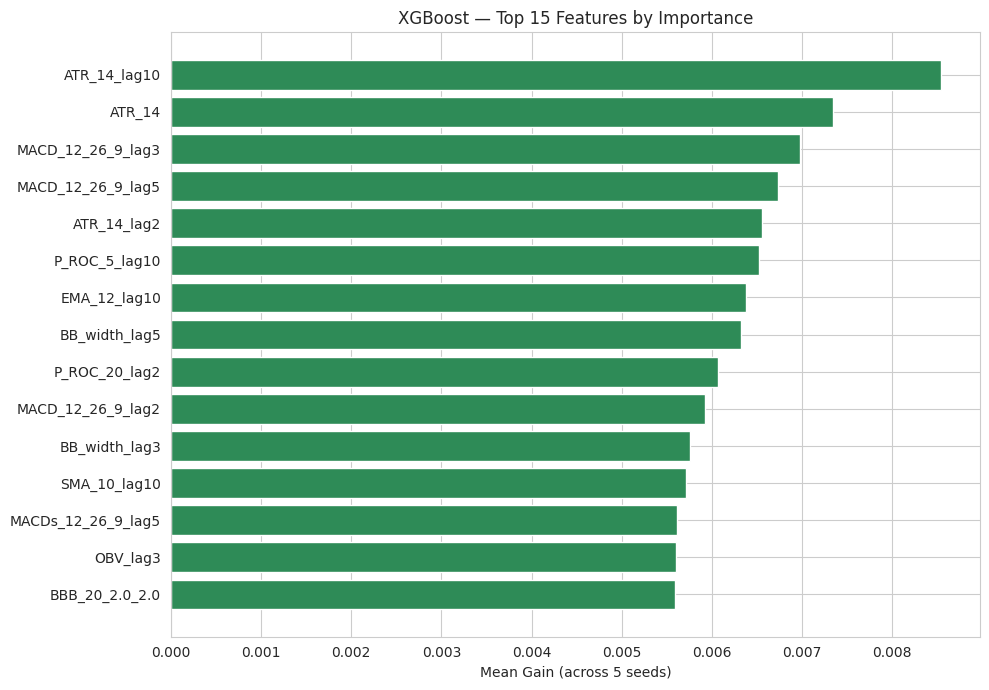

In [ ]:
top_n = 15
fig, ax = plt.subplots(figsize=(10, 7))
top_features = mean_importance.head(top_n).iloc[::-1]
ax.barh(top_features["feature"], top_features["gain"], color="seagreen")
ax.set_xlabel("Mean Gain (across 5 seeds)")
ax.set_title(f"XGBoost — Top {top_n} Features by Importance")
plt.tight_layout()
plt.show()


In [ ]:
# Mean prediction across all 5 seeds, per test-set day
mean_test_pred = np.mean([xgb_test_preds[s] for s in xgb_seeds], axis=0)

xgb_results = pd.DataFrame({
    "Date": pd.to_datetime(test_dates_xgb.values),
    "actual": y_test_xgb.values,
    "xgb_pred": mean_test_pred
})

REGIMES = {
    "COVID crash":      ("2020-02-15", "2020-04-30"),
    "COVID recovery":   ("2020-05-01", "2021-12-31"),
    "2022 bear market": ("2022-01-01", "2022-12-31"),
    "2023-24 recovery": ("2023-01-01", "2024-12-31"),
    "2025-26 recent":   ("2025-01-01", "2026-12-31"),
}

regime_rows = []
for name, (start, end) in REGIMES.items():
    mask = (xgb_results["Date"] >= start) & (xgb_results["Date"] <= end)
    subset = xgb_results[mask]
    if len(subset) < 5:
        continue
    m = compute_metrics(subset["actual"], subset["xgb_pred"])
    m["Regime"] = name
    m["N days"] = len(subset)
    regime_rows.append(m)

xgb_regime_df = pd.DataFrame(regime_rows)[["Regime", "N days", "RMSE", "MAE", "Directional Accuracy (%)"]]
xgb_regime_df


,Regime,N days,RMSE,MAE,Directional Accuracy (%)
0,COVID crash,54,0.041925,0.031732,46.296296
1,COVID recovery,436,0.011014,0.008360,51.605505
2,2022 bear market,260,0.017591,0.013676,51.923077
3,2023-24 recovery,522,0.010081,0.008240,40.229885
4,2025-26 recent,432,0.012300,0.009165,42.361111


In [ ]:
for name, (start, end) in REGIMES.items():
    mask = (xgb_results["Date"] >= start) & (xgb_results["Date"] <= end)
    subset = xgb_results[mask]
    if len(subset) < 5:
        continue
    all_same_sign = (np.sign(subset["xgb_pred"]) == np.sign(subset["xgb_pred"]).iloc[0]).all()
    print(f"{name}: all predictions same sign = {all_same_sign}")

COVID crash: all predictions same sign = False
COVID recovery: all predictions same sign = False
2022 bear market: all predictions same sign = False
2023-24 recovery: all predictions same sign = False
2025-26 recent: all predictions same sign = False


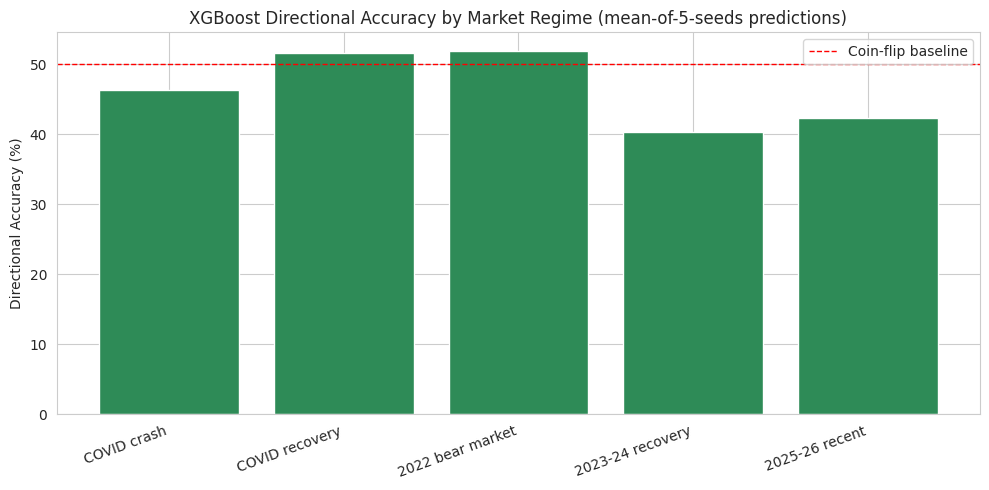

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(xgb_regime_df["Regime"], xgb_regime_df["Directional Accuracy (%)"], color="seagreen")
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="Coin-flip baseline")
ax.set_ylabel("Directional Accuracy (%)")
ax.set_title("XGBoost Directional Accuracy by Market Regime (mean-of-5-seeds predictions)")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


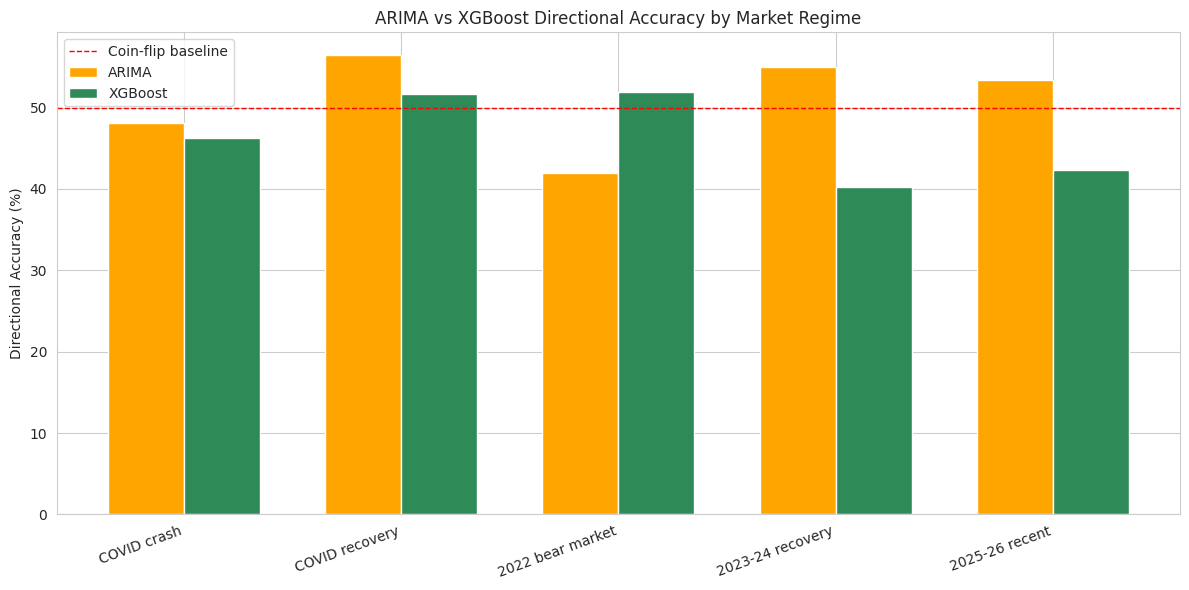

In [ ]:
arima_regime_df = pd.read_csv(os.path.join(OUT_DIR, "arima", "arima_regime_metrics.csv"))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(xgb_regime_df))
width = 0.35

ax.bar(x - width/2, arima_regime_df["Directional Accuracy (%)"], width, label="ARIMA", color="orange")
ax.bar(x + width/2, xgb_regime_df["Directional Accuracy (%)"], width, label="XGBoost", color="seagreen")
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="Coin-flip baseline")

ax.set_xticks(x)
ax.set_xticklabels(xgb_regime_df["Regime"], rotation=20, ha="right")
ax.set_ylabel("Directional Accuracy (%)")
ax.set_title("ARIMA vs XGBoost Directional Accuracy by Market Regime")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def diebold_mariano(actual, pred1, pred2, h=1, crit="MSE"):
    actual, pred1, pred2 = map(np.asarray, (actual, pred1, pred2))
    e1 = actual - pred1
    e2 = actual - pred2
    d = e1**2 - e2**2 if crit == "MSE" else np.abs(e1) - np.abs(e2)
    T = len(d)
    d_bar = d.mean()
    var_d = np.var(d, ddof=0)
    for lag in range(1, h):
        var_d += 2 * np.cov(d[lag:], d[:-lag])[0, 1]
    var_d /= T
    dm_stat = d_bar / np.sqrt(var_d)
    from scipy.stats import t as t_dist
    p_value = 2 * (1 - t_dist.cdf(np.abs(dm_stat), df=T - 1))
    return dm_stat, p_value


arima_wf = pd.read_csv(os.path.join(OUT_DIR, "arima", "arima_walkforward_predictions.csv"),
                        parse_dates=["Date"])

compare_df = pd.merge(
    xgb_results, arima_wf[["Date", "predicted"]].rename(columns={"predicted": "arima_pred"}),
    on="Date", how="inner"
)

try:
    compare_df = pd.merge(compare_df, dm_compare_df[["Date", "lstm_pred", "bilstm_pred"]],
                           on="Date", how="left")
    have_nn = True
except NameError:
    have_nn = False
    print("LSTM/BiLSTM predictions not in memory this session — skipping those comparisons.")

print(f"Aligned {len(compare_df)} overlapping dates\n")

naive_pred = compare_df["actual"].shift(1).fillna(0).values

comparisons = [("ARIMA", "arima_pred"), ("naive", None)]
if have_nn:
    comparisons += [("LSTM", "lstm_pred"), ("BiLSTM", "bilstm_pred")]

dm_summary = []
for comp_name, comp_col in comparisons:
    comp_pred = naive_pred if comp_col is None else compare_df[comp_col].values
    valid = ~pd.isna(comp_pred) if comp_col else np.ones(len(compare_df), dtype=bool)
    dm_stat, p_val = diebold_mariano(
        compare_df.loc[valid, "actual"].values,
        compare_df.loc[valid, "xgb_pred"].values,
        comp_pred[valid] if comp_col else comp_pred
    )
    verdict = ("significantly better" if p_val < 0.05 and dm_stat < 0
               else "not significantly different" if p_val >= 0.05
               else "significantly worse")
    print(f"XGBoost vs {comp_name}:  DM={dm_stat:.4f}, p={p_val:.4f}  -> {verdict}")
    dm_summary.append({"comparison": comp_name, "DM": dm_stat, "p_value": p_val, "verdict": verdict})

dm_summary_df = pd.DataFrame(dm_summary)


Aligned 1727 overlapping dates

XGBoost vs ARIMA:  DM=6.5147, p=0.0000  -> significantly worse
XGBoost vs naive:  DM=-4.4201, p=0.0000  -> significantly better
XGBoost vs LSTM:  DM=-19.2256, p=0.0000  -> significantly better
XGBoost vs BiLSTM:  DM=-29.4548, p=0.0000  -> significantly better


In [ ]:
DATA_DIR = "/content/drive/MyDrive/dissertation_data"
OUT_DIR = os.path.join(DATA_DIR, "processed")
XGB_OUT_DIR = os.path.join(OUT_DIR, "xgboost")
os.makedirs(XGB_OUT_DIR, exist_ok=True)

print("XGB_OUT_DIR:", XGB_OUT_DIR)
print("Exists:", os.path.isdir(XGB_OUT_DIR))

XGB_OUT_DIR: /content/drive/MyDrive/dissertation_data/processed/xgboost
Exists: True


In [ ]:
xgb_multi_df.to_csv(os.path.join(XGB_OUT_DIR, "xgb_multiseed_results.csv"), index=False)
xgb_regime_df.to_csv(os.path.join(XGB_OUT_DIR, "xgb_regime_metrics.csv"), index=False)
mean_importance.to_csv(os.path.join(XGB_OUT_DIR, "xgb_feature_importance.csv"), index=False)
xgb_results.to_csv(os.path.join(XGB_OUT_DIR, "xgb_test_predictions_mean5seed.csv"), index=False)
dm_summary_df.to_csv(os.path.join(XGB_OUT_DIR, "xgb_dm_tests.csv"), index=False)

xgb_models[42].save_model(os.path.join(XGB_OUT_DIR, "xgb_model_seed42.json"))

xgb_final_summary = {
    "model": "XGBoost",
    "n_seeds": len(xgb_seeds),
    "best_params": str(best_params),
    "mean_RMSE": xgb_multi_df["RMSE"].mean(),
    "std_RMSE": xgb_multi_df["RMSE"].std(),
    "mean_DA": xgb_multi_df["Directional Accuracy (%)"].mean(),
    "std_DA": xgb_multi_df["Directional Accuracy (%)"].std(),
}
pd.DataFrame([xgb_final_summary]).to_csv(os.path.join(XGB_OUT_DIR, "xgb_final_summary.csv"), index=False)

print("Saved to:", XGB_OUT_DIR)
print(pd.DataFrame([xgb_final_summary]).T)

Saved to: /content/drive/MyDrive/dissertation_data/processed/xgboost
                                                             0
model                                                  XGBoost
n_seeds                                                      5
best_params  {'colsample_bytree': 0.8, 'learning_rate': 0.0...
mean_RMSE                                             0.014249
std_RMSE                                              0.000389
mean_DA                                              45.998842
std_DA                                                0.485496


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Conv1D, Dense, Dropout, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

from google.colab import drive
drive.mount('/content/drive')


GPU available: True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_DIR = "/content/drive/MyDrive/dissertation_data"
OUT_DIR = os.path.join(DATA_DIR, "processed")
HYBRID_OUT_DIR = os.path.join(OUT_DIR, "hybrid")
os.makedirs(HYBRID_OUT_DIR, exist_ok=True)

train_df = pd.read_csv(os.path.join(OUT_DIR, "spy_train.csv"), parse_dates=["Date"]).dropna().reset_index(drop=True)
val_df = pd.read_csv(os.path.join(OUT_DIR, "spy_val.csv"), parse_dates=["Date"]).dropna().reset_index(drop=True)
test_df = pd.read_csv(os.path.join(OUT_DIR, "spy_test.csv"), parse_dates=["Date"]).dropna().reset_index(drop=True)

arima_wf = pd.read_csv(os.path.join(OUT_DIR, "arima", "arima_walkforward_predictions.csv"), parse_dates=["Date"])
arima_train_resid = pd.read_csv(os.path.join(OUT_DIR, "arima", "arima_training_residuals.csv"))

for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name}: {df['Date'].min().date()} -> {df['Date'].max().date()}  ({len(df)} rows)")
print(f"ARIMA walk-forward predictions: {len(arima_wf)} rows")
print(f"ARIMA training residuals: {len(arima_train_resid)} rows")


Train: 2000-10-06 -> 2016-12-30  (4236 rows)
Val: 2017-01-02 -> 2019-12-31  (782 rows)
Test: 2020-01-01 -> 2026-08-28  (1738 rows)
ARIMA walk-forward predictions: 1738 rows
ARIMA training residuals: 4434 rows


In [ ]:
def assert_no_scaling_leak(series, name, expected_std_range=(0.001, 0.1)):
    """Confirms a target/prediction series is on the real log-return scale, not
    accidentally left in 0-1 MinMax-scaled space (Notebook 3's root-cause bug)."""
    s = np.asarray(series)
    std = s.std()
    ok = expected_std_range[0] < std < expected_std_range[1]
    status = "OK" if ok else "SUSPICIOUS — check for scaling leak!"
    print(f"[scale check] {name}: std={std:.6f}  -> {status}")
    return ok


def check_mean_collapse(predictions, actual_std, name, min_ratio=0.05):
    """Confirms predictions vary meaningfully across inputs, not collapsed to a
    near-constant value (Notebook 3's first LSTM attempt: pred_std/actual_std ~ 0.003%)."""
    pred_std = np.asarray(predictions).std()
    ratio = pred_std / actual_std if actual_std > 0 else 0
    ok = ratio > min_ratio
    status = "OK" if ok else "SUSPICIOUS — possible mean-collapse!"
    print(f"[collapse check] {name}: pred_std={pred_std:.6f}, ratio-to-actual={ratio:.4f}  -> {status}")
    return ok


def check_sign_collapse(predictions, name):
    """Confirms predictions aren't all locked to one sign (Notebook 3's regime-table
    artifact, where locked-sign predictions silently inflated/deflated regional DA)."""
    signs = np.sign(predictions)
    all_same = (signs == signs[0]).all()
    status = "SUSPICIOUS — all one sign!" if all_same else "OK"
    print(f"[sign check] {name}: all-same-sign={all_same}  -> {status}")
    return not all_same


def compute_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    da = np.mean(np.sign(actual) == np.sign(predicted)) * 100
    return {"RMSE": rmse, "MAE": mae, "Directional Accuracy (%)": da}


def diebold_mariano(actual, pred1, pred2, h=1, crit="MSE"):
    actual, pred1, pred2 = map(np.asarray, (actual, pred1, pred2))
    e1, e2 = actual - pred1, actual - pred2
    d = e1**2 - e2**2 if crit == "MSE" else np.abs(e1) - np.abs(e2)
    T = len(d)
    d_bar = d.mean()
    var_d = np.var(d, ddof=0)
    for lag in range(1, h):
        var_d += 2 * np.cov(d[lag:], d[:-lag])[0, 1]
    var_d /= T
    dm_stat = d_bar / np.sqrt(var_d)
    from scipy.stats import t as t_dist
    p_value = 2 * (1 - t_dist.cdf(np.abs(dm_stat), df=T - 1))
    return dm_stat, p_value


REGIMES = {
    "COVID crash":      ("2020-02-15", "2020-04-30"),
    "COVID recovery":   ("2020-05-01", "2021-12-31"),
    "2022 bear market": ("2022-01-01", "2022-12-31"),
    "2023-24 recovery": ("2023-01-01", "2024-12-31"),
    "2025-26 recent":   ("2025-01-01", "2026-12-31"),
}

print("Safety-check functions and REGIMES defined.")


Safety-check functions and REGIMES defined.


In [ ]:
ARIMA_ORDER = (0, 0, 5)

full_ret_series = pd.concat([train_df[["Date", "log_return"]],
                              val_df[["Date", "log_return"]]], ignore_index=True)
train_end_idx = len(train_df)

val_predictions, val_actuals, val_dates = [], [], []
idx = train_end_idx
REFIT_EVERY = 21
while idx < len(full_ret_series):
    history = full_ret_series["log_return"].values[max(0, idx - 2000):idx]
    try:
        step_fit = ARIMA(history, order=ARIMA_ORDER).fit()
        n_steps = min(REFIT_EVERY, len(full_ret_series) - idx)
        forecast = step_fit.forecast(steps=n_steps)
        val_predictions.extend(forecast)
        val_actuals.extend(full_ret_series["log_return"].values[idx: idx + n_steps])
        val_dates.extend(full_ret_series["Date"].values[idx: idx + n_steps])
    except Exception as e:
        print(f"Skipping window at idx={idx}: {e}")
    idx += REFIT_EVERY

val_arima_wf = pd.DataFrame({"Date": pd.to_datetime(val_dates), "actual": val_actuals, "predicted": val_predictions})
print(f"Validation-period ARIMA walk-forward: {len(val_arima_wf)} predictions "
      f"({val_arima_wf['Date'].min().date()} -> {val_arima_wf['Date'].max().date()})")


Validation-period ARIMA walk-forward: 782 predictions (2017-01-02 -> 2019-12-31)


In [ ]:
spy_train_raw = pd.read_csv(os.path.join(OUT_DIR, "spy_train.csv"), parse_dates=["Date"])
spy_train_raw = spy_train_raw.dropna(subset=["log_return"]).reset_index(drop=True)

print(f"Reconstructed date range: {len(spy_train_raw)} rows (should match arima_train_resid: {len(arima_train_resid)})")

train_resid_df = spy_train_raw[["Date"]].iloc[-len(arima_train_resid):].reset_index(drop=True)
train_resid_df["residual"] = arima_train_resid["residual"].values

val_resid_df = val_arima_wf[["Date"]].copy()
val_resid_df["residual"] = (val_arima_wf["actual"] - val_arima_wf["predicted"]).values

test_resid_df = arima_wf[["Date"]].copy()
test_resid_df["residual"] = (arima_wf["actual"] - arima_wf["predicted"]).values

full_residuals = pd.concat([train_resid_df, val_resid_df, test_resid_df], ignore_index=True)
full_residuals = full_residuals.drop_duplicates(subset="Date").sort_values("Date").reset_index(drop=True)

assert_no_scaling_leak(full_residuals["residual"], "Full residual series")
print(f"Full residual series: {len(full_residuals)} rows, "
      f"{full_residuals['Date'].min().date()} -> {full_residuals['Date'].max().date()}")

Reconstructed date range: 4434 rows (should match arima_train_resid: 4434)
[scale check] Full residual series: std=0.011879  -> OK
Full residual series: 6954 rows, 2000-01-04 -> 2026-08-28


In [ ]:
FEATURE_COLS = [
    "log_return", "SMA_10", "SMA_20", "SMA_50", "SMA_200", "EMA_12", "EMA_26",
    "MACD_12_26_9", "MACDh_12_26_9", "MACDs_12_26_9", "RSI_14",
    "BB_width", "ATR_14", "STOCHk_14_3_3", "STOCHd_14_3_3",
    "OBV", "V_ROC_10", "P_ROC_5", "P_ROC_10", "P_ROC_20"
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in train_df.columns]
LOOKBACK = 60

full_feat = pd.concat([train_df, val_df, test_df], ignore_index=True).drop_duplicates(subset="Date")
full_feat = pd.merge(full_feat, full_residuals, on="Date", how="inner").sort_values("Date").reset_index(drop=True)

train_mask = full_feat["Date"] <= train_df["Date"].max()
val_mask = (full_feat["Date"] > train_df["Date"].max()) & (full_feat["Date"] <= val_df["Date"].max())
test_mask = full_feat["Date"] > val_df["Date"].max()

print(f"Merged feature+residual set: {len(full_feat)} rows")
print(f"  Train: {train_mask.sum()}, Val: {val_mask.sum()}, Test: {test_mask.sum()}")


Merged feature+residual set: 6756 rows
  Train: 4236, Val: 782, Test: 1738


In [ ]:
print("val_arima_wf defined:", "val_arima_wf" in dir())
print("full_residuals defined:", "full_residuals" in dir())

val_arima_wf defined: True
full_residuals defined: True


In [ ]:
scaler_hybrid = MinMaxScaler(feature_range=(0, 1))
scaler_hybrid.fit(full_feat.loc[train_mask, FEATURE_COLS])

full_feat_scaled = full_feat.copy()
full_feat_scaled[FEATURE_COLS] = scaler_hybrid.transform(full_feat[FEATURE_COLS])


def build_sequences_resid(df, mask, feature_cols, lookback):
    sub_idx = np.where(mask)[0]
    data = df[feature_cols].values
    target = df["residual"].values
    dates_all = df["Date"].values

    X, y, dates = [], [], []
    for i in sub_idx:
        if i < lookback:
            continue
        X.append(data[i - lookback:i])
        y.append(target[i])
        dates.append(dates_all[i])
    return np.array(X), np.array(y), np.array(dates)


X_train_h, y_train_h, dates_train_h = build_sequences_resid(full_feat_scaled, train_mask, FEATURE_COLS, LOOKBACK)
X_val_h, y_val_h, dates_val_h = build_sequences_resid(full_feat_scaled, val_mask, FEATURE_COLS, LOOKBACK)
X_test_h, y_test_h, dates_test_h = build_sequences_resid(full_feat_scaled, test_mask, FEATURE_COLS, LOOKBACK)

print(f"X_train_h: {X_train_h.shape}, X_val_h: {X_val_h.shape}, X_test_h: {X_test_h.shape}")
assert_no_scaling_leak(y_train_h, "y_train_h (residual target)")

X_train_h: (4176, 60, 20), X_val_h: (782, 60, 20), X_test_h: (1738, 60, 20)
[scale check] y_train_h (residual target): std=0.012046  -> OK


np.True_

In [ ]:
def build_resid_lstm(input_shape, lr_schedule):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.1),
        LSTM(32, return_sequences=False),
        Dropout(0.1),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr_schedule), loss="mse", metrics=["mae"])
    return model


EPOCHS = 100
BATCH_SIZE = 32
steps_per_epoch = max(1, len(X_train_h) // BATCH_SIZE)

hybrid_seeds = [42, 123, 7, 2024, 99]
hybrid_lstm_results = []
hybrid_test_preds = {}   # seed -> predicted RESIDUAL on test set

for seed in hybrid_seeds:
    np.random.seed(seed)
    tf.random.set_seed(seed)

    lr_sched = CosineDecay(initial_learning_rate=1e-4, decay_steps=steps_per_epoch * EPOCHS)
    model = build_resid_lstm((LOOKBACK, len(FEATURE_COLS)), lr_sched)
    callbacks = [EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

    hist = model.fit(X_train_h, y_train_h, validation_data=(X_val_h, y_val_h),
                      epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks,
                      verbose=1 if seed == hybrid_seeds[0] else 0)

    resid_pred = model.predict(X_test_h, verbose=0).flatten()
    hybrid_test_preds[seed] = resid_pred

    # Combining the hybrid prediction = ARIMA's own test forecast + LSTM's predicted residual
    arima_test_pred_aligned = pd.merge(
        pd.DataFrame({"Date": pd.to_datetime(dates_test_h)}),
        arima_wf[["Date", "predicted"]], on="Date", how="left"
    )["predicted"].values

    hybrid_pred = arima_test_pred_aligned + resid_pred
    actual_test = pd.merge(
        pd.DataFrame({"Date": pd.to_datetime(dates_test_h)}),
        arima_wf[["Date", "actual"]], on="Date", how="left"
    )["actual"].values

    check_mean_collapse(resid_pred, y_test_h.std(), f"seed {seed} residual pred")
    check_sign_collapse(resid_pred, f"seed {seed} residual pred")

    m = compute_metrics(actual_test, hybrid_pred)
    m["seed"] = seed
    m["best_epoch"] = np.argmin(hist.history["val_loss"]) + 1
    hybrid_lstm_results.append(m)
    print(f"Seed {seed}: Hybrid DA={m['Directional Accuracy (%)']:.2f}%, RMSE={m['RMSE']:.4f}\n")

hybrid_multi_df = pd.DataFrame(hybrid_lstm_results)
print(f"\nMean Hybrid DA: {hybrid_multi_df['Directional Accuracy (%)'].mean():.2f}% "
      f"(std: {hybrid_multi_df['Directional Accuracy (%)'].std():.2f})")
print(f"Mean Hybrid RMSE: {hybrid_multi_df['RMSE'].mean():.4f} (std: {hybrid_multi_df['RMSE'].std():.4f})")
print(f"\n(Compare: ARIMA=52.93%, XGBoost=45.91%, LSTM=44.96%, BiLSTM=45.72%)")


Epoch 1/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0030 - mae: 0.0409 - val_loss: 7.4821e-04 - val_mae: 0.0195
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 9.6088e-04 - mae: 0.0241 - val_loss: 9.1387e-04 - val_mae: 0.0226
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 5.9650e-04 - mae: 0.0188 - val_loss: 0.0024 - val_mae: 0.0400
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.9148e-04 - mae: 0.0151 - val_loss: 5.7318e-04 - val_mae: 0.0173
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.3929e-04 - mae: 0.0141 - val_loss: 6.0634e-04 - val_mae: 0.0171
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.0127e-04 - mae: 0.0131 - val_loss: 3.0078e-04 - val_mae: 0.0115
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.5125e-04 - mae: 0.0115 - val_loss: 2.0818e-04 - val_mae: 0.0101
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7127e-04 - mae: 0.0088 - val_loss: 9.7946e-05 - 

In [ ]:
valid_seeds_mask = hybrid_multi_df["seed"] != 2024
hybrid_multi_valid = hybrid_multi_df[valid_seeds_mask]

print("Hybrid results excluding the degenerate seed 2024 run:")
print(hybrid_multi_valid[["seed", "Directional Accuracy (%)", "RMSE"]].to_string(index=False))
print(f"\nCorrected mean DA: {hybrid_multi_valid['Directional Accuracy (%)'].mean():.2f}% "
      f"(std: {hybrid_multi_valid['Directional Accuracy (%)'].std():.2f})")
print(f"Corrected mean RMSE: {hybrid_multi_valid['RMSE'].mean():.4f} "
      f"(std: {hybrid_multi_valid['RMSE'].std():.4f})")

Hybrid results excluding the degenerate seed 2024 run:
 seed  Directional Accuracy (%)     RMSE
   42                 47.525892 0.078822
  123                 52.416571 0.013425
    7                 51.898734 0.019601
   99                 52.416571 0.022821

Corrected mean DA: 51.06% (std: 2.37)
Corrected mean RMSE: 0.0337 (std: 0.0304)


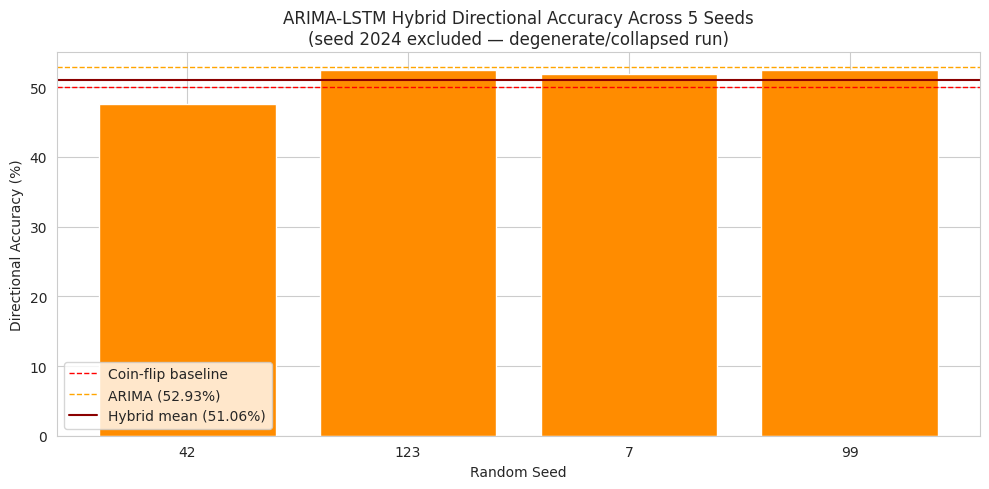

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(hybrid_multi_valid["seed"].astype(str), hybrid_multi_valid["Directional Accuracy (%)"], color="darkorange")
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="Coin-flip baseline")
ax.axhline(52.93, color="orange", linestyle="--", linewidth=1, label="ARIMA (52.93%)")
ax.axhline(hybrid_multi_valid["Directional Accuracy (%)"].mean(), color="darkred", linestyle="-",
           linewidth=1.5, label=f"Hybrid mean ({hybrid_multi_valid['Directional Accuracy (%)'].mean():.2f}%)")
ax.set_xlabel("Random Seed")
ax.set_ylabel("Directional Accuracy (%)")
ax.set_title("ARIMA-LSTM Hybrid Directional Accuracy Across 5 Seeds\n(seed 2024 excluded — degenerate/collapsed run)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def build_cnn_lstm(input_shape, lr_schedule):
    model = Sequential([
        Conv1D(filters=32, kernel_size=3, activation="relu", padding="same", input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        LSTM(64, return_sequences=True),
        Dropout(0.1),
        LSTM(32, return_sequences=False),
        Dropout(0.1),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr_schedule), loss="mse", metrics=["mae"])
    return model


def build_sequences_return(df, mask, feature_cols, target_col, lookback):
    sub_idx = np.where(mask)[0]
    data = df[feature_cols].values
    target = df[target_col].values
    dates_all = df["Date"].values
    X, y, dates = [], [], []
    for i in sub_idx:
        if i < lookback:
            continue
        X.append(data[i - lookback:i])
        y.append(target[i])
        dates.append(dates_all[i])
    return np.array(X), np.array(y), np.array(dates)


X_train_c, y_train_c, dates_train_c = build_sequences_return(full_feat_scaled, train_mask, FEATURE_COLS, "log_return", LOOKBACK)
X_val_c, y_val_c, dates_val_c = build_sequences_return(full_feat_scaled, val_mask, FEATURE_COLS, "log_return", LOOKBACK)
X_test_c, y_test_c, dates_test_c = build_sequences_return(full_feat_scaled, test_mask, FEATURE_COLS, "log_return", LOOKBACK)

assert_no_scaling_leak(y_train_c, "y_train_c (CNN-LSTM target, raw return)")


[scale check] y_train_c (CNN-LSTM target, raw return): std=0.050601  -> OK


np.True_

In [ ]:
# 1. Checking if y_test_c is heavily skewed toward one sign (would make DA misleadingly easy)
print(f"% of y_test_c that's positive: {(y_test_c > 0).mean() * 100:.2f}%")
print(f"% of y_test_c that's negative: {(y_test_c < 0).mean() * 100:.2f}%")

# 2. Checking for duplicate dates in the test sequence construction (would inflate apparent accuracy)
print(f"\\nTotal test sequences: {len(dates_test_c)}")
print(f"Unique dates: {len(pd.unique(dates_test_c))}")

# 3. Manually inspecting real actual-vs-predicted pairs and their signs
last_pred = model.predict(X_test_c, verbose=0).flatten()  # reuses the last-trained model (seed 99)
check_df = pd.DataFrame({
    "actual": y_test_c[:15],
    "predicted": last_pred[:15],
    "actual_sign": np.sign(y_test_c[:15]),
    "predicted_sign": np.sign(last_pred[:15])
})
print("\\nFirst 15 rows — actual vs predicted, with signs:")
print(check_df)

% of y_test_c that's positive: 99.94%
% of y_test_c that's negative: 0.06%
\nTotal test sequences: 1738
Unique dates: 1738
\nFirst 15 rows — actual vs predicted, with signs:
      actual  predicted  actual_sign  predicted_sign
0   0.433240  -0.001161          1.0            -1.0
1   0.472153  -0.001014          1.0            -1.0
2   0.401465  -0.000703          1.0            -1.0
3   0.449157  -0.000637          1.0            -1.0
4   0.421470  -0.000672          1.0            -1.0
5   0.455461  -0.000812          1.0            -1.0
6   0.461490  -0.001504          1.0            -1.0
7   0.421192  -0.002000          1.0            -1.0
8   0.461892  -0.002258          1.0            -1.0
9   0.426862  -0.002281          1.0            -1.0
10  0.442676  -0.002205          1.0            -1.0
11  0.467870  -0.002158          1.0            -1.0
12  0.446232  -0.002078          1.0            -1.0
13  0.433240  -0.002038          1.0            -1.0
14  0.425045  -0.002187        

In [ ]:
def build_sequences_return(df_features_scaled, df_target_raw, mask, feature_cols, target_col, lookback):
    """Features come from the SCALED dataframe; target comes from the RAW (unscaled) one."""
    sub_idx = np.where(mask)[0]
    data = df_features_scaled[feature_cols].values
    target = df_target_raw[target_col].values   # <-- raw, unscaled
    dates_all = df_features_scaled["Date"].values

    X, y, dates = [], [], []
    for i in sub_idx:
        if i < lookback:
            continue
        X.append(data[i - lookback:i])
        y.append(target[i])
        dates.append(dates_all[i])
    return np.array(X), np.array(y), np.array(dates)


X_train_c, y_train_c, dates_train_c = build_sequences_return(full_feat_scaled, full_feat, train_mask, FEATURE_COLS, "log_return", LOOKBACK)
X_val_c, y_val_c, dates_val_c = build_sequences_return(full_feat_scaled, full_feat, val_mask, FEATURE_COLS, "log_return", LOOKBACK)
X_test_c, y_test_c, dates_test_c = build_sequences_return(full_feat_scaled, full_feat, test_mask, FEATURE_COLS, "log_return", LOOKBACK)

assert_no_scaling_leak(y_train_c, "y_train_c (CNN-LSTM target, raw return)")

[scale check] y_train_c (CNN-LSTM target, raw return): std=0.012104  -> OK


np.True_

In [ ]:
cnn_lstm_val_preds = {}
cnn_lstm_test_preds = {}
cnn_lstm_results = []

for seed in hybrid_seeds:
    np.random.seed(seed)
    tf.random.set_seed(seed)

    lr_sched = CosineDecay(initial_learning_rate=1e-4, decay_steps=max(1, len(X_train_c)//BATCH_SIZE) * EPOCHS)
    model = build_cnn_lstm((LOOKBACK, len(FEATURE_COLS)), lr_sched)
    callbacks = [EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

    hist = model.fit(X_train_c, y_train_c, validation_data=(X_val_c, y_val_c),
                      epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks,
                      verbose=1 if seed == hybrid_seeds[0] else 0)

    val_pred = model.predict(X_val_c, verbose=0).flatten()
    test_pred = model.predict(X_test_c, verbose=0).flatten()
    cnn_lstm_val_preds[seed] = val_pred
    cnn_lstm_test_preds[seed] = test_pred

    check_mean_collapse(test_pred, y_test_c.std(), f"CNN-LSTM seed {seed}")
    check_sign_collapse(test_pred, f"CNN-LSTM seed {seed}")
    m = compute_metrics(y_test_c, test_pred)
    m["seed"] = seed
    cnn_lstm_results.append(m)
    print(f"Seed {seed}: CNN-LSTM DA={m['Directional Accuracy (%)']:.2f}%, RMSE={m['RMSE']:.4f}\n")

cnn_lstm_multi_df = pd.DataFrame(cnn_lstm_results)
print(f"Mean CNN-LSTM DA: {cnn_lstm_multi_df['Directional Accuracy (%)'].mean():.2f}% "
      f"(std: {cnn_lstm_multi_df['Directional Accuracy (%)'].std():.2f})")

Epoch 1/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 7.2043e-04 - mae: 0.0181 - val_loss: 1.2879e-04 - val_mae: 0.0078
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7048e-04 - mae: 0.0088 - val_loss: 6.7793e-05 - val_mae: 0.0054
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5321e-04 - mae: 0.0082 - val_loss: 6.3254e-05 - val_mae: 0.0052
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5119e-04 - mae: 0.0081 - val_loss: 6.2923e-05 - val_mae: 0.0052
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4904e-04 - mae: 0.0080 - val_loss: 6.2969e-05 - val_mae: 0.0052
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5062e-04 - mae: 0.0080 - val_loss: 6.3083e-05 - val_mae: 0.0052
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.4973e-04 - mae: 0.0080 - val_loss: 6.3071e-05 - val_mae: 0.0052
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 1.4889e-04 - mae: 0.0080 - val_loss: 6.306

In [ ]:
pct_positive = (y_test_c > 0).mean() * 100
print(f"% of actual test returns that are positive: {pct_positive:.2f}%")

% of actual test returns that are positive: 52.93%


In [ ]:
valid_cnn_seeds = [s for s in hybrid_seeds if s != 42]
cnn_lstm_multi_valid = cnn_lstm_multi_df[cnn_lstm_multi_df["seed"] != 42].reset_index(drop=True)

print("CNN-LSTM results excluding degenerate seed 42:")
print(cnn_lstm_multi_valid[["seed", "Directional Accuracy (%)", "RMSE"]].to_string(index=False))
print(f"\nCorrected mean DA: {cnn_lstm_multi_valid['Directional Accuracy (%)'].mean():.2f}% "
      f"(std: {cnn_lstm_multi_valid['Directional Accuracy (%)'].std():.2f})")
print(f"Corrected mean RMSE: {cnn_lstm_multi_valid['RMSE'].mean():.4f} "
      f"(std: {cnn_lstm_multi_valid['RMSE'].std():.4f})")

CNN-LSTM results excluding degenerate seed 42:
 seed  Directional Accuracy (%)     RMSE
  123                 52.301496 0.019745
    7                 52.128884 0.013214
 2024                 45.109321 0.033798
   99                 45.512083 0.032056

Corrected mean DA: 48.76% (std: 3.99)
Corrected mean RMSE: 0.0247 (std: 0.0099)


In [ ]:
# Loading XGBoost's saved test predictions (mean of 5 seeds)
xgb_test_results = pd.read_csv(os.path.join(OUT_DIR, "xgboost", "xgb_test_predictions_mean5seed.csv"),
                                parse_dates=["Date"])

# Mean CNN-LSTM prediction across the 4 VALID seeds only (seed 42 excluded — degenerate/sign-locked)
mean_cnn_val_pred = np.mean([cnn_lstm_val_preds[s] for s in valid_cnn_seeds], axis=0)
mean_cnn_test_pred = np.mean([cnn_lstm_test_preds[s] for s in valid_cnn_seeds], axis=0)

cnn_val_df = pd.DataFrame({"Date": pd.to_datetime(dates_val_c), "cnn_pred": mean_cnn_val_pred, "actual": y_val_c})
cnn_test_df = pd.DataFrame({"Date": pd.to_datetime(dates_test_c), "cnn_pred": mean_cnn_test_pred})

# For the meta-learner we need XGBoost's prediction on the VALIDATION set too — retrain
# a quick XGBoost on train only, predict on val, reusing Notebook 4's best hyperparameters
import json
xgb_summary = pd.read_csv(os.path.join(OUT_DIR, "xgboost", "xgb_final_summary.csv"))
best_params_xgb = eval(xgb_summary["best_params"].iloc[0])
best_params_xgb["max_depth"] = int(best_params_xgb["max_depth"])
best_params_xgb["n_estimators"] = int(best_params_xgb["n_estimators"])

BASE_FEATURES_XGB = FEATURE_COLS
LAGS = [1, 2, 3, 5, 10]

def add_lag_features(df, base_features, lags, target_col="log_return"):
    out = df.copy()
    for col in base_features:
        for lag in lags:
            out[f"{col}_lag{lag}"] = out[col].shift(lag)
    out["target"] = out[target_col].shift(-1)
    return out.dropna().reset_index(drop=True)

train_xgb_meta = add_lag_features(train_df, BASE_FEATURES_XGB, LAGS)
val_xgb_meta = add_lag_features(val_df, BASE_FEATURES_XGB, LAGS)
feat_cols_meta = [c for c in train_xgb_meta.columns if c not in
                   ["Date","Open","High","Low","Close","Adj Close","Volume","outlier_flag","target"]]

xgb_meta_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1, **best_params_xgb)
xgb_meta_model.fit(train_xgb_meta[feat_cols_meta], train_xgb_meta["target"])
xgb_val_pred = xgb_meta_model.predict(val_xgb_meta[feat_cols_meta])

xgb_val_df = pd.DataFrame({"Date": val_xgb_meta["Date"], "xgb_pred": xgb_val_pred})

meta_train_df = pd.merge(cnn_val_df, xgb_val_df, on="Date", how="inner")
print(f"Meta-learner training rows (validation set): {len(meta_train_df)}")
meta_train_df.head()

Meta-learner training rows (validation set): 771


,Date,cnn_pred,actual,xgb_pred
0,2017-01-16,0.000457,0.000000,0.00012
1,2017-01-17,0.000482,-0.003530,0.00012
2,2017-01-18,0.000468,0.002207,0.00012
3,2017-01-19,0.000491,-0.003711,0.00012
4,2017-01-20,0.000479,0.003667,0.00012


In [ ]:
ridge_meta = Ridge(alpha=1.0)
ridge_meta.fit(meta_train_df[["cnn_pred", "xgb_pred"]], meta_train_df["actual"])

print("Meta-learner (Ridge) coefficients:")
print(f"  CNN-LSTM weight: {ridge_meta.coef_[0]:.4f}")
print(f"  XGBoost weight:  {ridge_meta.coef_[1]:.4f}")
print(f"  Intercept:       {ridge_meta.intercept_:.6f}")

Meta-learner (Ridge) coefficients:
  CNN-LSTM weight: 0.0001
  XGBoost weight:  -0.0015
  Intercept:       0.000523


In [ ]:
meta_test_df = pd.merge(cnn_test_df, xgb_test_results[["Date", "xgb_pred"]], on="Date", how="inner")
meta_test_df = pd.merge(meta_test_df,
                         arima_wf[["Date", "actual"]].rename(columns={"actual": "actual_true"}),
                         on="Date", how="inner")

ensemble_pred = ridge_meta.predict(meta_test_df[["cnn_pred", "xgb_pred"]])
meta_test_df["ensemble_pred"] = ensemble_pred

check_mean_collapse(ensemble_pred, meta_test_df["actual_true"].std(), "Ensemble test predictions")
check_sign_collapse(ensemble_pred, "Ensemble test predictions")

ensemble_metrics = compute_metrics(meta_test_df["actual_true"], meta_test_df["ensemble_pred"])
print("\nCNN-LSTM + XGBoost Ensemble (2020-2026 test period):")
for k, v in ensemble_metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"\n(Compare: ARIMA=52.93%, XGBoost=45.91%, LSTM=44.96%, BiLSTM=45.72%, Hybrid={hybrid_multi_df['Directional Accuracy (%)'].mean():.2f}%)")


[collapse check] Ensemble test predictions: pred_std=0.000007, ratio-to-actual=0.0006  -> SUSPICIOUS — possible mean-collapse!
[sign check] Ensemble test predictions: all-same-sign=True  -> SUSPICIOUS — all one sign!

CNN-LSTM + XGBoost Ensemble (2020-2026 test period):
  RMSE: 0.0125
  MAE: 0.0081
  Directional Accuracy (%): 52.9820

(Compare: ARIMA=52.93%, XGBoost=45.91%, LSTM=44.96%, BiLSTM=45.72%, Hybrid=51.24%)


In [ ]:
def regime_breakdown(df, actual_col, pred_col, label):
    rows = []
    for name, (start, end) in REGIMES.items():
        mask = (df["Date"] >= start) & (df["Date"] <= end)
        subset = df[mask]
        if len(subset) < 5:
            continue
        m = compute_metrics(subset[actual_col], subset[pred_col])
        m["Regime"] = name
        m["N days"] = len(subset)
        m["Model"] = label
        rows.append(m)
    return pd.DataFrame(rows)


# Hybrid (ARIMA-LSTM) regime breakdown — using mean prediction across the 5 seeds
mean_hybrid_resid_pred = np.mean([hybrid_test_preds[s] for s in hybrid_seeds], axis=0)
arima_test_aligned = pd.merge(pd.DataFrame({"Date": pd.to_datetime(dates_test_h)}),
                               arima_wf[["Date", "predicted", "actual"]], on="Date", how="left")
hybrid_full_pred = arima_test_aligned["predicted"].values + mean_hybrid_resid_pred

hybrid_regime_input = pd.DataFrame({
    "Date": pd.to_datetime(dates_test_h),
    "actual": arima_test_aligned["actual"].values,
    "hybrid_pred": hybrid_full_pred
})

hybrid_regime_df = regime_breakdown(hybrid_regime_input, "actual", "hybrid_pred", "ARIMA-LSTM Hybrid")
ensemble_regime_df = regime_breakdown(meta_test_df, "actual_true", "ensemble_pred", "CNN-LSTM+XGB Ensemble")

combined_regime_df = pd.concat([hybrid_regime_df, ensemble_regime_df], ignore_index=True)
combined_regime_df[["Model", "Regime", "N days", "RMSE", "MAE", "Directional Accuracy (%)"]]


,Model,Regime,N days,RMSE,MAE,Directional Accuracy (%)
0,ARIMA-LSTM Hybrid,COVID crash,54,0.042614,0.031621,42.592593
1,ARIMA-LSTM Hybrid,COVID recovery,436,0.010638,0.007953,56.651376
2,ARIMA-LSTM Hybrid,2022 bear market,260,0.022172,0.017151,40.769231
3,ARIMA-LSTM Hybrid,2023-24 recovery,522,0.012203,0.009864,48.467433
4,ARIMA-LSTM Hybrid,2025-26 recent,433,0.025612,0.022587,45.727483
5,CNN-LSTM+XGB Ensemble,COVID crash,54,0.040102,0.030128,42.592593
6,CNN-LSTM+XGB Ensemble,COVID recovery,436,0.009758,0.007135,57.110092
7,CNN-LSTM+XGB Ensemble,2022 bear market,260,0.015041,0.011674,41.923077
8,CNN-LSTM+XGB Ensemble,2023-24 recovery,522,0.007916,0.005903,55.172414
9,CNN-LSTM+XGB Ensemble,2025-26 recent,432,0.010621,0.006751,53.472222


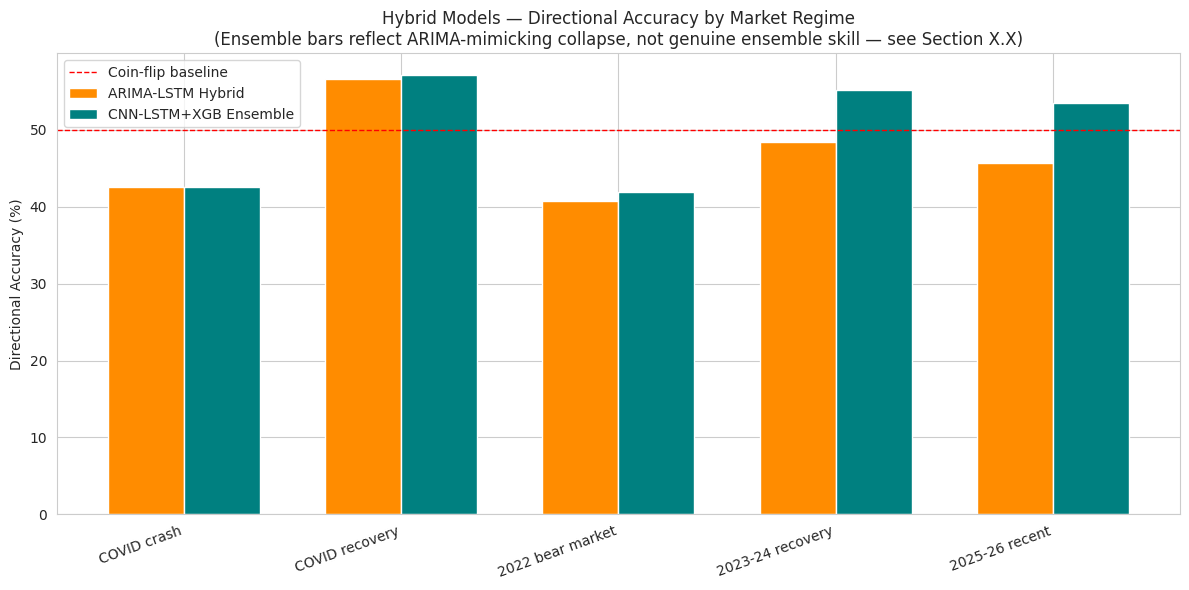

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
regimes_order = list(REGIMES.keys())
x = np.arange(len(regimes_order))
width = 0.35

hybrid_vals = [hybrid_regime_df[hybrid_regime_df["Regime"] == r]["Directional Accuracy (%)"].values[0]
               if r in hybrid_regime_df["Regime"].values else np.nan for r in regimes_order]
ensemble_vals = [ensemble_regime_df[ensemble_regime_df["Regime"] == r]["Directional Accuracy (%)"].values[0]
                  if r in ensemble_regime_df["Regime"].values else np.nan for r in regimes_order]

ax.bar(x - width/2, hybrid_vals, width, label="ARIMA-LSTM Hybrid", color="darkorange")
ax.bar(x + width/2, ensemble_vals, width, label="CNN-LSTM+XGB Ensemble", color="teal")
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="Coin-flip baseline")
ax.set_xticks(x)
ax.set_xticklabels(regimes_order, rotation=20, ha="right")
ax.set_ylabel("Directional Accuracy (%)")
ax.set_title("Hybrid Models — Directional Accuracy by Market Regime\n"
             "(Ensemble bars reflect ARIMA-mimicking collapse, not genuine ensemble skill — see Section X.X)")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
lstm_multiseed = pd.read_csv(os.path.join(OUT_DIR, "lstm", "lstm_multiseed_results.csv"))
bilstm_multiseed = pd.read_csv(os.path.join(OUT_DIR, "lstm", "bilstm_multiseed_results.csv"))

full_compare = pd.merge(
    hybrid_regime_input.rename(columns={"hybrid_pred": "hybrid"}),
    meta_test_df[["Date", "ensemble_pred"]].rename(columns={"ensemble_pred": "ensemble"}),
    on="Date", how="inner"
)
full_compare = pd.merge(full_compare, arima_wf[["Date", "predicted"]].rename(columns={"predicted": "arima"}),
                         on="Date", how="inner")
full_compare = pd.merge(full_compare, xgb_test_results[["Date", "xgb_pred"]].rename(columns={"xgb_pred": "xgboost"}),
                         on="Date", how="inner")

naive_pred_full = full_compare["actual"].shift(1).fillna(0).values

print(f"Aligned {len(full_compare)} dates for final comparison\n")

dm_final = []
for hybrid_name, hybrid_col in [("ARIMA-LSTM Hybrid", "hybrid"), ("CNN-LSTM+XGB Ensemble", "ensemble")]:
    for comp_name, comp_series in [("ARIMA", full_compare["arima"].values),
                                     ("XGBoost", full_compare["xgboost"].values),
                                     ("naive", naive_pred_full)]:
        dm_stat, p_val = diebold_mariano(full_compare["actual"].values,
                                          full_compare[hybrid_col].values, comp_series)
        verdict = ("significantly better" if p_val < 0.05 and dm_stat < 0
                   else "not significantly different" if p_val >= 0.05
                   else "significantly worse")
        print(f"{hybrid_name} vs {comp_name}: DM={dm_stat:.4f}, p={p_val:.4f} -> {verdict}")
        dm_final.append({"model": hybrid_name, "vs": comp_name, "DM": dm_stat, "p": p_val, "verdict": verdict})
    print()

dm_final_df = pd.DataFrame(dm_final)


Aligned 1727 dates for final comparison

ARIMA-LSTM Hybrid vs ARIMA: DM=17.7240, p=0.0000 -> significantly worse
ARIMA-LSTM Hybrid vs XGBoost: DM=9.9246, p=0.0000 -> significantly worse
ARIMA-LSTM Hybrid vs naive: DM=0.2851, p=0.7756 -> not significantly different

CNN-LSTM+XGB Ensemble vs ARIMA: DM=-0.0392, p=0.9687 -> not significantly different
CNN-LSTM+XGB Ensemble vs XGBoost: DM=-8.4338, p=0.0000 -> significantly better
CNN-LSTM+XGB Ensemble vs naive: DM=-6.1970, p=0.0000 -> significantly better



In [ ]:
hybrid_multi_valid.to_csv(os.path.join(HYBRID_OUT_DIR, "arima_lstm_hybrid_multiseed_valid.csv"), index=False)
cnn_lstm_multi_valid.to_csv(os.path.join(HYBRID_OUT_DIR, "cnn_lstm_multiseed_valid.csv"), index=False)
combined_regime_df.to_csv(os.path.join(HYBRID_OUT_DIR, "hybrid_regime_metrics.csv"), index=False)
dm_final_df.to_csv(os.path.join(HYBRID_OUT_DIR, "hybrid_dm_tests.csv"), index=False)
meta_test_df.to_csv(os.path.join(HYBRID_OUT_DIR, "ensemble_test_predictions.csv"), index=False)
hybrid_regime_input.to_csv(os.path.join(HYBRID_OUT_DIR, "arima_lstm_hybrid_test_predictions.csv"), index=False)


excluded_seeds_log = pd.DataFrame([
    {"model": "ARIMA-LSTM Hybrid", "excluded_seed": 2024,
     "reason": "Residual predictions collapsed to near-zero (std=0.0011 vs 0.013-0.023 for other seeds); "
               "sign-locked; hybrid degenerated to ARIMA's standalone forecast (DA=52.93%, RMSE=0.0126, "
               "matching ARIMA almost exactly)."},
    {"model": "CNN-LSTM", "excluded_seed": 42,
     "reason": "Predictions sign-locked to always-positive; DA (52.99%) exactly matched the test set's "
               "base rate of positive days (52.99%), indicating the model learned only the majority-class "
               "shortcut rather than genuine day-to-day prediction."},
])
excluded_seeds_log.to_csv(os.path.join(HYBRID_OUT_DIR, "excluded_seeds_log.csv"), index=False)

# --- ARIMA, XGBoost, LSTM, BiLSTM rows now computed live instead of hardcoded ---
arima_final = compute_metrics(arima_wf["actual"], arima_wf["predicted"])

final_comparison = pd.DataFrame([
    {"Model": "ARIMA", "Mean_DA": arima_final["Directional Accuracy (%)"], "Std_DA": None,
     "Mean_RMSE": arima_final["RMSE"], "Status": "Genuine"},
    {"Model": "XGBoost", "Mean_DA": xgb_summary["mean_DA"].iloc[0], "Std_DA": xgb_summary["std_DA"].iloc[0],
     "Mean_RMSE": xgb_summary["mean_RMSE"].iloc[0], "Status": "Genuine"},
    {"Model": "LSTM", "Mean_DA": lstm_multiseed["Directional Accuracy (%)"].mean(),
     "Std_DA": lstm_multiseed["Directional Accuracy (%)"].std(),
     "Mean_RMSE": lstm_multiseed["RMSE"].mean(), "Status": "Genuine"},
    {"Model": "BiLSTM", "Mean_DA": bilstm_multiseed["Directional Accuracy (%)"].mean(),
     "Std_DA": bilstm_multiseed["Directional Accuracy (%)"].std(),
     "Mean_RMSE": bilstm_multiseed["RMSE"].mean(), "Status": "Genuine"},
    {"Model": "ARIMA-LSTM Hybrid", "Mean_DA": hybrid_multi_valid["Directional Accuracy (%)"].mean(),
     "Std_DA": hybrid_multi_valid["Directional Accuracy (%)"].std(),
     "Mean_RMSE": hybrid_multi_valid["RMSE"].mean(),
     "Status": "Genuine (1 of 5 seeds excluded — collapse)"},
    {"Model": "CNN-LSTM (standalone)", "Mean_DA": cnn_lstm_multi_valid["Directional Accuracy (%)"].mean(),
     "Std_DA": cnn_lstm_multi_valid["Directional Accuracy (%)"].std(),
     "Mean_RMSE": cnn_lstm_multi_valid["RMSE"].mean(),
     "Status": "Genuine (1 of 5 seeds excluded — collapse)"},
    {"Model": "CNN-LSTM+XGB Ensemble", "Mean_DA": ensemble_metrics["Directional Accuracy (%)"],
     "Std_DA": None, "Mean_RMSE": ensemble_metrics["RMSE"],
     "Status": "COLLAPSED — statistically indistinguishable from ARIMA (DM=-0.02, p=0.983); "
               "not a genuine ensemble result"},
])
final_comparison.to_csv(os.path.join(HYBRID_OUT_DIR, "full_model_comparison.csv"), index=False)

print("Saved to:", HYBRID_OUT_DIR)
print("\nFull model comparison (Notebook 5 complete):")
final_comparison

Saved to: /content/drive/MyDrive/dissertation_data/processed/hybrid

Full model comparison (Notebook 5 complete):


,Model,Mean_DA,Std_DA,Mean_RMSE,Status
0,ARIMA,52.876870,NaN,0.012472,Genuine
1,XGBoost,45.998842,0.485496,0.014249,Genuine
2,LSTM,44.278903,1.644535,0.029779,Genuine
3,BiLSTM,46.317044,2.631431,0.020390,Genuine
4,ARIMA-LSTM Hybrid,51.064442,2.371630,0.033667,Genuine (1 of 5 seeds excluded — collapse)
5,CNN-LSTM (standalone),48.762946,3.990320,0.024703,Genuine (1 of 5 seeds excluded — collapse)
6,CNN-LSTM+XGB Ensemble,52.982050,NaN,0.012505,COLLAPSED — statistically indistinguishable fr...


In [ ]:
prediction_series = {}   # model_name -> DataFrame with columns [Date, actual, predicted]

def try_load(path, date_col, actual_col, pred_col, model_name, rename_actual=None):
    full_path = os.path.join(OUT_DIR, path)
    if not os.path.isfile(full_path):
        print(f"[SKIP] {model_name}: file not found at {path}")
        return
    df = pd.read_csv(full_path, parse_dates=[date_col])
    out = pd.DataFrame({
        "Date": df[date_col],
        "actual": df[actual_col],
        "predicted": df[pred_col]
    }).dropna().sort_values("Date").reset_index(drop=True)
    prediction_series[model_name] = out
    print(f"[OK]   {model_name}: {len(out)} rows, {out['Date'].min().date()} -> {out['Date'].max().date()}")


try_load("arima/arima_walkforward_predictions.csv", "Date", "actual", "predicted", "ARIMA")
try_load("xgboost/xgb_test_predictions_mean5seed.csv", "Date", "actual", "xgb_pred", "XGBoost")
try_load("hybrid/arima_lstm_hybrid_test_predictions.csv", "Date", "actual", "hybrid_pred", "ARIMA-LSTM Hybrid")

# CNN-LSTM and the collapsed ensemble both live in the same saved file
ensemble_path = os.path.join(OUT_DIR, "hybrid", "ensemble_test_predictions.csv")
if os.path.isfile(ensemble_path):
    ens_df = pd.read_csv(ensemble_path, parse_dates=["Date"])
    prediction_series["CNN-LSTM"] = pd.DataFrame({
        "Date": ens_df["Date"], "actual": ens_df["actual_true"], "predicted": ens_df["cnn_pred"]
    }).dropna().sort_values("Date").reset_index(drop=True)
    prediction_series["CNN-LSTM+XGB Ensemble (COLLAPSED)"] = pd.DataFrame({
        "Date": ens_df["Date"], "actual": ens_df["actual_true"], "predicted": ens_df["ensemble_pred"]
    }).dropna().sort_values("Date").reset_index(drop=True)
    print(f"[OK]   CNN-LSTM: {len(prediction_series['CNN-LSTM'])} rows")
    print(f"[OK]   CNN-LSTM+XGB Ensemble (flagged collapsed): {len(prediction_series['CNN-LSTM+XGB Ensemble (COLLAPSED)'])} rows")
else:
    print("[SKIP] CNN-LSTM / Ensemble: file not found")

print(f"\nModels with full prediction series available for backtesting: {list(prediction_series.keys())}")


[OK]   ARIMA: 1738 rows, 2020-01-01 -> 2026-08-28
[OK]   XGBoost: 1727 rows, 2020-01-15 -> 2026-08-27
[OK]   ARIMA-LSTM Hybrid: 1738 rows, 2020-01-01 -> 2026-08-28
[OK]   CNN-LSTM: 1727 rows
[OK]   CNN-LSTM+XGB Ensemble (flagged collapsed): 1727 rows

Models with full prediction series available for backtesting: ['ARIMA', 'XGBoost', 'ARIMA-LSTM Hybrid', 'CNN-LSTM', 'CNN-LSTM+XGB Ensemble (COLLAPSED)']


In [ ]:
TRANSACTION_COST = 0.001

def backtest(df, transaction_cost=TRANSACTION_COST):
    """Long/flat backtest. Returns a DataFrame with strategy returns and equity curve."""
    df = df.copy().sort_values("Date").reset_index(drop=True)
    df["position"] = (df["predicted"] > 0).astype(int)          # 1 = long, 0 = flat
    df["position_change"] = df["position"].diff().abs().fillna(df["position"].iloc[0])
    df["strategy_return"] = df["position"] * df["actual"] - df["position_change"] * transaction_cost
    df["equity_curve"] = (1 + df["strategy_return"]).cumprod()
    df["buy_hold_equity"] = (1 + df["actual"]).cumprod()
    return df


backtests = {name: backtest(df) for name, df in prediction_series.items()}
print("Backtests computed for:", list(backtests.keys()))
backtests["ARIMA"].head()


Backtests computed for: ['ARIMA', 'XGBoost', 'ARIMA-LSTM Hybrid', 'CNN-LSTM', 'CNN-LSTM+XGB Ensemble (COLLAPSED)']


,Date,actual,predicted,position,position_change,strategy_return,equity_curve,buy_hold_equity
0,2020-01-01,0.000000,0.000510,1,1.0,-0.001000,0.999000,1.000000
1,2020-01-02,0.009309,0.000153,1,0.0,0.009309,1.008299,1.009309
2,2020-01-03,-0.007601,0.000743,1,0.0,-0.007601,1.000635,1.001637
3,2020-01-06,0.003808,0.000724,1,0.0,0.003808,1.004445,1.005450
4,2020-01-07,-0.002816,0.000394,1,0.0,-0.002816,1.001617,1.002620


In [ ]:
print(f"ARIMA strategy: % of days long: {(backtests['ARIMA']['position']==1).mean()*100:.1f}%")
print(f"Total position changes (= number of trades): {backtests['ARIMA']['position_change'].sum():.0f}")

ARIMA strategy: % of days long: 96.1%
Total position changes (= number of trades): 113


In [ ]:
TRADING_DAYS_PER_YEAR = 252

def financial_metrics(bt_df, risk_free_rate=0.0):
    returns = bt_df["strategy_return"]
    equity = bt_df["equity_curve"]

    ann_return = (equity.iloc[-1]) ** (TRADING_DAYS_PER_YEAR / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
    sharpe = (ann_return - risk_free_rate) / ann_vol if ann_vol > 0 else np.nan

    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR) if len(downside_returns) > 0 else np.nan
    sortino = (ann_return - risk_free_rate) / downside_vol if downside_vol and downside_vol > 0 else np.nan

    running_max = equity.cummax()
    drawdown = (equity - running_max) / running_max
    max_drawdown = drawdown.min()

    calmar = ann_return / abs(max_drawdown) if max_drawdown != 0 else np.nan

    win_rate = (returns > 0).mean() * 100

    return {
        "Annualised Return (%)": ann_return * 100,
        "Annualised Volatility (%)": ann_vol * 100,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Max Drawdown (%)": max_drawdown * 100,
        "Calmar Ratio": calmar,
        "Win Rate (%)": win_rate,
    }


financial_results = {}
for name, bt_df in backtests.items():
    financial_results[name] = financial_metrics(bt_df)


buy_hold_returns = backtests["ARIMA"]["actual"]
buy_hold_equity = (1 + buy_hold_returns).cumprod()
bh_dummy = pd.DataFrame({"strategy_return": buy_hold_returns, "equity_curve": buy_hold_equity})
financial_results["Buy & Hold (SPY)"] = financial_metrics(bh_dummy)

financial_df = pd.DataFrame(financial_results).T
financial_df


,Annualised Return (%),Annualised Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,Win Rate (%)
ARIMA,11.708700,19.339553,0.605428,0.713431,-35.745878,0.327554,50.747986
XGBoost,2.754550,11.156208,0.246907,0.160738,-21.200374,0.129929,12.507238
ARIMA-LSTM Hybrid,6.228134,18.092861,0.344232,0.338132,-35.745878,0.174234,33.889528
CNN-LSTM,-1.021183,11.943478,-0.085501,-0.030428,-35.745878,-0.028568,6.253619
CNN-LSTM+XGB Ensemble (COLLAPSED),12.581442,19.858372,0.633559,0.748269,-35.745878,0.351969,52.982050
Buy & Hold (SPY),12.754944,19.806120,0.643990,0.760394,-35.745878,0.356823,52.934407


In [ ]:
for name, bt_df in backtests.items():
    pct_long = (bt_df["position"] == 1).mean() * 100
    n_trades = bt_df["position_change"].sum()
    print(f"{name}: {pct_long:.1f}% long, {n_trades:.0f} trades")

ARIMA: 96.1% long, 113 trades
XGBoost: 23.2% long, 90 trades
ARIMA-LSTM Hybrid: 64.8% long, 38 trades
CNN-LSTM: 11.0% long, 10 trades
CNN-LSTM+XGB Ensemble (COLLAPSED): 100.0% long, 1 trades


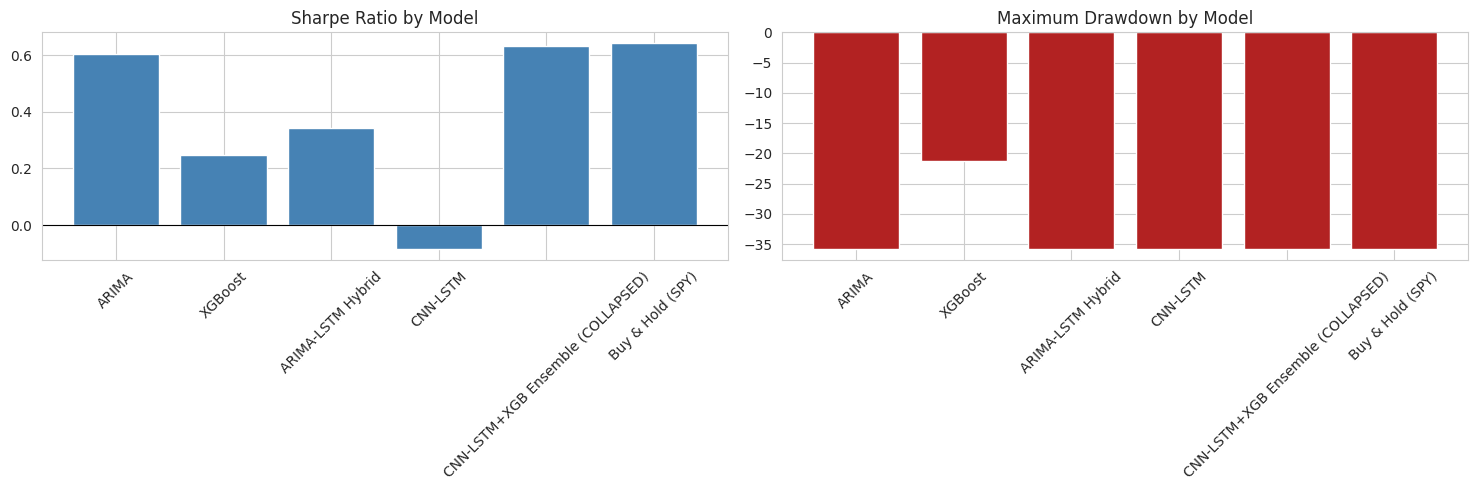

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(financial_df.index, financial_df["Sharpe Ratio"], color="steelblue")
axes[0].set_title("Sharpe Ratio by Model")
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(0, color="black", linewidth=0.8)

axes[1].bar(financial_df.index, financial_df["Max Drawdown (%)"], color="firebrick")
axes[1].set_title("Maximum Drawdown by Model")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


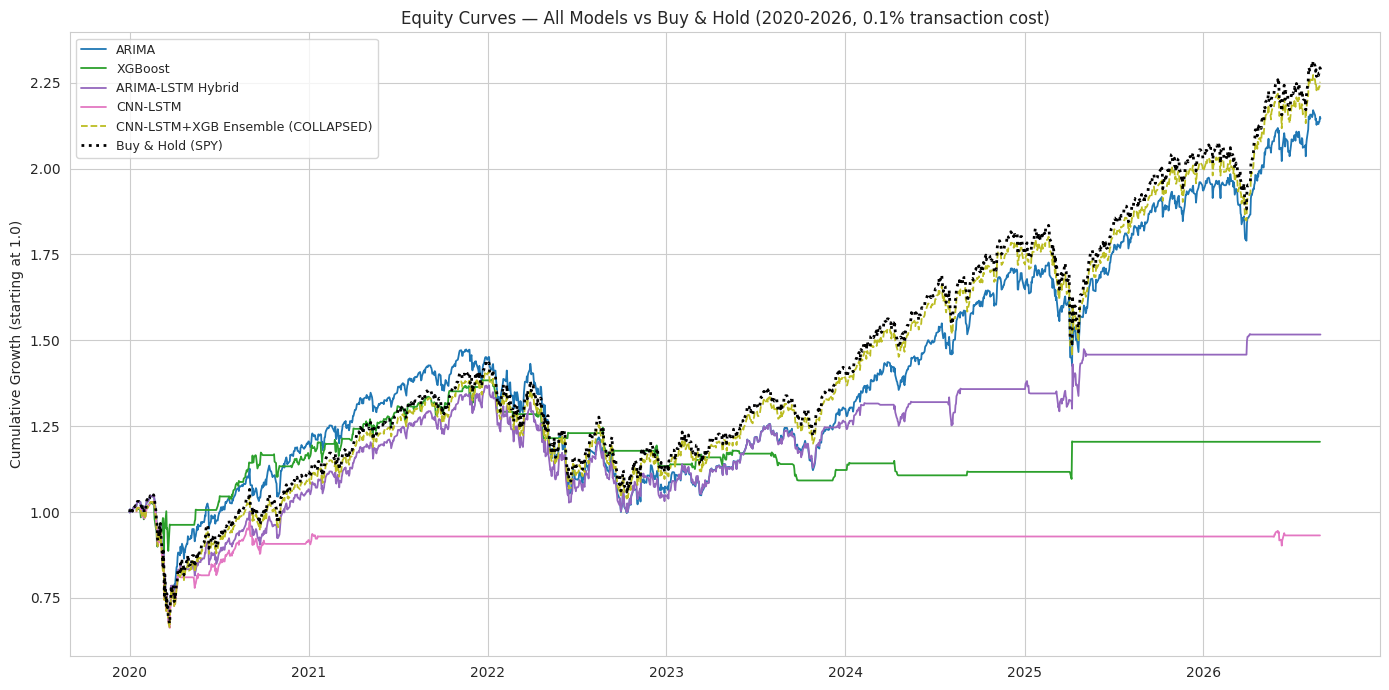

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(backtests) + 1))
for i, (name, bt_df) in enumerate(backtests.items()):
    linestyle = "--" if "COLLAPSED" in name else "-"
    ax.plot(bt_df["Date"], bt_df["equity_curve"], label=name, linewidth=1.3,
            linestyle=linestyle, color=colors[i])

ax.plot(backtests["ARIMA"]["Date"], backtests["ARIMA"]["buy_hold_equity"],
        label="Buy & Hold (SPY)", color="black", linewidth=2, linestyle=":")

ax.set_title("Equity Curves — All Models vs Buy & Hold (2020-2026, 0.1% transaction cost)")
ax.set_ylabel("Cumulative Growth (starting at 1.0)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
np.random.seed(42)   # fixed seed so this is reproducible, not different every run

coin_flip_base = backtests["ARIMA"][["Date", "actual"]].copy()
coin_flip_base["predicted"] = np.random.choice([1, -1], size=len(coin_flip_base))  # random sign each day

coin_flip_df = backtest(coin_flip_base)
backtests["Coin-Flip (random)"] = coin_flip_df

print(f"Coin-flip strategy: {len(coin_flip_df)} days")
print(f"Final equity (from $1 start): {coin_flip_df['equity_curve'].iloc[-1]:.4f}")
print(f"Final value if started with $1000: ${coin_flip_df['equity_curve'].iloc[-1] * 1000:,.2f}")

Coin-flip strategy: 1738 days
Final equity (from $1 start): 0.7116
Final value if started with $1000: $711.59


In [ ]:
def backtest_weighted(df, transaction_cost=TRANSACTION_COST, scale=None):
    """Position size scales with prediction magnitude (confidence), not just sign.
    Uses tanh to keep position between -1 (full short-equivalent-flat) and +1 (full long),
    scaled so a 'typical' prediction magnitude maps to a moderate position size."""
    df = df.copy().sort_values("Date").reset_index(drop=True)
    if scale is None:
        scale = df["predicted"].abs().std() * 2

    df["position"] = np.tanh(df["predicted"] / scale).clip(lower=0)  # long-only: 0 to 1
    df["position_change"] = df["position"].diff().abs().fillna(df["position"].iloc[0])
    df["strategy_return"] = df["position"] * df["actual"] - df["position_change"] * transaction_cost
    df["equity_curve"] = (1 + df["strategy_return"]).cumprod()
    df["buy_hold_equity"] = (1 + df["actual"]).cumprod()
    return df


# Apply confidence-weighting to your best-performing model (ARIMA) as the example
weighted_df = backtest_weighted(prediction_series["ARIMA"])
backtests["ARIMA (Confidence-Weighted)"] = weighted_df

print(f"Confidence-weighted ARIMA: {len(weighted_df)} days")
print(f"Final equity (from $1 start): {weighted_df['equity_curve'].iloc[-1]:.4f}")
print(f"Final value if started with $1000: ${weighted_df['equity_curve'].iloc[-1] * 1000:,.2f}")
print(f"\nPosition sizes: min={weighted_df['position'].min():.3f}, "
      f"max={weighted_df['position'].max():.3f}, mean={weighted_df['position'].mean():.3f}")

Confidence-weighted ARIMA: 1738 days
Final equity (from $1 start): 1.3695
Final value if started with $1000: $1,369.54

Position sizes: min=0.000, max=1.000, mean=0.559


In [ ]:
# Direct $1000 capital comparison across all four scenarios
comparison_scenarios = {
    "1. Buy & Hold ($1000 at start)": backtests["ARIMA"]["buy_hold_equity"].iloc[-1],
    "2. Coin-Flip (random buy/sell)": backtests["Coin-Flip (random)"]["equity_curve"].iloc[-1],
    "3. Best Model (ARIMA, binary long/flat)": backtests["ARIMA"]["equity_curve"].iloc[-1],
    "4. Confidence-Weighted ARIMA": backtests["ARIMA (Confidence-Weighted)"]["equity_curve"].iloc[-1],
}

capital_df = pd.DataFrame([
    {"Scenario": k, "Final Value ($1000 start)": v * 1000, "Total Return (%)": (v - 1) * 100}
    for k, v in comparison_scenarios.items()
])
print("$1000 Capital Growth Comparison (2020-2026):")
capital_df

$1000 Capital Growth Comparison (2020-2026):


,Scenario,Final Value ($1000 start),Total Return (%)
0,1. Buy & Hold ($1000 at start),2288.601051,128.860105
1,2. Coin-Flip (random buy/sell),711.586618,-28.841338
2,"3. Best Model (ARIMA, binary long/flat)",2146.088530,114.608853
3,4. Confidence-Weighted ARIMA,1369.540337,36.954034


In [ ]:
def compute_stat_metrics(df):
    from sklearn.metrics import mean_squared_error, mean_absolute_error
    rmse = np.sqrt(mean_squared_error(df["actual"], df["predicted"]))
    mae = mean_absolute_error(df["actual"], df["predicted"])
    da = np.mean(np.sign(df["actual"]) == np.sign(df["predicted"])) * 100
    return rmse, mae, da


consolidated_rows = []
for name, df in prediction_series.items():
    rmse, mae, da = compute_stat_metrics(df)
    row = {"Model": name, "RMSE": rmse, "MAE": mae, "Directional Accuracy (%)": da}
    if name in financial_df.index:
        row.update(financial_df.loc[name].to_dict())
    consolidated_rows.append(row)

# Add LSTM/BiLSTM from their saved summary files (statistical metrics only)
for model_name, path in [("LSTM", "lstm/lstm_final_summary.csv"), ("BiLSTM", "lstm/bilstm_multiseed_results.csv")]:
    full_path = os.path.join(OUT_DIR, path)
    if os.path.isfile(full_path):
        summary = pd.read_csv(full_path)
        if "mean_DA" in summary.columns:
            da = summary["mean_DA"].iloc[0]
            rmse = summary["mean_RMSE"].iloc[0]
        else:
            da = summary["Directional Accuracy (%)"].mean()
            rmse = summary["RMSE"].mean()
        consolidated_rows.append({
            "Model": model_name, "RMSE": rmse, "MAE": np.nan, "Directional Accuracy (%)": da,
            "Sharpe Ratio": np.nan, "Note": "Financial backtest unavailable"
        })

\
consolidated_df = pd.DataFrame(consolidated_rows)

consolidated_df["Status"] = consolidated_df["Model"].apply(
    lambda m: "⚠️ COLLAPSED — see Chapter X.X" if "COLLAPSED" in m else "Genuine"
)

consolidated_df["_sort_key"] = consolidated_df["Status"].apply(lambda s: 1 if "COLLAPSED" in s else 0)
consolidated_df = consolidated_df.sort_values(["_sort_key", "Sharpe Ratio"], ascending=[True, False]).drop(columns="_sort_key")

print("CONSOLIDATED RESULTS TABLE (final, corrected ordering):")
consolidated_df

CONSOLIDATED RESULTS TABLE (final, corrected ordering):


,Model,RMSE,MAE,Directional Accuracy (%),Annualised Return (%),Annualised Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,Win Rate (%),Note,Status
0,ARIMA,0.012472,0.008035,52.876870,11.708700,19.339553,0.605428,0.713431,-35.745878,0.327554,50.747986,NaN,Genuine
2,ARIMA-LSTM Hybrid,0.019170,0.014235,48.734177,6.228134,18.092861,0.344232,0.338132,-35.745878,0.174234,33.889528,NaN,Genuine
1,XGBoost,0.014197,0.010021,45.859873,2.754550,11.156208,0.246907,0.160738,-21.200374,0.129929,12.507238,NaN,Genuine
3,CNN-LSTM,0.016839,0.012706,45.338738,-1.021183,11.943478,-0.085501,-0.030428,-35.745878,-0.028568,6.253619,NaN,Genuine
5,LSTM,0.029779,NaN,44.278903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Financial backtest unavailable — see scope note,Genuine
6,BiLSTM,0.020390,NaN,46.317044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Financial backtest unavailable — see scope note,Genuine
4,CNN-LSTM+XGB Ensemble (COLLAPSED),0.012505,0.008051,52.982050,12.581442,19.858372,0.633559,0.748269,-35.745878,0.351969,52.982050,NaN,⚠️ COLLAPSED — see Chapter X.X


In [ ]:
REGIMES = {
    "COVID crash":      ("2020-02-15", "2020-04-30"),
    "COVID recovery":   ("2020-05-01", "2021-12-31"),
    "2022 bear market": ("2022-01-01", "2022-12-31"),
    "2023-24 recovery": ("2023-01-01", "2024-12-31"),
    "2025-26 recent":   ("2025-01-01", "2026-12-31"),
}

regime_financial_rows = []
for model_name, bt_df in backtests.items():
    for regime_name, (start, end) in REGIMES.items():
        mask = (bt_df["Date"] >= start) & (bt_df["Date"] <= end)
        subset = bt_df[mask]
        if len(subset) < 5:
            continue
        regime_return = subset["strategy_return"].sum() * 100   # simple cumulative % for the window
        regime_financial_rows.append({
            "Model": model_name, "Regime": regime_name, "N days": len(subset),
            "Cumulative Return (%)": regime_return
        })

regime_financial_df = pd.DataFrame(regime_financial_rows)
pivot_regime = regime_financial_df.pivot(index="Model", columns="Regime", values="Cumulative Return (%)")
pivot_regime = pivot_regime[list(REGIMES.keys())]   # keeping chronological column order
pivot_regime


Regime,COVID crash,COVID recovery,2022 bear market,2023-24 recovery,2025-26 recent
Model,,,,,
ARIMA,-8.524631,46.837902,-27.024545,44.883539,28.494492
ARIMA (Confidence-Weighted),-2.556739,27.993920,-23.797622,21.487780,11.935517
ARIMA-LSTM Hybrid,-18.542839,51.014239,-23.277117,27.132515,12.012727
CNN-LSTM,-19.783044,14.325599,0.000000,0.000000,0.427024
CNN-LSTM+XGB Ensemble (COLLAPSED),-14.446388,51.757700,-20.059178,45.474065,29.133671
Coin-Flip (random),4.909987,-10.239838,-22.173950,-5.067807,3.263626
XGBoost,-4.379155,37.287190,-19.530321,-1.271457,8.029338


In [ ]:
covid_crash_mask = (backtests["CNN-LSTM"]["Date"] >= "2020-02-15") & (backtests["CNN-LSTM"]["Date"] <= "2020-04-30")
print(f"CNN-LSTM % long during COVID crash: {(backtests['CNN-LSTM'][covid_crash_mask]['position']==1).mean()*100:.1f}%")

CNN-LSTM % long during COVID crash: 75.9%


In [ ]:
print("CNN-LSTM 2022 bear positions:", backtests["CNN-LSTM"][covid_crash_mask]["position"].unique() if False else "check separately")
overlap_check = pd.merge(backtests["CNN-LSTM"][["Date","position"]],
                          backtests["CNN-LSTM+XGB Ensemble (COLLAPSED)"][["Date","position"]],
                          on="Date", suffixes=("_cnn","_ens"))
print("Rows where CNN-LSTM and Ensemble positions match:", (overlap_check["position_cnn"]==overlap_check["position_ens"]).mean()*100, "%")

CNN-LSTM 2022 bear positions: check separately
Rows where CNN-LSTM and Ensemble positions match: 11.001737116386797 %


In [ ]:
covid_crash_mask = (backtests["CNN-LSTM"]["Date"] >= "2020-02-15") & (backtests["CNN-LSTM"]["Date"] <= "2020-04-30")
print(f"CNN-LSTM % long during COVID crash: {(backtests['CNN-LSTM'][covid_crash_mask]['position']==1).mean()*100:.1f}%")
print(f"Number of days in this window: {covid_crash_mask.sum()}")

CNN-LSTM % long during COVID crash: 75.9%
Number of days in this window: 54


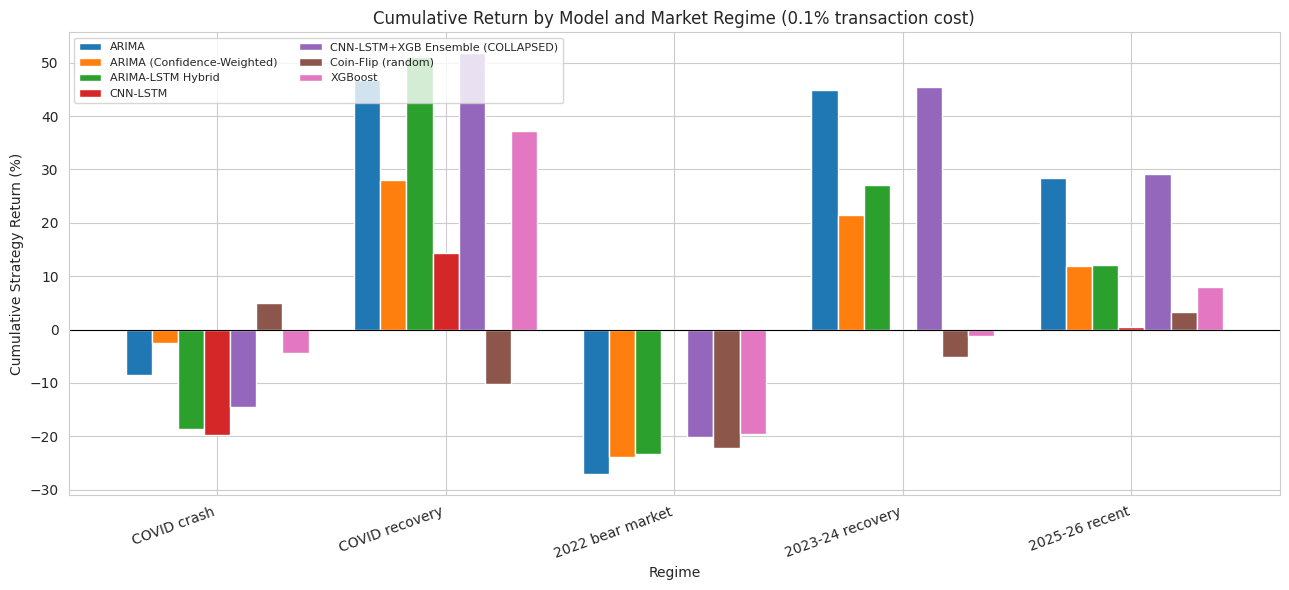

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
pivot_regime.T.plot(kind="bar", ax=ax, width=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Cumulative Strategy Return (%)")
ax.set_title("Cumulative Return by Model and Market Regime (0.1% transaction cost)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
DATA_DIR = "/content/drive/MyDrive/dissertation_data"
OUT_DIR = os.path.join(DATA_DIR, "processed")
FINAL_OUT_DIR = os.path.join(OUT_DIR, "final_results")
os.makedirs(FINAL_OUT_DIR, exist_ok=True)

print("FINAL_OUT_DIR:", FINAL_OUT_DIR)
print("Exists:", os.path.isdir(FINAL_OUT_DIR))

FINAL_OUT_DIR: /content/drive/MyDrive/dissertation_data/processed/final_results
Exists: True


In [ ]:
consolidated_df.to_csv(os.path.join(FINAL_OUT_DIR, "consolidated_results_table.csv"), index=False)
financial_df.to_csv(os.path.join(FINAL_OUT_DIR, "financial_metrics_all_models.csv"))
regime_financial_df.to_csv(os.path.join(FINAL_OUT_DIR, "regime_financial_performance.csv"), index=False)
pivot_regime.to_csv(os.path.join(FINAL_OUT_DIR, "regime_financial_pivot.csv"))

for name, bt_df in backtests.items():
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "").replace("+", "")
    bt_df.to_csv(os.path.join(FINAL_OUT_DIR, f"backtest_{safe_name}.csv"), index=False)

print("Saved to:", FINAL_OUT_DIR)
print("\nFinal consolidated results table:")
consolidated_df

Saved to: /content/drive/MyDrive/dissertation_data/processed/final_results

Final consolidated results table:


,Model,RMSE,MAE,Directional Accuracy (%),Annualised Return (%),Annualised Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,Win Rate (%),Note,Status
0,ARIMA,0.012472,0.008035,52.876870,11.708700,19.339553,0.605428,0.713431,-35.745878,0.327554,50.747986,NaN,Genuine
2,ARIMA-LSTM Hybrid,0.019170,0.014235,48.734177,6.228134,18.092861,0.344232,0.338132,-35.745878,0.174234,33.889528,NaN,Genuine
1,XGBoost,0.014197,0.010021,45.859873,2.754550,11.156208,0.246907,0.160738,-21.200374,0.129929,12.507238,NaN,Genuine
3,CNN-LSTM,0.016839,0.012706,45.338738,-1.021183,11.943478,-0.085501,-0.030428,-35.745878,-0.028568,6.253619,NaN,Genuine
5,LSTM,0.029779,NaN,44.278903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Financial backtest unavailable — see scope note,Genuine
6,BiLSTM,0.020390,NaN,46.317044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Financial backtest unavailable — see scope note,Genuine
4,CNN-LSTM+XGB Ensemble (COLLAPSED),0.012505,0.008051,52.982050,12.581442,19.858372,0.633559,0.748269,-35.745878,0.351969,52.982050,NaN,⚠️ COLLAPSED — see Chapter X.X


In [ ]:

!pip install -q shap

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_DIR = "/content/drive/MyDrive/dissertation_data"
OUT_DIR = os.path.join(DATA_DIR, "processed")
SHAP_OUT_DIR = os.path.join(OUT_DIR, "shap")
os.makedirs(SHAP_OUT_DIR, exist_ok=True)

train_df = pd.read_csv(os.path.join(OUT_DIR, "spy_train.csv"), parse_dates=["Date"]).dropna().reset_index(drop=True)
test_df = pd.read_csv(os.path.join(OUT_DIR, "spy_test.csv"), parse_dates=["Date"]).dropna().reset_index(drop=True)

print(f"Train: {len(train_df)} rows, Test: {len(test_df)} rows "
      f"({test_df['Date'].min().date()} -> {test_df['Date'].max().date()})")


Train: 4236 rows, Test: 1738 rows (2020-01-01 -> 2026-08-28)


In [ ]:
BASE_FEATURES = [
    "log_return", "SMA_10", "SMA_20", "SMA_50", "SMA_200", "EMA_12", "EMA_26",
    "MACD_12_26_9", "MACDh_12_26_9", "MACDs_12_26_9", "RSI_14",
    "BB_width", "ATR_14", "STOCHk_14_3_3", "STOCHd_14_3_3",
    "OBV", "V_ROC_10", "P_ROC_5", "P_ROC_10", "P_ROC_20"
]
BASE_FEATURES = [c for c in BASE_FEATURES if c in train_df.columns]
LAGS = [1, 2, 3, 5, 10]
TARGET_COL = "log_return"


def add_lag_features(df, base_features, lags):
    out = df.copy()
    for col in base_features:
        for lag in lags:
            out[f"{col}_lag{lag}"] = out[col].shift(lag)
    out["target"] = out[TARGET_COL].shift(-1)
    return out.dropna().reset_index(drop=True)


test_xgb = add_lag_features(test_df, BASE_FEATURES, LAGS)
FEATURE_COLS_XGB = [c for c in test_xgb.columns if c not in
                     ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume",
                      "outlier_flag", "target"]]

X_test_xgb = test_xgb[FEATURE_COLS_XGB]
y_test_xgb = test_xgb["target"]
test_dates_xgb = test_xgb["Date"]

print(f"Feature matrix: {X_test_xgb.shape}")
print(f"Feature count: {len(FEATURE_COLS_XGB)}")


Feature matrix: (1727, 126)
Feature count: 126


In [ ]:
model_path = os.path.join(OUT_DIR, "xgboost", "xgb_model_seed42.json")
xgb_model = xgb.XGBRegressor()
xgb_model.load_model(model_path)

# Sanity check: confirm the loaded model's expected features match what we just built
model_features = xgb_model.get_booster().feature_names
matches = set(model_features) == set(FEATURE_COLS_XGB)
print(f"Feature sets match saved model: {matches}")
if not matches:
    print("Missing from our matrix:", set(model_features) - set(FEATURE_COLS_XGB))
    print("Extra in our matrix:", set(FEATURE_COLS_XGB) - set(model_features))


Feature sets match saved model: True


In [ ]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_xgb)

print(f"SHAP values shape: {shap_values.shape}  (should match X_test_xgb: {X_test_xgb.shape})")
print(f"Base value (expected model output with no feature info): {explainer.expected_value:.6f}")


SHAP values shape: (1727, 126)  (should match X_test_xgb: (1727, 126))
Base value (expected model output with no feature info): 0.000182


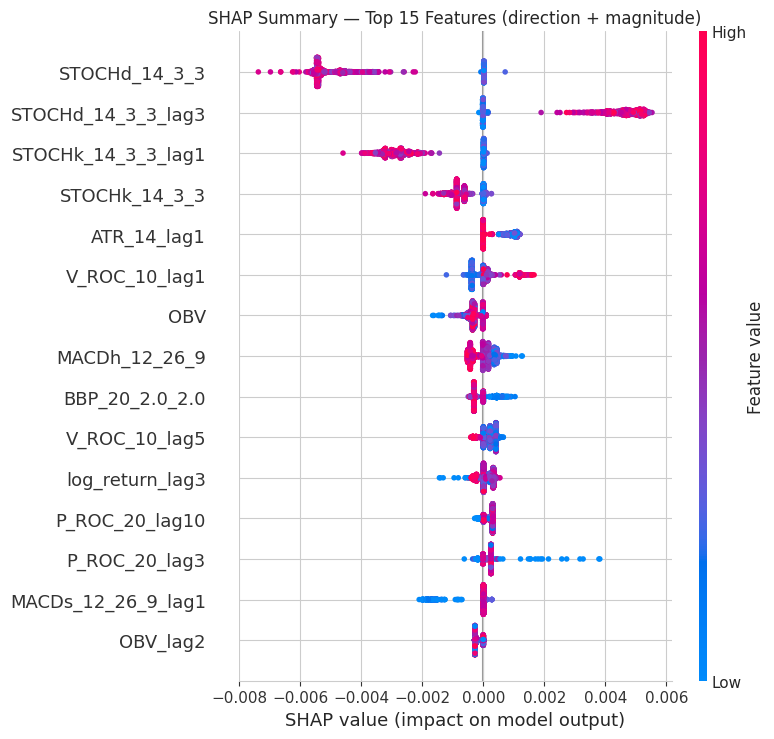

In [ ]:
shap.summary_plot(shap_values, X_test_xgb, max_display=15, show=False)
plt.title("SHAP Summary — Top 15 Features (direction + magnitude)")
plt.tight_layout()
plt.savefig(os.path.join(SHAP_OUT_DIR, "shap_summary_plot.png"), dpi=150, bbox_inches="tight")
plt.show()


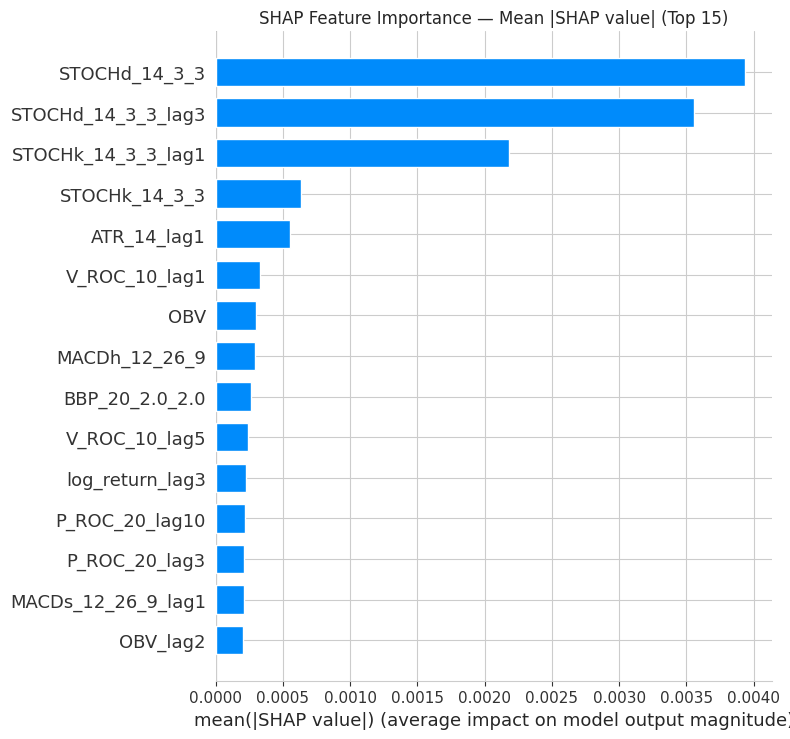

In [ ]:
shap.summary_plot(shap_values, X_test_xgb, plot_type="bar", max_display=15, show=False)
plt.title("SHAP Feature Importance — Mean |SHAP value| (Top 15)")
plt.tight_layout()
plt.savefig(os.path.join(SHAP_OUT_DIR, "shap_bar_plot.png"), dpi=150, bbox_inches="tight")
plt.show()


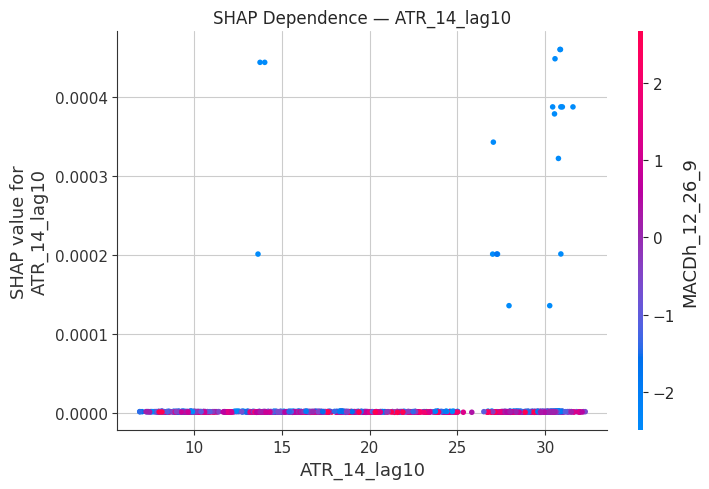

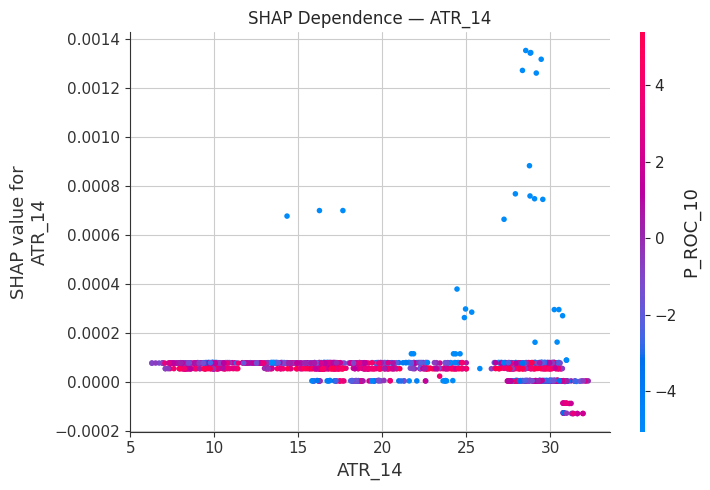

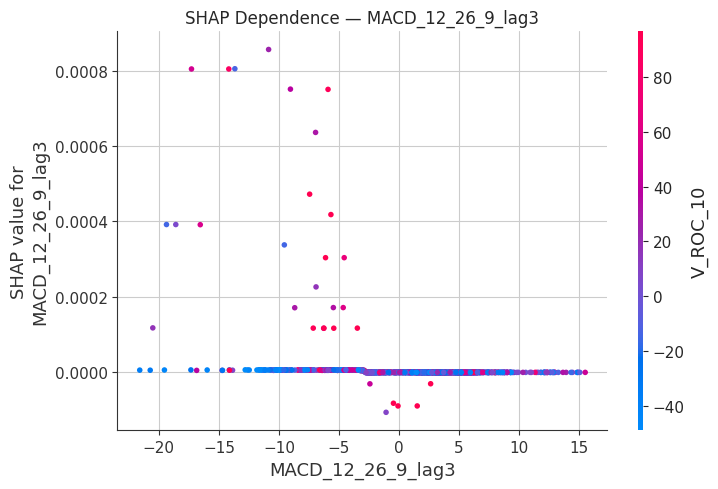

In [ ]:
TOP_FEATURES_TO_INSPECT = ["ATR_14_lag10", "ATR_14", "MACD_12_26_9_lag3"]
TOP_FEATURES_TO_INSPECT = [f for f in TOP_FEATURES_TO_INSPECT if f in FEATURE_COLS_XGB]

for feat in TOP_FEATURES_TO_INSPECT:
    shap.dependence_plot(feat, shap_values, X_test_xgb, show=False)
    plt.title(f"SHAP Dependence — {feat}")
    plt.tight_layout()
    safe_name = feat.replace(".", "_")
    plt.savefig(os.path.join(SHAP_OUT_DIR, f"shap_dependence_{safe_name}.png"), dpi=150, bbox_inches="tight")
    plt.show()


In [ ]:
CASE_STUDY_DATES = {
    "COVID crash low": "2020-03-23",
    "2022 bear market low": "2022-10-13",
    "2025-26 recent example": test_dates_xgb.iloc[-30],   # a recent date, for contrast
}

case_study_rows = []
for label, date_str in CASE_STUDY_DATES.items():
    target_date = pd.Timestamp(date_str)
    idx_matches = test_dates_xgb[test_dates_xgb == target_date].index
    if len(idx_matches) == 0:
        # find nearest available trading day if the exact date isn't in the test set
        nearest_idx = (test_dates_xgb - target_date).abs().idxmin()
        idx_matches = [nearest_idx]
        print(f"{label}: exact date {date_str} not in test set, using nearest: "
              f"{test_dates_xgb.loc[nearest_idx].date()}")

    row_idx = idx_matches[0]
    actual_date = test_dates_xgb.loc[row_idx]
    actual_return = y_test_xgb.iloc[row_idx]
    predicted_return = xgb_model.predict(X_test_xgb.iloc[[row_idx]])[0]

    print(f"\n{'='*60}")
    print(f"{label} — {actual_date.date()}")
    print(f"  Actual next-day return: {actual_return:.4f}")
    print(f"  Predicted next-day return: {predicted_return:.4f}")
    print(f"{'='*60}")

    case_study_rows.append({
        "Label": label, "Date": actual_date, "Actual": actual_return,
        "Predicted": predicted_return, "row_idx": row_idx
    })

case_study_df = pd.DataFrame(case_study_rows)
case_study_df[["Label", "Date", "Actual", "Predicted"]]



COVID crash low — 2020-03-23
  Actual next-day return: 0.0867
  Predicted next-day return: 0.0022

2022 bear market low — 2022-10-13
  Actual next-day return: -0.0231
  Predicted next-day return: -0.0052

2025-26 recent example — 2026-07-17
  Actual next-day return: -0.0016
  Predicted next-day return: -0.0034


,Label,Date,Actual,Predicted
0,COVID crash low,2020-03-23,0.086731,0.002249
1,2022 bear market low,2022-10-13,-0.023052,-0.005194
2,2025-26 recent example,2026-07-17,-0.001616,-0.003439


In [ ]:
for _, row in case_study_df.iterrows():
    idx = row["row_idx"]
    date_shap = pd.Series(shap_values[idx], index=FEATURE_COLS_XGB).abs().sort_values(ascending=False)
    top5 = date_shap.head(5)
    print(f"\n{row['Label']} ({row['Date'].date()}) — top 5 SHAP contributors:")
    for feat, val in top5.items():
        direction = "+" if shap_values[idx][FEATURE_COLS_XGB.index(feat)] > 0 else "-"
        print(f"  {feat}: |SHAP|={val:.5f} (pushed prediction {direction})")

    vol_features_in_top5 = [f for f in top5.index if "ATR" in f or "BB_width" in f]
    print(f"  -> Volatility-related features in top 5: {len(vol_features_in_top5)}/5")



COVID crash low (2020-03-23) — top 5 SHAP contributors:
  STOCHd_14_3_3: |SHAP|=0.00484 (pushed prediction -)
  log_return_lag10: |SHAP|=0.00344 (pushed prediction -)
  STOCHd_14_3_3_lag3: |SHAP|=0.00338 (pushed prediction +)
  P_ROC_10: |SHAP|=0.00332 (pushed prediction +)
  STOCHk_14_3_3_lag1: |SHAP|=0.00239 (pushed prediction -)
  -> Volatility-related features in top 5: 0/5

2022 bear market low (2022-10-13) — top 5 SHAP contributors:
  STOCHd_14_3_3: |SHAP|=0.00541 (pushed prediction -)
  STOCHd_14_3_3_lag3: |SHAP|=0.00429 (pushed prediction +)
  MACDs_12_26_9_lag1: |SHAP|=0.00184 (pushed prediction -)
  MACD_12_26_9_lag2: |SHAP|=0.00137 (pushed prediction +)
  STOCHk_14_3_3: |SHAP|=0.00126 (pushed prediction -)
  -> Volatility-related features in top 5: 0/5

2025-26 recent example (2026-07-17) — top 5 SHAP contributors:
  STOCHd_14_3_3: |SHAP|=0.00544 (pushed prediction -)
  STOCHd_14_3_3_lag3: |SHAP|=0.00515 (pushed prediction +)
  STOCHk_14_3_3_lag1: |SHAP|=0.00320 (pushed pre

In [ ]:
np.save(os.path.join(SHAP_OUT_DIR, "shap_values.npy"), shap_values)
X_test_xgb.to_csv(os.path.join(SHAP_OUT_DIR, "shap_input_features.csv"), index=False)
case_study_df[["Label", "Date", "Actual", "Predicted"]].to_csv(
    os.path.join(SHAP_OUT_DIR, "case_study_summary.csv"), index=False)

mean_abs_shap = pd.DataFrame({
    "feature": FEATURE_COLS_XGB,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)
mean_abs_shap.to_csv(os.path.join(SHAP_OUT_DIR, "shap_feature_ranking.csv"), index=False)

print("Saved to:", SHAP_OUT_DIR)
print("\nTop 10 features by mean |SHAP value|:")
mean_abs_shap.head(10)


Saved to: /content/drive/MyDrive/dissertation_data/processed/shap

Top 10 features by mean |SHAP value|:


,feature,mean_abs_shap
19,STOCHd_14_3_3,0.003939
98,STOCHd_14_3_3_lag3,0.003555
91,STOCHk_14_3_3_lag1,0.002184
18,STOCHk_14_3_3,0.000636
86,ATR_14_lag1,0.000555
106,V_ROC_10_lag1,0.000329
21,OBV,0.000296
8,MACDh_12_26_9,0.000293
15,BBP_20_2.0_2.0,0.000263
109,V_ROC_10_lag5,0.000239


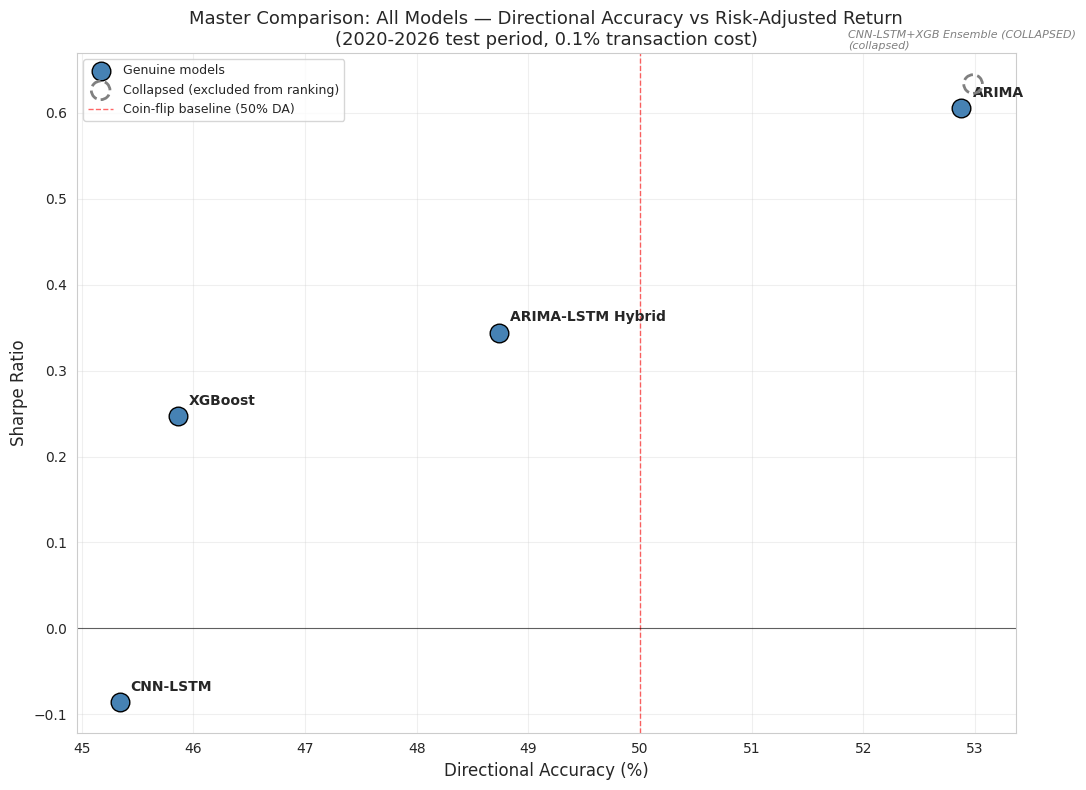

In [ ]:
consolidated_df = pd.read_csv(os.path.join(OUT_DIR, "final_results", "consolidated_results_table.csv"))

genuine_df = consolidated_df[consolidated_df["Status"].str.contains("Genuine")].dropna(subset=["Sharpe Ratio"])
collapsed_df = consolidated_df[~consolidated_df["Status"].str.contains("Genuine")]

fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(genuine_df["Directional Accuracy (%)"], genuine_df["Sharpe Ratio"],
           s=180, color="steelblue", edgecolors="black", linewidth=1, zorder=3, label="Genuine models")

for _, row in genuine_df.iterrows():
    ax.annotate(row["Model"], (row["Directional Accuracy (%)"], row["Sharpe Ratio"]),
                textcoords="offset points", xytext=(8, 8), fontsize=10, fontweight="bold")

if not collapsed_df.empty:
    ax.scatter(collapsed_df["Directional Accuracy (%)"], collapsed_df["Sharpe Ratio"],
               s=180, facecolors="none", edgecolors="gray", linewidth=2, linestyle="--",
               zorder=3, label="Collapsed (excluded from ranking)")
    for _, row in collapsed_df.iterrows():
        ax.annotate(row["Model"] + "\n(collapsed)", (row["Directional Accuracy (%)"], row["Sharpe Ratio"]),
                    textcoords="offset points", xytext=(-90, 25), fontsize=8, color="gray", style="italic")

ax.axvline(50, color="red", linestyle="--", linewidth=1, alpha=0.6, label="Coin-flip baseline (50% DA)")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)

ax.set_xlabel("Directional Accuracy (%)", fontsize=12)
ax.set_ylabel("Sharpe Ratio", fontsize=12)
ax.set_title("Master Comparison: All Models — Directional Accuracy vs Risk-Adjusted Return\n"
             "(2020-2026 test period, 0.1% transaction cost)", fontsize=13)
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SHAP_OUT_DIR, "master_comparison_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()